In [ ]:
# ============================================================
# RADIAL MIXING MODEL
# V^2 = A*U + B*w(r)*Vbar^2
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

def run(r0):
    rmses=[]

    for f in FILES:
        d=load(f)
        if d is None: continue
        r,v,vg,vd,vb=d

        vb2=vbar2(vg,vd,vb)
        rho=vb2/np.sqrt(r**2+R_CORE**2)

        rg,U=solve(r,rho)
        Uobs=np.interp(r,rg,U)

        w = r**2/(r**2 + r0**2)

        X = np.vstack([Uobs, w*vb2]).T
        y = v**2

        m=np.isfinite(X).all(axis=1)&np.isfinite(y)
        if np.sum(m)<5: continue

        coef,_,_,_=np.linalg.lstsq(X[m],y[m],rcond=None)

        v_model=np.sqrt(np.maximum(X@coef,0))
        rmse=np.sqrt(np.mean((v_model-v)**2))
        rmses.append(rmse)

    return np.median(rmses)

scales=[0.1,0.5,1,2,5]

results=[]
for s in scales:
    print("Testing r0 =", s)
    results.append((s,run(s)))

print("\n=== RESULTS ===")
for r in sorted(results,key=lambda x:x[1]):
    print(r)

Testing r0 = 0.1
Testing r0 = 0.5
Testing r0 = 1
Testing r0 = 2
Testing r0 = 5

=== RESULTS ===
(0.1, np.float64(nan))
(0.5, np.float64(nan))
(1, np.float64(nan))
(2, np.float64(nan))
(5, np.float64(nan))


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL MIXING FIX THE BAD TAIL?
# Requires ONLY ROTMOD .dat files in /content
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# constants (fixed)
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5
R0 = 0.1

# -----------------------------
# discover data automatically
# -----------------------------
ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

if len(FILES) == 0:
    raise RuntimeError("No ROTMOD .dat files found in /content")

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]

    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return dict(name=p.stem, r=r, v=v, vg=vg, vd=vd, vb=vb)

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2.0)**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr

    return rg, U

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b)**2)))

# -----------------------------
# run comparison
# -----------------------------
rows = []

for f in FILES:
    d = load_file(f)
    if d is None:
        continue

    r = d["r"]
    v = d["v"]
    vb2 = vbar2(d["vg"], d["vd"], d["vb"])

    rho = vb2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    # global two-component
    Xg = np.vstack([Uobs, vb2]).T
    yg = v**2

    mg = np.isfinite(Xg).all(axis=1) & np.isfinite(yg)
    if np.sum(mg) < 5:
        continue

    coef_g, _, _, _ = np.linalg.lstsq(Xg[mg], yg[mg], rcond=None)
    v_model_g = np.sqrt(np.maximum(Xg @ coef_g, 0.0))
    rmse_g = rmse(v_model_g, v)

    # radial-mixing two-component
    w = r**2 / (r**2 + R0**2)
    Xr = np.vstack([Uobs, w * vb2]).T
    yr = v**2

    mr = np.isfinite(Xr).all(axis=1) & np.isfinite(yr)
    if np.sum(mr) < 5:
        continue

    coef_r, _, _, _ = np.linalg.lstsq(Xr[mr], yr[mr], rcond=None)
    v_model_r = np.sqrt(np.maximum(Xr @ coef_r, 0.0))
    rmse_r = rmse(v_model_r, v)

    improvement = rmse_g - rmse_r

    # simple structure proxies
    gas_power   = np.trapz(np.maximum(d["vg"], 0)**2, r)
    disk_power  = np.trapz(np.maximum(d["vd"], 0)**2, r)
    bulge_power = np.trapz(np.maximum(d["vb"], 0)**2, r)
    total = max(gas_power + disk_power + bulge_power, 1e-8)

    bulge_frac = bulge_power / total
    gas_frac   = gas_power / total
    vmax       = float(np.max(v))
    vtail      = float(np.median(v[-max(3, len(v)//5):]))
    cV         = float(np.interp(np.max(r)/2, r, v) / max(vtail, 1e-8))

    rows.append({
        "name": d["name"],
        "rmse_global": rmse_g,
        "rmse_radial": rmse_r,
        "improvement": improvement,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "vmax": vmax,
        "cV": cV,
    })

if len(rows) == 0:
    raise RuntimeError("No usable galaxies.")

# -----------------------------
# summary
# -----------------------------
rmse_g = np.array([r["rmse_global"] for r in rows], float)
rmse_r = np.array([r["rmse_radial"] for r in rows], float)
improv = np.array([r["improvement"] for r in rows], float)
bulge  = np.array([r["bulge_frac"] for r in rows], float)
gas    = np.array([r["gas_frac"] for r in rows], float)
vmax   = np.array([r["vmax"] for r in rows], float)
cV     = np.array([r["cV"] for r in rows], float)

def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print("Galaxies used:", len(rows))

print("\n=== GLOBAL TWO-COMPONENT ===")
print("Median RMSE:", float(np.median(rmse_g)))
print("Mean RMSE:", float(np.mean(rmse_g)))

print("\n=== RADIAL-MIXING TWO-COMPONENT (r0 = 0.1) ===")
print("Median RMSE:", float(np.median(rmse_r)))
print("Mean RMSE:", float(np.mean(rmse_r)))

print("\n=== IMPROVEMENT (global - radial) ===")
print("Median improvement:", float(np.median(improv)))
print("Mean improvement:", float(np.mean(improv)))
print("90th percentile improvement:", float(np.percentile(improv, 90)))

print("\nCorrelations of improvement with structure")
print("bulge_frac:", corr(improv, bulge))
print("gas_frac:  ", corr(improv, gas))
print("vmax:      ", corr(improv, vmax))
print("cV:        ", corr(improv, cV))

best_improved = sorted(rows, key=lambda z: z["improvement"], reverse=True)[:15]
worst_changed = sorted(rows, key=lambda z: z["improvement"])[:15]

print("\nTop 15 galaxies improved by radial mixing:")
for r in best_improved:
    print(
        r["name"],
        "improve=", round(r["improvement"], 3),
        "bulge=", round(r["bulge_frac"], 3),
        "cV=", round(r["cV"], 3),
        "vmax=", round(r["vmax"], 1),
        "RMSEg=", round(r["rmse_global"], 3),
        "RMSEr=", round(r["rmse_radial"], 3),
    )

print("\nWorst 15 galaxies by radial-mixing change:")
for r in worst_changed:
    print(
        r["name"],
        "improve=", round(r["improvement"], 3),
        "bulge=", round(r["bulge_frac"], 3),
        "cV=", round(r["cV"], 3),
        "vmax=", round(r["vmax"], 1),
        "RMSEg=", round(r["rmse_global"], 3),
        "RMSEr=", round(r["rmse_radial"], 3),
    )

RuntimeError: No ROTMOD .dat files found in /content

In [ ]:
# ============================================================
# SELF-CONTAINED: PARTIAL CLOSURE TEST (AUTO-DETECT DATA)
# - Finds LTG zip automatically OR uses existing .dat files
# - Searches both /content and /mnt/data
# - No manual path editing
# ============================================================

import zipfile
import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate data automatically
# -----------------------------
SEARCH_ROOTS = [Path("/content"), Path("/mnt/data")]
EXTRACT_DIR = Path("/content/AUTO_LTG_EXTRACT_PARTIAL")
EXTRACT_DIR.mkdir(exist_ok=True)

zip_candidates = []
dat_candidates = []

for root in SEARCH_ROOTS:
    if root.exists():
        zip_candidates.extend(root.rglob("Rotmod_LTG*.zip"))
        dat_candidates.extend(root.rglob("*.dat"))

FILES = []

if len(zip_candidates) > 0:
    zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
    print("Using zip:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    FILES = list(EXTRACT_DIR.rglob("*.dat"))

elif len(dat_candidates) > 0:
    print("Using existing extracted .dat files")
    FILES = dat_candidates

else:
    raise RuntimeError("No LTG ROTMOD zip or .dat files found in /content or /mnt/data")

# Keep only files that look like actual rotmod data
FILES = [f for f in FILES if f.name.lower().endswith(".dat")]

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# run test
# Fix A = 1, fit only beta in:
#   V^2 = U + beta * Vbar^2
# -----------------------------
rmses = []
betas = []
used = 0

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r, v, vg, vd, vb = data
    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = vb2
    y = v**2 - Uobs

    m = np.isfinite(X) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    beta = float((X[m] @ y[m]) / (X[m] @ X[m]))
    v_model = np.sqrt(np.maximum(Uobs + beta * vb2, 0.0))
    rmse = float(np.sqrt(np.mean((v_model - v)**2)))

    rmses.append(rmse)
    betas.append(beta)
    used += 1

rmses = np.array(rmses)
betas = np.array(betas)

print("Galaxies used:", used)
print("\n=== PARTIAL CLOSURE (A = 1) ===")
print("Median RMSE:", float(np.median(rmses)))
print("Mean RMSE:", float(np.mean(rmses)))
print("90th percentile:", float(np.percentile(rmses, 90)))

print("\nBeta statistics:")
print("Median beta:", float(np.median(betas)))
print("Mean beta:", float(np.mean(betas)))
print("Min beta:", float(np.min(betas)))
print("Max beta:", float(np.max(betas)))

Using zip: /content/Rotmod_LTG (4).zip
Galaxies used: 171

=== PARTIAL CLOSURE (A = 1) ===
Median RMSE: 9.119805175440531
Mean RMSE: 11.21281031431595
90th percentile: 22.51839856600092

Beta statistics:
Median beta: 1.446348565758318
Mean beta: 1.8551671364231763
Min beta: 0.04933242522993694
Max beta: 7.5930965816525235


In [ ]:
# ============================================================
# SELF-CONTAINED: DIMENSIONLESS CHANNEL-MIXING TEST
# Studies gamma = B/A in:
#   V^2 = A * (U + gamma * Vbar^2)
#
# Uses ONLY raw LTG data from /content or /mnt/data
# No dependency on any other cell
# ============================================================

import zipfile
import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# auto-detect LTG data
# -----------------------------
SEARCH_ROOTS = [Path("/content"), Path("/mnt/data")]
EXTRACT_DIR = Path("/content/AUTO_LTG_EXTRACT_GAMMA")
EXTRACT_DIR.mkdir(exist_ok=True)

zip_candidates = []
dat_candidates = []

for root in SEARCH_ROOTS:
    if root.exists():
        zip_candidates.extend(root.rglob("Rotmod_LTG*.zip"))
        dat_candidates.extend(root.rglob("*.dat"))

FILES = []

if len(zip_candidates) > 0:
    zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
    print("Using zip:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    FILES = list(EXTRACT_DIR.rglob("*.dat"))
elif len(dat_candidates) > 0:
    print("Using existing extracted .dat files")
    FILES = dat_candidates
else:
    raise RuntimeError("No LTG ROTMOD zip or .dat files found in /content or /mnt/data")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit gamma and amplitude A separately
# -----------------------------
rmses = []
gammas = []
amps = []

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r, v, vg, vd, vb = data
    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    m = np.isfinite(Uobs) & np.isfinite(vb2) & np.isfinite(v)
    if np.sum(m) < 5:
        continue

    # First fit full two-channel coefficients
    X = np.vstack([Uobs, vb2]).T
    y = v**2
    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bcoef = coef

    if not np.isfinite(Acoef) or abs(Acoef) < 1e-12:
        continue

    gamma = Bcoef / Acoef

    # Rebuild as V^2 = A * (U + gamma * Vbar^2)
    Z = Uobs + gamma * vb2
    Aamp = float((Z[m] @ y[m]) / (Z[m] @ Z[m]))

    v_model = np.sqrt(np.maximum(Aamp * Z, 0.0))
    rmse = float(np.sqrt(np.mean((v_model - v)**2)))

    gammas.append(gamma)
    amps.append(Aamp)
    rmses.append(rmse)

rmses = np.array(rmses)
gammas = np.array(gammas)
amps = np.array(amps)

print("Galaxies used:", len(rmses))

print("\n=== GAMMA FORM ===")
print("Median RMSE:", float(np.median(rmses)))
print("Mean RMSE:", float(np.mean(rmses)))
print("90th percentile:", float(np.percentile(rmses, 90)))

print("\nGamma statistics:")
print("Median gamma:", float(np.median(gammas)))
print("Mean gamma:", float(np.mean(gammas)))
print("Min gamma:", float(np.min(gammas)))
print("Max gamma:", float(np.max(gammas)))

print("\nAmplitude A statistics:")
print("Median A:", float(np.median(amps)))
print("Mean A:", float(np.mean(amps)))
print("Min A:", float(np.min(amps)))
print("Max A:", float(np.max(amps)))

Using zip: /content/Rotmod_LTG (4).zip
Galaxies used: 171

=== GAMMA FORM ===
Median RMSE: 4.550426916617001
Mean RMSE: 6.400304048846143
90th percentile: 13.449054880698

Gamma statistics:
Median gamma: 0.20463844202716944
Mean gamma: 0.11642358863453997
Min gamma: -15.976182045441977
Max gamma: 3.9624977165157045

Amplitude A statistics:
Median A: 2.390756607883747
Mean A: 4.607483445212309
Min A: -21.994049713374032
Max A: 32.126825001292445


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL STRUCTURE CONTROL GAMMA?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load LTG zip automatically
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RADIAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
ratios=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # radial split
    rmid=np.median(r)
    inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
    outer=np.trapz(vb2[r>rmid], r[r>rmid])

    if outer>0:
        ratio=inner/outer
        gammas.append(gamma)
        ratios.append(ratio)

gammas=np.array(gammas)
ratios=np.array(ratios)

corr = np.corrcoef(gammas, ratios)[0,1]

print("Correlation gamma vs inner/outer ratio:", float(corr))

/tmp/ipykernel_8514/2518169585.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
/tmp/ipykernel_8514/2518169585.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  outer=np.trapz(vb2[r>rmid], r[r>rmid])


Correlation gamma vs inner/outer ratio: 0.025366325138286204


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL STRUCTURE CONTROL GAMMA?
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load LTG zip automatically
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RADIAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except:
                pass
    if len(rows)<5:
        return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1
    up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1
    b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
ratios=[]

for f in files:
    d=load(f)
    if d is None:
        continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12:
        continue
    gamma=Bcoef/Acoef

    # radial split
    rmid=np.median(r)
    inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
    outer=np.trapz(vb2[r>rmid], r[r>rmid])

    if outer>0:
        ratio=inner/outer
        gammas.append(gamma)
        ratios.append(ratio)

gammas=np.array(gammas)
ratios=np.array(ratios)

corr = np.corrcoef(gammas, ratios)[0,1]

print("Correlation gamma vs inner/outer ratio:", float(corr))

/tmp/ipykernel_8514/4194802010.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
/tmp/ipykernel_8514/4194802010.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  outer=np.trapz(vb2[r>rmid], r[r>rmid])


Correlation gamma vs inner/outer ratio: 0.025366325138286204


In [ ]:
# ============================================================
# SELF-CONTAINED: DIRECT gamma(r) EXTRACTION
# Tests if gamma is radial, not constant
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load data
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GAMMAR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# constants
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# collect gamma(r) behaviour
variances = []
slopes = []

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # estimate A globally first
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue

    # pointwise gamma(r)
    numer = v**2 / Acoef - Uobs
    denom = vb2

    mask = (np.abs(denom) > 1e-6)
    gamma_r = numer[mask] / denom[mask]
    r_use = r[mask]

    if len(gamma_r) < 5:
        continue

    # variation metrics
    var = np.std(gamma_r)
    variances.append(var)

    # slope vs radius
    slope = np.polyfit(r_use, gamma_r, 1)[0]
    slopes.append(slope)

variances = np.array(variances)
slopes = np.array(slopes)

print("Galaxies analysed:", len(variances))
print("Median gamma(r) std:", float(np.median(variances)))
print("Median gamma(r) slope:", float(np.median(slopes)))

Galaxies analysed: 171
Median gamma(r) std: 0.08503980373699878
Median gamma(r) slope: 0.004469988627669953


In [ ]:
# ============================================================
# SELF-CONTAINED: DIRECT gamma(r) EXTRACTION
# Tests if gamma is radial, not constant
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load data
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GAMMAR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# constants
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# collect gamma(r) behaviour
variances = []
slopes = []

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # estimate A globally first
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue

    # pointwise gamma(r)
    numer = v**2 / Acoef - Uobs
    denom = vb2

    mask = (np.abs(denom) > 1e-6)
    gamma_r = numer[mask] / denom[mask]
    r_use = r[mask]

    if len(gamma_r) < 5:
        continue

    # variation metrics
    var = np.std(gamma_r)
    variances.append(var)

    # slope vs radius
    slope = np.polyfit(r_use, gamma_r, 1)[0]
    slopes.append(slope)

variances = np.array(variances)
slopes = np.array(slopes)

print("Galaxies analysed:", len(variances))
print("Median gamma(r) std:", float(np.median(variances)))
print("Median gamma(r) slope:", float(np.median(slopes)))

Galaxies analysed: 171
Median gamma(r) std: 0.08503980373699878
Median gamma(r) slope: 0.004469988627669953


In [ ]:
# ============================================================
# SELF-CONTAINED: U–Vbar COUPLING TEST
# Does gamma depend on interaction between U and Vbar^2?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_COUPLING")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
couplings=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # coupling functional
    num = np.trapz(Uobs * vb2, r)
    den = np.sqrt(
        np.trapz(Uobs**2, r) *
        np.trapz(vb2**2, r)
    )

    if den > 0:
        coupling = num / den
        gammas.append(gamma)
        couplings.append(coupling)

gammas=np.array(gammas)
couplings=np.array(couplings)

corr = np.corrcoef(gammas, couplings)[0,1]

print("Correlation gamma vs coupling functional:", float(corr))

/tmp/ipykernel_8514/710926529.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(Uobs * vb2, r)
/tmp/ipykernel_8514/710926529.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(Uobs**2, r) *
/tmp/ipykernel_8514/710926529.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(vb2**2, r)


Correlation gamma vs coupling functional: -0.1349735216367761


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES gamma TRACK SINGLE-CHANNEL MISMATCH?
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# auto-detect LTG zip
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_MISMATCH")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0)
    U = np.cumsum(u) * dr
    return rg, U

gammas = []
rmse_single = []
inner_bias = []
outer_bias = []

for f in files:
    d = load(f)
    if d is None:
        continue
    r, v, vg, vd, vb = d

    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # fit gamma from two-channel model
    X = np.vstack([Uobs, vb2]).T
    coef, _, _, _ = np.linalg.lstsq(X, v**2, rcond=None)
    Acoef, Bcoef = coef
    if abs(Acoef) < 1e-12:
        continue
    gamma = Bcoef / Acoef

    # single-channel baseline
    shape = np.sqrt(Uobs / np.max(Uobs))
    a = (shape @ v) / (shape @ shape)
    v1 = a * shape

    rmse1 = float(np.sqrt(np.mean((v1 - v)**2)))

    x = r / np.max(r)
    inner = x < (1/3)
    outer = x >= (2/3)

    if np.sum(inner) >= 2:
        ib = float(np.mean(v1[inner] - v[inner]))
    else:
        ib = np.nan

    if np.sum(outer) >= 2:
        ob = float(np.mean(v1[outer] - v[outer]))
    else:
        ob = np.nan

    gammas.append(gamma)
    rmse_single.append(rmse1)
    inner_bias.append(ib)
    outer_bias.append(ob)

gammas = np.array(gammas)
rmse_single = np.array(rmse_single)
inner_bias = np.array(inner_bias)
outer_bias = np.array(outer_bias)

def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print("Galaxies used:", len(gammas))
print("corr(gamma, single-channel RMSE):", corr(gammas, rmse_single))
print("corr(gamma, inner bias):", corr(gammas, inner_bias))
print("corr(gamma, outer bias):", corr(gammas, outer_bias))

Galaxies used: 171
corr(gamma, single-channel RMSE): 0.2516264453554557
corr(gamma, inner bias): -0.21921089589142997
corr(gamma, outer bias): 0.23238791335052575


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES gamma COME FROM RESIDUAL STRUCTURE?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RESIDUAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
residual_measures=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # gamma
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef
    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # baseline
    shape=np.sqrt(Uobs/np.max(Uobs))
    a=(shape@v)/(shape@shape)
    v1=a*shape

    delta = v1 - v

    # residual functional
    measure = np.trapz(delta * vb2, r)

    gammas.append(gamma)
    residual_measures.append(measure)

gammas=np.array(gammas)
residual_measures=np.array(residual_measures)

corr = np.corrcoef(gammas, residual_measures)[0,1]

print("Correlation gamma vs residual functional:", float(corr))

/tmp/ipykernel_8514/502913244.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  measure = np.trapz(delta * vb2, r)


Correlation gamma vs residual functional: -0.010006294675063962


In [ ]:
# ============================================================
# SELF-CONTAINED: SPLIT LOCAL-CHANNEL TEST
# Compare:
#   1) two-channel:  V^2 = A*U + B*Vbar^2
#   2) split-local:  V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2
#
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# auto-detect LTG zip
# -----------------------------
zip_candidates = list(Path("/content").rglob("Rotmod_LTG*.zip")) + list(Path("/mnt/data").rglob("Rotmod_LTG*.zip"))
if len(zip_candidates) == 0:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_SPLITLOCAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))
if len(files) == 0:
    raise RuntimeError("No .dat files found after extraction")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# run comparison
# -----------------------------
rmse_two = []
rmse_split = []
improvements = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # model 1: current two-channel
    X1 = np.vstack([Uobs, vbar2]).T
    y = v**2
    m1 = np.isfinite(X1).all(axis=1) & np.isfinite(y)
    if np.sum(m1) < 5:
        continue

    coef1, _, _, _ = np.linalg.lstsq(X1[m1], y[m1], rcond=None)
    v_model1 = np.sqrt(np.maximum(X1 @ coef1, 0.0))
    e1 = float(np.sqrt(np.mean((v_model1 - v)**2)))

    # model 2: split local channels
    X2 = np.vstack([Uobs, vg2, vd2, vb2]).T
    m2 = np.isfinite(X2).all(axis=1) & np.isfinite(y)
    if np.sum(m2) < 5:
        continue

    coef2, _, _, _ = np.linalg.lstsq(X2[m2], y[m2], rcond=None)
    v_model2 = np.sqrt(np.maximum(X2 @ coef2, 0.0))
    e2 = float(np.sqrt(np.mean((v_model2 - v)**2)))

    rmse_two.append(e1)
    rmse_split.append(e2)
    improvements.append(e1 - e2)

rmse_two = np.array(rmse_two)
rmse_split = np.array(rmse_split)
improvements = np.array(improvements)

print("Galaxies used:", len(rmse_two))

print("\n=== TWO-CHANNEL ===")
print("Median RMSE:", float(np.median(rmse_two)))
print("Mean RMSE:", float(np.mean(rmse_two)))
print("90th percentile:", float(np.percentile(rmse_two, 90)))

print("\n=== SPLIT LOCAL-CHANNEL ===")
print("Median RMSE:", float(np.median(rmse_split)))
print("Mean RMSE:", float(np.mean(rmse_split)))
print("90th percentile:", float(np.percentile(rmse_split, 90)))

print("\n=== IMPROVEMENT (two-channel - split-local) ===")
print("Median improvement:", float(np.median(improvements)))
print("Mean improvement:", float(np.mean(improvements)))
print("90th percentile improvement:", float(np.percentile(improvements, 90)))
print("Galaxies improved:", int(np.sum(improvements > 0)))
print("Galaxies worsened:", int(np.sum(improvements < 0)))

Galaxies used: 171

=== TWO-CHANNEL ===
Median RMSE: 4.550426916617002
Mean RMSE: 6.400304048846143
90th percentile: 13.449054880698007

=== SPLIT LOCAL-CHANNEL ===
Median RMSE: 3.5204742302604797
Mean RMSE: 5.047191643463084
90th percentile: 10.220985724886777

=== IMPROVEMENT (two-channel - split-local) ===
Median improvement: 0.7488054877833932
Mean improvement: 1.3531124053830588
90th percentile improvement: 3.148728483383583
Galaxies improved: 152
Galaxies worsened: 19


In [ ]:
# ============================================================
# SELF-CONTAINED: ANALYSE LOCAL COMPONENT COEFFICIENTS
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_COEFFS")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
A_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    A_list.append(Acoef)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)

print("Galaxies analysed:", len(Bg))

print("\nMedian coefficients:")
print("Bg:", float(np.median(Bg)))
print("Bd:", float(np.median(Bd)))
print("Bb:", float(np.median(Bb)))

print("\nMean coefficients:")
print("Bg:", float(np.mean(Bg)))
print("Bd:", float(np.mean(Bd)))
print("Bb:", float(np.mean(Bb)))

print("\nSign counts:")
print("Bg > 0:", int(np.sum(Bg > 0)))
print("Bd > 0:", int(np.sum(Bd > 0)))
print("Bb > 0:", int(np.sum(Bb > 0)))

Galaxies analysed: 171

Median coefficients:
Bg: 0.8263635402038434
Bd: 0.51796748293751
Bb: 0.0

Mean coefficients:
Bg: 1.2486907682747055
Bd: 0.8902836013055438
Bb: 0.09943716444102398

Sign counts:
Bg > 0: 101
Bd > 0: 132
Bb > 0: 29


In [ ]:
# ============================================================
# SELF-CONTAINED: REMOVE BULGE FROM LOCAL CHANNEL
# Compare:
#   full split: U + Vg + Vd + Vb
#   reduced:    U + Vg + Vd
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NOBULGE")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_full=[]
rmse_reduced=[]
improve=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    y=v**2

    # full
    X1=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef1,_,_,_=np.linalg.lstsq(X1,y,rcond=None)
    v1=np.sqrt(np.maximum(X1@coef1,0))
    e1=np.sqrt(np.mean((v1-v)**2))

    # reduced (no bulge)
    X2=np.vstack([Uobs,vg2,vd2]).T
    coef2,_,_,_=np.linalg.lstsq(X2,y,rcond=None)
    v2=np.sqrt(np.maximum(X2@coef2,0))
    e2=np.sqrt(np.mean((v2-v)**2))

    rmse_full.append(e1)
    rmse_reduced.append(e2)
    improve.append(e1-e2)

rmse_full=np.array(rmse_full)
rmse_reduced=np.array(rmse_reduced)
improve=np.array(improve)

print("Galaxies:", len(rmse_full))

print("\nFULL MODEL median:", float(np.median(rmse_full)))
print("REDUCED (no bulge) median:", float(np.median(rmse_reduced)))

print("\nMedian improvement:", float(np.median(improve)))
print("Mean improvement:", float(np.mean(improve)))
print("Improved:", int(np.sum(improve > 0)))
print("Worsened:", int(np.sum(improve < 0)))

Galaxies: 171

FULL MODEL median: 3.5204742302604797
REDUCED (no bulge) median: 3.655937861701581

Median improvement: 0.0
Mean improvement: -2.7424538092144677
Improved: 44
Worsened: 76


In [ ]:
# ============================================================
# SELF-CONTAINED: COEFFICIENT RELATION TEST
# Are Bg, Bd, Bb correlated?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_REL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, Bd):", corr(Bg, Bd))
print("corr(Bg, Bb):", corr(Bg, Bb))
print("corr(Bd, Bb):", corr(Bd, Bb))

corr(Bg, Bd): 0.030102703289245886
corr(Bg, Bb): -0.06293141855196288
corr(Bd, Bb): -0.04537685932946159


In [ ]:
# ============================================================
# SELF-CONTAINED: NORMALISED COEFFICIENTS TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NORM")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

BgA=[]
BdA=[]
BbA=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    if abs(Acoef)<1e-12: continue

    BgA.append(Bg/Acoef)
    BdA.append(Bd/Acoef)
    BbA.append(Bb/Acoef)

BgA=np.array(BgA)
BdA=np.array(BdA)
BbA=np.array(BbA)

print("Median Bg/A:", float(np.median(BgA)))
print("Median Bd/A:", float(np.median(BdA)))
print("Median Bb/A:", float(np.median(BbA)))

Median Bg/A: 0.06288789543157475
Median Bd/A: 0.16762751302682066
Median Bb/A: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: FIXED COEFFICIENT MODEL TEST
# Use median (Bg/A, Bd/A, Bb/A) globally
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_FIXED")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# fixed from your result
AG = 0.06288789543157475
AD = 0.16762751302682066
AB = 0.0

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_fixed=[]
rmse_free=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # free model
    Xf=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(Xf,v**2,rcond=None)
    vf=np.sqrt(np.maximum(Xf@coef,0))
    ef=np.sqrt(np.mean((vf-v)**2))

    # fixed model
    Z = Uobs + AG*vg2 + AD*vd2 + AB*vb2
    Afit = (Z @ v**2) / (Z @ Z)
    v_fixed = np.sqrt(np.maximum(Afit * Z,0))
    efixed = np.sqrt(np.mean((v_fixed - v)**2))

    rmse_free.append(ef)
    rmse_fixed.append(efixed)

rmse_free=np.array(rmse_free)
rmse_fixed=np.array(rmse_fixed)

print("Free model median:", float(np.median(rmse_free)))
print("Fixed model median:", float(np.median(rmse_fixed)))
print("Median degradation:", float(np.median(rmse_fixed - rmse_free)))

Free model median: 3.5204742302604797
Fixed model median: 6.433437486875216
Median degradation: 3.1166906770221336


In [ ]:
# ============================================================
# SELF-CONTAINED: DO COEFFICIENTS TRACK KINEMATIC RATIOS?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_KIN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
ratio_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    # kinematic ratio
    vbar = np.sqrt(np.maximum(vbar2,0))
    ratio = np.mean(vbar / np.maximum(v,1e-6))

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    ratio_list.append(ratio)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)
ratio=np.array(ratio_list)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, Vbar/Vobs):", corr(Bg, ratio))
print("corr(Bd, Vbar/Vobs):", corr(Bd, ratio))
print("corr(Bb, Vbar/Vobs):", corr(Bb, ratio))

corr(Bg, Vbar/Vobs): 0.07603558744684336
corr(Bd, Vbar/Vobs): -0.21762996046979238
corr(Bb, Vbar/Vobs): 0.14780267984118065


In [ ]:
# ============================================================
# SELF-CONTAINED: RELATIVE STRUCTURE TEST
# Do coefficients depend on how components relate to each other?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RELSTRUCT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
gas_disk_ratio=[]
gas_peak_offset=[]
disk_peak_offset=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    # relative structure metrics
    total = np.trapz(vbar2, r)
    if total <= 0: continue

    gas_frac = np.trapz(vg2, r) / total
    disk_frac = np.trapz(vd2, r) / total

    # peak locations
    r_gas_peak = r[np.argmax(vg2)]
    r_disk_peak = r[np.argmax(vd2)]

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    gas_disk_ratio.append(gas_frac / max(disk_frac,1e-6))
    gas_peak_offset.append(r_gas_peak)
    disk_peak_offset.append(r_disk_peak)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)
gdr=np.array(gas_disk_ratio)
rgp=np.array(gas_peak_offset)
rdp=np.array(disk_peak_offset)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, gas/disk fraction):", corr(Bg, gdr))
print("corr(Bd, gas/disk fraction):", corr(Bd, gdr))

print("corr(Bg, gas peak radius):", corr(Bg, rgp))
print("corr(Bd, disk peak radius):", corr(Bd, rdp))

/tmp/ipykernel_8514/1713913474.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(vbar2, r)
/tmp/ipykernel_8514/1713913474.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gas_frac = np.trapz(vg2, r) / total
/tmp/ipykernel_8514/1713913474.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  disk_frac = np.trapz(vd2, r) / total


corr(Bg, gas/disk fraction): 0.02039427493438593
corr(Bd, gas/disk fraction): -0.016599299755978604
corr(Bg, gas peak radius): 0.03272369921588182
corr(Bd, disk peak radius): 0.027606439169464012


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK ONLY INTERACTION TEST
# Compare:
#   1) base split-local model
#   2) full interaction model
#   3) gas–disk-only interaction model
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# load LTG data
# -----------------------------
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GD_ONLY")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None

    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    r,v,vg,vd,vb = r[m],v[m],vg[m],vd[m],vb[m]

    if len(r)<5: return None

    idx=np.argsort(r)
    r,v,vg,vd,vb = r[idx],v[idx],vg[idx],vd[idx],vb[idx]

    return r,v,vg,vd,vb

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# -----------------------------
# run comparison
# -----------------------------
rmse_base=[]
rmse_full=[]
rmse_gd=[]
improve_gd_vs_base=[]
improve_full_vs_gd=[]

for f in files:
    d=load(f)
    if d is None: continue

    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    y=v**2

    # --- base ---
    X_base=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef_base,_,_,_=np.linalg.lstsq(X_base,y,rcond=None)
    v_base=np.sqrt(np.maximum(X_base@coef_base,0))
    e_base=np.sqrt(np.mean((v_base-v)**2))

    # --- full interaction ---
    X_full=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd, vg*vb, vd*vb
    ]).T
    coef_full,_,_,_=np.linalg.lstsq(X_full,y,rcond=None)
    v_full=np.sqrt(np.maximum(X_full@coef_full,0))
    e_full=np.sqrt(np.mean((v_full-v)**2))

    # --- gas-disk only ---
    X_gd=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd
    ]).T
    coef_gd,_,_,_=np.linalg.lstsq(X_gd,y,rcond=None)
    v_gd=np.sqrt(np.maximum(X_gd@coef_gd,0))
    e_gd=np.sqrt(np.mean((v_gd-v)**2))

    rmse_base.append(e_base)
    rmse_full.append(e_full)
    rmse_gd.append(e_gd)

    improve_gd_vs_base.append(e_base - e_gd)
    improve_full_vs_gd.append(e_gd - e_full)

rmse_base=np.array(rmse_base)
rmse_full=np.array(rmse_full)
rmse_gd=np.array(rmse_gd)

improve_gd_vs_base=np.array(improve_gd_vs_base)
improve_full_vs_gd=np.array(improve_full_vs_gd)

print("Galaxies:", len(rmse_base))

print("\n=== MEDIANS ===")
print("Base:", float(np.median(rmse_base)))
print("Gas-Disk only:", float(np.median(rmse_gd)))
print("Full interaction:", float(np.median(rmse_full)))

print("\n=== IMPROVEMENTS ===")
print("GD vs Base median:", float(np.median(improve_gd_vs_base)))
print("Full vs GD median:", float(np.median(improve_full_vs_gd)))

print("\nCounts:")
print("GD better than Base:", int(np.sum(improve_gd_vs_base > 0)))
print("Full better than GD:", int(np.sum(improve_full_vs_gd > 0)))

Galaxies: 171

=== MEDIANS ===
Base: 3.5204742302604797
Gas-Disk only: 2.7836707162151346
Full interaction: 2.6130081238105176

=== IMPROVEMENTS ===
GD vs Base median: 0.39141672711527953
Full vs GD median: 0.0

Counts:
GD better than Base: 147
Full better than GD: 54


In [ ]:
# ============================================================
# SELF-CONTAINED: Cgd STABILITY TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_CGD")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Cgd=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd
    ]).T

    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    cgd=coef[-1]

    Cgd.append(cgd)

Cgd=np.array(Cgd)

print("Median Cgd:", float(np.median(Cgd)))
print("Mean Cgd:", float(np.mean(Cgd)))
print("Std Cgd:", float(np.std(Cgd)))
print("Positive:", int(np.sum(Cgd>0)))
print("Negative:", int(np.sum(Cgd<0)))

Median Cgd: 1.3190474720383294
Mean Cgd: 8.1906600078633
Std Cgd: 76.79233149024662
Positive: 109
Negative: 62


In [ ]:
# ============================================================
# SELF-CONTAINED: NORMALISE ALL COEFFICIENTS BY Cgd
# Tests whether Cgd is the true controlling scale
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NORM_CGD")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = (r > 0)

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

A_over = []
Bg_over = []
Bd_over = []
Bb_over = []
Cgd_vals = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg*vd]).T
    coef, _, _, _ = np.linalg.lstsq(X, v**2, rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    if abs(Cgd) < 1e-12:
        continue

    A_over.append(Acoef / Cgd)
    Bg_over.append(Bg / Cgd)
    Bd_over.append(Bd / Cgd)
    Bb_over.append(Bb / Cgd)
    Cgd_vals.append(Cgd)

A_over = np.array(A_over)
Bg_over = np.array(Bg_over)
Bd_over = np.array(Bd_over)
Bb_over = np.array(Bb_over)
Cgd_vals = np.array(Cgd_vals)

def stats(x):
    return {
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
    }

print("Galaxies analysed:", len(Cgd_vals))

print("\nRaw Cgd:", stats(Cgd_vals))
print("A/Cgd:", stats(A_over))
print("Bg/Cgd:", stats(Bg_over))
print("Bd/Cgd:", stats(Bd_over))
print("Bb/Cgd:", stats(Bb_over))

Galaxies analysed: 171

Raw Cgd: {'median': 1.3190474720383294, 'mean': 8.1906600078633, 'std': 76.79233149024662}
A/Cgd: {'median': 0.5106309773375101, 'mean': -0.11443587673122126, 'std': 10.327922497953782}
Bg/Cgd: {'median': -0.9081844652710334, 'mean': -2.3891911956962533, 'std': 13.369796102512426}
Bd/Cgd: {'median': -0.14785871801873887, 'mean': -0.2731913024373102, 'std': 2.8576189806469117}
Bb/Cgd: {'median': 0.0, 'mean': 0.0542559211070063, 'std': 0.4552562759083504}


In [ ]:
# ============================================================
# SELF-CONTAINED: TWO-SECTOR MODEL TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_TWOSECTOR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# fixed internal ratios from medians
alpha = 1.0      # scale gas
beta = 1.0       # interaction weight
gamma = 0.0      # bulge small

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_two_sector=[]
rmse_full=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # full model
    Xf=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(Xf,v**2,rcond=None)
    vf=np.sqrt(np.maximum(Xf@coef,0))
    ef=np.sqrt(np.mean((vf-v)**2))

    # two-sector
    Z1 = Uobs + alpha*vg2 + beta*(vg*vd)
    Z2 = vd2 + gamma*vb2

    X2 = np.vstack([Z1, Z2]).T
    coef2,_,_,_=np.linalg.lstsq(X2,v**2,rcond=None)
    v2 = np.sqrt(np.maximum(X2@coef2,0))
    e2 = np.sqrt(np.mean((v2-v)**2))

    rmse_full.append(ef)
    rmse_two_sector.append(e2)

rmse_full=np.array(rmse_full)
rmse_two_sector=np.array(rmse_two_sector)

print("Full model median:", float(np.median(rmse_full)))
print("Two-sector median:", float(np.median(rmse_two_sector)))
print("Degradation:", float(np.median(rmse_two_sector - rmse_full)))

Full model median: 2.7836707162151346
Two-sector median: 5.0626316608174164
Degradation: 1.7707001689624364


In [ ]:
# ============================================================
# SELF-CONTAINED: LATENT DIMENSION TEST (PCA)
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_LATENT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

coeffs=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)

    coeffs.append(coef)

coeffs=np.array(coeffs)

# PCA
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U,S,VT = np.linalg.svd(coeffs_centered, full_matrices=False)

var_explained = (S**2) / np.sum(S**2)

print("Variance explained by components:")
for i,v in enumerate(var_explained[:5]):
    print(f"PC{i+1}: {v:.4f}")

Variance explained by components:
PC1: 0.9721
PC2: 0.0202
PC3: 0.0069
PC4: 0.0008
PC5: 0.0000


In [ ]:
# ============================================================
# SELF-CONTAINED: EXTRACT LATENT VARIABLE s
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_S")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

coeffs=[]
names=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)

    coeffs.append(coef)
    names.append(f.name)

coeffs=np.array(coeffs)

# PCA
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U,S,VT = np.linalg.svd(coeffs_centered, full_matrices=False)

pc1 = VT[0]
scores = coeffs_centered @ pc1

# normalize for readability
scores = (scores - np.mean(scores)) / np.std(scores)

print("Latent variable (first 10):")
for i in range(10):
    print(names[i], scores[i])

Latent variable (first 10):
UGC05253_rotmod.dat -0.051772310677260576
F561-1_rotmod.dat -0.013664659192173115
UGC02259_rotmod.dat -0.17659741337247642
NGC3741_rotmod.dat -0.17288997479284096
UGC02023_rotmod.dat -0.013190837774228243
UGC00128_rotmod.dat -0.0894717939290763
NGC6195_rotmod.dat -0.08912412337858784
NGC0801_rotmod.dat -0.13251797684871452
UGC06930_rotmod.dat -0.08128761049265301
UGC02953_rotmod.dat -0.005513351326252119


In [ ]:
# ============================================================
# SELF-CONTAINED: CORRELATE LATENT s WITH ACCELERATION SCALE
# ============================================================

import numpy as np

s_list = scores  # from previous cell

accel_list = []

for i,f in enumerate(files):
    d=load(f)
    if d is None: continue

    r,v,vg,vd,vb=d

    g = v**2 / np.maximum(r,1e-6)

    accel_list.append(np.median(g))

accel = np.array(accel_list)
s = s_list[:len(accel)]

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(s, median acceleration):", corr(s, accel))

corr(s, median acceleration): -0.053509008019097554


In [ ]:
# ============================================================
# SELF-CONTAINED: s vs ROTATION CURVE SHAPE
# ============================================================

import numpy as np

shape_list = []
s_list = scores  # from latent extraction

for f in files:
    d = load(f)
    if d is None: continue

    r,v,vg,vd,vb = d

    # mid radius (half max)
    r_mid = np.max(r) * 0.5

    # interpolate velocities
    v_mid = np.interp(r_mid, r, v)
    v_max = np.max(v)

    if v_max <= 0: continue

    shape = v_mid / v_max
    shape_list.append(shape)

shape = np.array(shape_list)
s = s_list[:len(shape)]

def corr(x,y):
    m = np.isfinite(x) & np.isfinite(y)
    return float(np.corrcoef(x[m], y[m])[0,1])

print("corr(s, shape ratio V(mid)/V(max)):", corr(s, shape))

corr(s, shape ratio V(mid)/V(max)): -0.07938406639114154


In [ ]:
# ============================================================
# SELF-CONTAINED: s vs FULL CURVE SHAPE (FIXED)
# - Rebuilds latent variable s inside the same cell
# - No dependency on prior cells
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
zip_candidates = list(Path("/content").rglob("Rotmod_LTG*.zip")) + list(Path("/mnt/data").rglob("Rotmod_LTG*.zip"))
if len(zip_candidates) == 0:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_S_VCURVE")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))
if len(files) == 0:
    raise RuntimeError("No .dat files found after extraction")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

# -----------------------------
# build coefficients + curve shapes for same galaxies
# -----------------------------
coeffs = []
curves = []
names = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # coefficient vector from reduced nonlinear model
    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    coeffs.append(coef)

    # normalized full curve shape on fixed x-grid
    x = r / np.max(r)
    xg = np.linspace(0.0, 1.0, 100)
    v_interp = np.interp(xg, x, v)
    vmax = np.max(v_interp)
    if vmax <= 0 or not np.isfinite(vmax):
        coeffs.pop()
        continue

    curves.append(v_interp / vmax)
    names.append(f.name)

coeffs = np.array(coeffs)
curves = np.array(curves)

if len(coeffs) < 10 or len(curves) != len(coeffs):
    raise RuntimeError("Too few usable galaxies or coefficient/curve mismatch")

# -----------------------------
# latent variable s from coefficient PCA
# -----------------------------
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U1, S1, VT1 = np.linalg.svd(coeffs_centered, full_matrices=False)
s = coeffs_centered @ VT1[0]
s = (s - np.mean(s)) / np.std(s)

# -----------------------------
# curve-shape PC1
# -----------------------------
curves_centered = curves - np.mean(curves, axis=0)
U2, S2, VT2 = np.linalg.svd(curves_centered, full_matrices=False)
shape_score = curves_centered @ VT2[0]
shape_score = (shape_score - np.mean(shape_score)) / np.std(shape_score)

print("Galaxies used:", len(s))
print("corr(s, full curve PC1):", corr(s, shape_score))

Galaxies used: 171
corr(s, full curve PC1): 0.12510584088727825


In [ ]:
import re
import tarfile
import zipfile
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate files
# -----------------------------
def first_existing(patterns):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            for pat in patterns:
                out.extend(root.rglob(pat))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip  = first_existing(["Rotmod_LTG*.zip"])
sfb_zip  = first_existing(["sfb_LTG*.zip"])
mrt_path = first_existing(["MassModels_Lelli2016c.mrt"])
mcmc_tar = first_existing(["MCMCfits.tar.gz"])

if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")
if sfb_zip is None:
    raise RuntimeError("No sfb_LTG zip found")
if mrt_path is None:
    raise RuntimeError("No MassModels_Lelli2016c.mrt found")
if mcmc_tar is None:
    raise RuntimeError("No MCMCfits.tar.gz found")

rot_dir  = Path("/content/AUTO_EXTREME_ROT")
sfb_dir  = Path("/content/AUTO_EXTREME_SFB")
mcmc_dir = Path("/content/AUTO_EXTREME_MCMC")
rot_dir.mkdir(exist_ok=True)
sfb_dir.mkdir(exist_ok=True)
mcmc_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

with zipfile.ZipFile(sfb_zip, "r") as zf:
    zf.extractall(sfb_dir)

with tarfile.open(mcmc_tar, "r:gz") as tf:
    members = [m for m in tf.getmembers() if m.name.endswith(".pdf") and "_triangle" not in m.name]
    tf.extractall(mcmc_dir, members=members)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def load_sfb(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    rows.append((float(pts[0]), float(pts[1])))
                except:
                    pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, mu = arr.T
    m = np.isfinite(r) & np.isfinite(mu) & (r > 0)
    r, mu = r[m], mu[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    return r[idx], mu[idx]

def extract_val(pattern, text):
    m = re.search(pattern, text)
    return float(m.group(1)) if m else np.nan

def quantile_radius(r, w, q):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(q * tot, c, r))

# -----------------------------
# rebuild latent s
# -----------------------------
records = []
for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    records.append((f.stem.replace("_rotmod", ""), coef))

ids = [r[0] for r in records]
coeffs = np.array([r[1] for r in records])

coeffs_centered = coeffs - coeffs.mean(axis=0)
_, _, VT = np.linalg.svd(coeffs_centered, full_matrices=False)
s = coeffs_centered @ VT[0]
s = (s - s.mean()) / s.std()

latent = pd.DataFrame({"ID": ids, "s": s})

# -----------------------------
# MRT summaries
# -----------------------------
colspecs = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59),(60,67),(68,76)]
names = ["ID","D","R","Vobs","e_Vobs","Vgas","Vdisk","Vbul","SBdisk","SBbul"]

df = pd.read_fwf(mrt_path, colspecs=colspecs, names=names, skiprows=23)
df = df.dropna(subset=["ID","R"])
df["ID"] = df["ID"].astype(str).str.strip()

for c in names[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

mrt_rows = []
for gid, g in df.groupby("ID"):
    r = g["R"].to_numpy()
    sbd = g["SBdisk"].fillna(0).to_numpy()
    sbb = g["SBbul"].fillna(0).to_numpy()
    mrt_rows.append({
        "ID": gid,
        "SBdisk_max": float(np.nanmax(sbd)),
        "SBbul_max": float(np.nanmax(sbb)),
        "R50_diskSB": quantile_radius(r, sbd, 0.5),
        "R50_bulSB": quantile_radius(r, sbb, 0.5),
    })
mrt = pd.DataFrame(mrt_rows)

# -----------------------------
# SFB summaries
# -----------------------------
xg = np.linspace(0.0, 1.0, 100)
sfb_rows = []

for f in sfb_dir.rglob("*.sfb"):
    d = load_sfb(f)
    if d is None:
        continue

    r, mu = d
    I = 10**(-0.4 * mu)
    x = r / np.max(r)

    Ig = np.interp(xg, x, I, left=I[0], right=I[-1])
    area = np.trapezoid(Ig, xg)
    if not np.isfinite(area) or area <= 0:
        continue
    Ig = Ig / area

    c = np.zeros_like(Ig)
    c[1:] = np.cumsum(0.5 * (Ig[1:] + Ig[:-1]) * np.diff(xg))
    tot = c[-1]

    sfb_rows.append({
        "ID": f.stem,
        "Ipeak": float(np.max(Ig)),
        "Imed": float(np.median(Ig)),
        "R50_sfb": float(np.interp(0.50 * tot, c, xg)) if tot > 0 else np.nan,
        "R80_sfb": float(np.interp(0.80 * tot, c, xg)) if tot > 0 else np.nan,
    })

sfb = pd.DataFrame(sfb_rows)

# -----------------------------
# MCMC summaries
# -----------------------------
mcmc_rows = []
for p in mcmc_dir.rglob("*.pdf"):
    try:
        text = subprocess.check_output(["pdftotext", str(p), "-"], text=True, errors="ignore")
    except Exception:
        continue

    gid = p.stem.split("_", 1)[1] if "_" in p.stem else p.stem

    mcmc_rows.append({
        "ID": gid,
        "ups_disk": extract_val(r"Υ disk\s*=\s*([0-9.]+)", text),
        "ups_bulge": extract_val(r"Υ bulge\s*=\s*([0-9.]+)", text),
        "chi2nu": extract_val(r"χν2\s*=\s*([0-9.]+)", text),
    })

# Fix: If mcmc_rows is empty, ensure the DataFrame has the 'ID' column.
if mcmc_rows:
    mcmc = pd.DataFrame(mcmc_rows).drop_duplicates("ID")
else:
    mcmc = pd.DataFrame(columns=["ID", "ups_disk", "ups_bulge", "chi2nu"])

# -----------------------------
# join all external data
# -----------------------------
joined = latent.merge(mrt, on="ID", how="left").merge(sfb, on="ID", how="left").merge(mcmc, on="ID", how="left")

# -----------------------------
# compare lowest/highest 20% of s
# -----------------------------
q20, q80 = np.nanpercentile(joined["s"], [20, 80])
low = joined[joined["s"] <= q20].copy()
high = joined[joined["s"] >= q80].copy()

print("Low-s galaxies:", len(low))
print("High-s galaxies:", len(high))

for col in ["SBdisk_max", "SBbul_max", "R50_diskSB", "R50_bulSB", "Ipeak", "Imed", "R50_sfb", "R80_sfb", "ups_disk", "ups_bulge", "chi2nu"]:
    lv = low[col].dropna().to_numpy()
    hv = high[col].dropna().to_numpy()
    if len(lv) >= 3 and len(hv) >= 3:
        print(f"\n{col}")
        print("  low-s median :", float(np.nanmedian(lv)), " n=", len(lv))
        print("  high-s median:", float(np.nanmedian(hv)), " n=", len(hv))


/tmp/ipykernel_8514/2451505472.py:53: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(mcmc_dir, members=members)


Low-s galaxies: 35
High-s galaxies: 35

SBdisk_max
  low-s median : 455.38  n= 35
  high-s median: 60.4  n= 35

SBbul_max
  low-s median : 0.0  n= 35
  high-s median: 0.0  n= 35

R50_diskSB
  low-s median : 2.1222859078590783  n= 35
  high-s median: 1.7822044379774464  n= 35

R50_bulSB
  low-s median : 0.6773841039533393  n= 7
  high-s median: 1.0768786499565868  n= 3

Ipeak
  low-s median : 16.2205570585671  n= 35
  high-s median: 11.241604919864235  n= 35

Imed
  low-s median : 0.10965349361991292  n= 35
  high-s median: 0.13956353152468437  n= 35

R50_sfb
  low-s median : 0.053717053167994626  n= 35
  high-s median: 0.06401166404642183  n= 35

R80_sfb
  low-s median : 0.17762602059144536  n= 35
  high-s median: 0.1728557796095038  n= 35


In [ ]:
# ============================================================
# SELF-CONTAINED: TRANSITION-REGION / MISCLASSIFICATION TEST
# (ROBUST VERSION)
#
# Uses:
#   - Rotmod_LTG zip
#   - sfb_LTG zip
#   - MassModels_Lelli2016c.mrt
#   - MCMCfits.tar.gz   (optional; safely skipped if parse fails)
# ============================================================

import re
import tarfile
import zipfile
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate files
# -----------------------------
def find_one(patterns):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            for pat in patterns:
                out.extend(root.rglob(pat))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip  = find_one(["Rotmod_LTG*.zip"])
sfb_zip  = find_one(["sfb_LTG*.zip"])
mrt_path = find_one(["MassModels_Lelli2016c.mrt"])
mcmc_tar = find_one(["MCMCfits.tar.gz"])

if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")
if sfb_zip is None:
    raise RuntimeError("No sfb_LTG zip found")
if mrt_path is None:
    raise RuntimeError("No MassModels_Lelli2016c.mrt found")

rot_dir  = Path("/content/AUTO_TRANSITION_ROT_FIX")
sfb_dir  = Path("/content/AUTO_TRANSITION_SFB_FIX")
mcmc_dir = Path("/content/AUTO_TRANSITION_MCMC_FIX")
rot_dir.mkdir(exist_ok=True)
sfb_dir.mkdir(exist_ok=True)
mcmc_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

with zipfile.ZipFile(sfb_zip, "r") as zf:
    zf.extractall(sfb_dir)

if mcmc_tar is not None:
    with tarfile.open(mcmc_tar, "r:gz") as tf:
        members = [m for m in tf.getmembers() if m.name.endswith(".pdf") and "_triangle" not in m.name]
        tf.extractall(mcmc_dir, members=members)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def load_sfb(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    rows.append((float(pts[0]), float(pts[1])))
                except:
                    pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, mu = arr.T
    m = np.isfinite(r) & np.isfinite(mu) & (r > 0)
    r, mu = r[m], mu[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    return r[idx], mu[idx]

def extract_val(pattern, text):
    m = re.search(pattern, text)
    return float(m.group(1)) if m else np.nan

def quantile_radius(r, w, q):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(q * tot, c, r))

# -----------------------------
# fitted sign-regime labels
# regime = 1 if (Bg>0, Bd>0, Cgd<0), else 0
# -----------------------------
coef_rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    coef_rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef,
        "Bg": Bg,
        "Bd": Bd,
        "Bb": Bb,
        "Cgd": Cgd,
        "regime_true": regime,
    })

coef_df = pd.DataFrame(coef_rows).drop_duplicates("ID")

# -----------------------------
# external concentration proxy
# -----------------------------
sfb_rows = []

for f in sfb_dir.rglob("*.sfb"):
    d = load_sfb(f)
    if d is None:
        continue

    r, mu = d
    I = 10 ** (-0.4 * mu)

    Ipeak = float(np.max(I))
    c = np.zeros_like(I)
    c[1:] = np.cumsum(0.5 * (I[1:] + I[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        continue

    R50 = float(np.interp(0.5 * tot, c, r))
    conc = Ipeak / (R50 + 1e-9)

    sfb_rows.append({
        "ID": f.stem,
        "Ipeak": Ipeak,
        "R50_sfb": R50,
        "conc": conc,
    })

sfb_df = pd.DataFrame(sfb_rows).drop_duplicates("ID")

# -----------------------------
# MRT summaries
# -----------------------------
colspecs = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59),(60,67),(68,76)]
names = ["ID","D","R","Vobs","e_Vobs","Vgas","Vdisk","Vbul","SBdisk","SBbul"]

mrt = pd.read_fwf(mrt_path, colspecs=colspecs, names=names, skiprows=23)
mrt = mrt.dropna(subset=["ID","R"])
mrt["ID"] = mrt["ID"].astype(str).str.strip()
for c in names[1:]:
    mrt[c] = pd.to_numeric(mrt[c], errors="coerce")

mrt_rows = []
for gid, g in mrt.groupby("ID"):
    r = g["R"].to_numpy()
    sbd = g["SBdisk"].fillna(0).to_numpy()
    sbb = g["SBbul"].fillna(0).to_numpy()

    mrt_rows.append({
        "ID": gid,
        "SBdisk_max": float(np.nanmax(sbd)) if len(sbd) else np.nan,
        "SBbul_max": float(np.nanmax(sbb)) if len(sbb) else np.nan,
        "R50_diskSB": quantile_radius(r, sbd, 0.5),
        "R50_bulSB": quantile_radius(r, sbb, 0.5),
    })

mrt_df = pd.DataFrame(mrt_rows).drop_duplicates("ID")

# -----------------------------
# MCMC summaries (robust to empty parse)
# -----------------------------
mcmc_rows = []
for p in mcmc_dir.rglob("*.pdf"):
    try:
        text = subprocess.check_output(["pdftotext", str(p), "-"], text=True, errors="ignore")
    except Exception:
        continue

    gid = p.stem.split("_", 1)[1] if "_" in p.stem else p.stem

    mcmc_rows.append({
        "ID": gid,
        "ups_disk": extract_val(r"Υ disk\s*=\s*([0-9.]+)", text),
        "ups_bulge": extract_val(r"Υ bulge\s*=\s*([0-9.]+)", text),
        "chi2nu": extract_val(r"χν2\s*=\s*([0-9.]+)", text),
    })

if len(mcmc_rows) > 0:
    mcmc_df = pd.DataFrame(mcmc_rows).drop_duplicates("ID")
else:
    mcmc_df = pd.DataFrame(columns=["ID", "ups_disk", "ups_bulge", "chi2nu"])

# -----------------------------
# merge + classify
# -----------------------------
df = coef_df.merge(sfb_df, on="ID", how="inner")
df = df.merge(mrt_df, on="ID", how="left")
if "ID" in mcmc_df.columns:
    df = df.merge(mcmc_df, on="ID", how="left")

threshold = float(np.median(df["conc"]))
df["regime_pred"] = (df["conc"] > threshold).astype(int)
df["correct"] = (df["regime_pred"] == df["regime_true"]).astype(int)

transition = df[df["correct"] == 0].copy()
extremes = df[df["correct"] == 1].copy()

print("Matched galaxies:", len(df))
print("Correctly classified:", len(extremes))
print("Misclassified / transition:", len(transition))

def show_compare(col):
    a = extremes[col].dropna().to_numpy()
    b = transition[col].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  extremes median   :", float(np.nanmedian(a)), " n=", len(a))
    print("  transition median :", float(np.nanmedian(b)), " n=", len(b))

for col in [
    "conc", "Ipeak", "R50_sfb",
    "SBdisk_max", "R50_diskSB",
    "chi2nu",
    "A", "Bg", "Bd", "Cgd"
]:
    show_compare(col)

print("\nTransition galaxies:")
for gid in transition["ID"].tolist()[:25]:
    print(gid)

/tmp/ipykernel_8514/4058948633.py:63: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(mcmc_dir, members=members)


Matched galaxies: 171
Correctly classified: 93
Misclassified / transition: 78

conc
  extremes median   : 2.111623961501481e-09  n= 93
  transition median : 2.6617483146973866e-08  n= 78

Ipeak
  extremes median   : 2.7951170539918426e-08  n= 93
  transition median : 4.3584094845158684e-07  n= 78

R50_sfb
  extremes median   : 15.383950606231137  n= 93
  transition median : 12.326327965864582  n= 78

SBdisk_max
  extremes median   : 74.79  n= 93
  transition median : 343.22  n= 78

R50_diskSB
  extremes median   : 2.1400224707357864  n= 93
  transition median : 2.282199871343623  n= 78

A
  extremes median   : 5.299138785759411  n= 93
  transition median : 2.6587148268986764  n= 78

Bg
  extremes median   : -0.6242532627824763  n= 93
  transition median : -0.6792487273605661  n= 78

Bd
  extremes median   : 0.40936728855595117  n= 93
  transition median : 0.3467061903380515  n= 78

Cgd
  extremes median   : 1.6010270452122481  n= 93
  transition median : 0.8648914447101812  n= 78

Tran

In [ ]:
# ============================================================
# SELF-CONTAINED: DOES THE TRANSITION SET DIFFER IN CORE-SECTOR
# RATIOS?
#
# Assumes you already ran the robust transition-region cell and
# still have `df`, `extremes`, and `transition` in memory.
# If not, re-run that cell first.
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

# build ratios inside the full matched dataframe
df2 = df.copy()
df2["A_over_Cgd"] = safe_ratio(df2["A"], df2["Cgd"])
df2["Bd_over_Cgd"] = safe_ratio(df2["Bd"], df2["Cgd"])
df2["Bg_over_Cgd"] = safe_ratio(df2["Bg"], df2["Cgd"])
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

ext2 = df2[df2["correct"] == 1].copy()
tr2  = df2[df2["correct"] == 0].copy()

def show_compare(col):
    a = ext2[col].dropna().to_numpy()
    b = tr2[col].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  extremes median   :", float(np.nanmedian(a)), " n=", len(a))
    print("  transition median :", float(np.nanmedian(b)), " n=", len(b))

for col in ["A_over_Cgd", "Bd_over_Cgd", "Bg_over_Cgd", "A_over_Bd"]:
    show_compare(col)


A_over_Cgd
  extremes median   : 0.808152946918784  n= 93
  transition median : 0.3012752765079888  n= 78

Bd_over_Cgd
  extremes median   : -0.2509286714362073  n= 93
  transition median : -0.017017680886815847  n= 78

Bg_over_Cgd
  extremes median   : -0.7768766855300455  n= 93
  transition median : -0.9590782919537126  n= 78

A_over_Bd
  extremes median   : 0.6542003201629504  n= 93
  transition median : 2.7859020770466856  n= 78


In [ ]:
# ============================================================
# SELF-CONTAINED: 2D CLASSIFICATION TEST
# (concentration + A/Bd)
#
# Requires previous cell (df already built)
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

df2 = df.copy()
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

# remove invalid
m = np.isfinite(df2["conc"]) & np.isfinite(df2["A_over_Bd"])
df2 = df2[m].copy()

# simple 2D linear boundary
X = np.column_stack([df2["conc"], df2["A_over_Bd"], np.ones(len(df2))])
y = df2["regime_true"].values

# fit linear separator
w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == y)

tp = np.sum((pred==1)&(y==1))
fp = np.sum((pred==1)&(y==0))
fn = np.sum((pred==0)&(y==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("2D classification results")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

2D classification results
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: NONLINEAR (QUADRATIC) CLASSIFICATION TEST
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

df2 = df.copy()
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

m = np.isfinite(df2["conc"]) & np.isfinite(df2["A_over_Bd"])
df2 = df2[m].copy()

x1 = df2["conc"].values
x2 = df2["A_over_Bd"].values
y  = df2["regime_true"].values

# quadratic features
X = np.column_stack([
    np.ones(len(x1)),
    x1,
    x2,
    x1**2,
    x2**2,
    x1*x2
])

# least squares fit
w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == y)

tp = np.sum((pred==1)&(y==1))
fp = np.sum((pred==1)&(y==0))
fn = np.sum((pred==0)&(y==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("Quadratic classification results")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

Quadratic classification results
Accuracy: 0.7017543859649122
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: SFB SHAPE → REGIME TEST (PCA FEATURES)
# ============================================================

import numpy as np
import pandas as pd

# build SFB shape vectors on common grid
xg = np.linspace(0, 1, 50)

profiles = []
labels = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}.sfb")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    data.append((float(pts[0]), float(pts[1])))
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, mu = arr.T

    I = 10**(-0.4 * mu)
    x = r / np.max(r)

    Ig = np.interp(xg, x, I, left=I[0], right=I[-1])

    area = np.trapezoid(Ig, xg)
    if area <= 0:
        continue

    Ig /= area

    profiles.append(Ig)
    labels.append(row["regime_true"])

profiles = np.array(profiles)
labels = np.array(labels)

# PCA on profiles
profiles_centered = profiles - profiles.mean(axis=0)
_, _, VT = np.linalg.svd(profiles_centered, full_matrices=False)

# use first 3 shape components
X = profiles_centered @ VT[:3].T

# linear classifier
X_aug = np.column_stack([np.ones(len(X)), X])
w, _, _, _ = np.linalg.lstsq(X_aug, labels, rcond=None)

pred = (X_aug @ w > 0.5).astype(int)

acc = np.mean(pred == labels)

tp = np.sum((pred==1)&(labels==1))
fp = np.sum((pred==1)&(labels==0))
fn = np.sum((pred==0)&(labels==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("SFB-shape classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

SFB-shape classification
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK ALIGNMENT TEST
#
# Tests whether radial alignment of Vgas and Vdisk predicts regime
# ============================================================

import numpy as np

alignment = []
labels = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(vg) & np.isfinite(vd) & (r > 0)
    r, vg, vd = r[m], vg[m], vd[m]

    if len(r) < 5:
        continue

    # normalise
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)

    vg2 /= (np.max(vg2) + 1e-9)
    vd2 /= (np.max(vd2) + 1e-9)

    # alignment metric (overlap integral)
    align = np.trapz(vg2 * vd2, r)

    alignment.append(align)
    labels.append(row["regime_true"])

alignment = np.array(alignment)
labels = np.array(labels)

# simple threshold classifier
th = np.median(alignment)
pred = (alignment > th).astype(int)

acc = np.mean(pred == labels)

tp = np.sum((pred==1)&(labels==1))
fp = np.sum((pred==1)&(labels==0))
fn = np.sum((pred==0)&(labels==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("Gas–disk alignment classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

/tmp/ipykernel_8514/704961261.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  align = np.trapz(vg2 * vd2, r)


Gas–disk alignment classification
Accuracy: 0.5321637426900585
Precision: 0.3176470588197924
Recall: 0.55102040815202


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK MISALIGNMENT TEST
# ============================================================

import numpy as np
from pathlib import Path

peak_offset = []
half_offset = []
labels = []

def half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(vg) & np.isfinite(vd) & (r > 0)
    r, vg, vd = r[m], vg[m], vd[m]

    if len(r) < 5:
        continue

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)

    rg_peak = r[np.argmax(vg2)]
    rd_peak = r[np.argmax(vd2)]

    rg_half = half_radius(r, vg2)
    rd_half = half_radius(r, vd2)

    peak_offset.append(rg_peak - rd_peak)
    half_offset.append(rg_half - rd_half)
    labels.append(row["regime_true"])

peak_offset = np.array(peak_offset)
half_offset = np.array(half_offset)
labels = np.array(labels)

# simple 2D linear classifier on offsets
X = np.column_stack([
    np.ones(len(labels)),
    peak_offset,
    half_offset
])

w, _, _, _ = np.linalg.lstsq(X, labels, rcond=None)
pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == labels)
tp = np.sum((pred == 1) & (labels == 1))
fp = np.sum((pred == 1) & (labels == 0))
fn = np.sum((pred == 0) & (labels == 1))

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)

print("Gas–disk misalignment classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

Gas–disk misalignment classification
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: STABILITY TEST OF SIGN REGIME
#
# Perturb velocities slightly and refit coefficients
# to see if regime flips
# ============================================================

import numpy as np
from pathlib import Path

flip_count = 0
total = 0

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    # small perturbation
    noise = np.random.normal(0, 0.02*np.std(v), size=len(v))
    v_pert = v + noise

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)

    # quick U approx (reuse earlier logic or skip if needed)
    U = np.cumsum(rho) * (r[1]-r[0])

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    m = np.isfinite(X).all(axis=1)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], v_pert[m]**2, rcond=None)

    Bg, Bd, Cgd = coef[1], coef[2], coef[4]

    new_regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    if new_regime != row["regime_true"]:
        flip_count += 1

    total += 1

print("Total tested:", total)
print("Regime flips:", flip_count)
print("Flip fraction:", flip_count/total)

Total tested: 171
Regime flips: 23
Flip fraction: 0.13450292397660818


In [ ]:
# ============================================================
# SELF-CONTAINED: REGIME STABILITY / BOUNDARY PROXIMITY
# ============================================================

import numpy as np
from pathlib import Path

n_trials = 20

stability = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)
    U = np.cumsum(rho) * (r[1]-r[0])

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    flips = 0

    for _ in range(n_trials):
        noise = np.random.normal(0, 0.02*np.std(v), size=len(v))
        v_pert = v + noise

        coef, _, _, _ = np.linalg.lstsq(X, v_pert**2, rcond=None)

        Bg, Bd, Cgd = coef[1], coef[2], coef[4]
        new_regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

        if new_regime != row["regime_true"]:
            flips += 1

    stability.append({
        "ID": gid,
        "flip_rate": flips / n_trials
    })

stab_df = pd.DataFrame(stability)

print("Median flip rate:", stab_df["flip_rate"].median())
print("High-instability galaxies:", (stab_df["flip_rate"] > 0.3).sum())

Median flip rate: 0.0
High-instability galaxies: 21


In [ ]:
# ============================================================
# SELF-CONTAINED: RMSE vs STABILITY TEST (FULL REBUILD)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

rmse_rows = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    # same density construction used earlier
    rho = (vg2 + vd2 + vb2) / np.sqrt(r**2 + 0.5**2)

    # simple cumulative U (same approx as stability test)
    dr = np.gradient(r)
    U = np.cumsum(rho * dr)

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    m = np.isfinite(X).all(axis=1) & np.isfinite(v)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], v[m]**2, rcond=None)

    v_model = np.sqrt(np.maximum(X @ coef, 0.0))

    rmse = np.sqrt(np.mean((v_model - v)**2))

    rmse_rows.append({
        "ID": gid,
        "RMSE": rmse
    })

rmse_df = pd.DataFrame(rmse_rows)

# -----------------------------
# merge with stability
# -----------------------------
merged = rmse_df.merge(stab_df, on="ID", how="inner")

high = merged[merged["flip_rate"] > 0.3]
low  = merged[merged["flip_rate"] <= 0.3]

def show(col):
    a = low[col].dropna()
    b = high[col].dropna()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  stable median :", float(a.median()), " n=", len(a))
    print("  unstable median:", float(b.median()), " n=", len(b))

print("Total galaxies:", len(merged))
print("Stable:", len(low))
print("Unstable:", len(high))

show("RMSE")

Total galaxies: 171
Stable: 150
Unstable: 21

RMSE
  stable median : 2.527958301498975  n= 150
  unstable median: 2.2849629659567543  n= 21


In [ ]:
# ============================================================
# SELF-CONTAINED: DEGENERACY DIRECTION (NULL-LIKE MODE)
# ============================================================

import numpy as np

coefs = df[["A","Bg","Bd","Bb","Cgd"]].values

# center
coefs_centered = coefs - coefs.mean(axis=0)

# PCA
U, S, VT = np.linalg.svd(coefs_centered, full_matrices=False)

print("Variance explained:")
var = S**2 / np.sum(S**2)
for i, v in enumerate(var):
    print(f"PC{i+1}:", float(v))

print("\nDegeneracy direction (last PC):")
print(VT[-1])

Variance explained:
PC1: 0.9721117394052822
PC2: 0.020165124928246767
PC3: 0.0068515036175330335
PC4: 0.0008328583164894263
PC5: 3.8773732448668696e-05

Degeneracy direction (last PC):
[-0.00487427 -0.01616107  0.00367666 -0.99984436 -0.00357778]


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES BULGE TERM MATTER?
# ============================================================

import numpy as np
from pathlib import Path

rmse_full = []
rmse_nobulge = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2 + vd2 + vb2) / np.sqrt(r**2 + 0.5**2)
    dr = np.gradient(r)
    U = np.cumsum(rho * dr)

    X_full = np.vstack([U, vg2, vd2, vb2, vg*vd]).T
    X_nob  = np.vstack([U, vg2, vd2, vg*vd]).T

    m = np.isfinite(X_full).all(axis=1) & np.isfinite(v)

    if np.sum(m) < 5:
        continue

    coef_full, _, _, _ = np.linalg.lstsq(X_full[m], v[m]**2, rcond=None)
    coef_nob,  _, _, _ = np.linalg.lstsq(X_nob[m],  v[m]**2, rcond=None)

    v_full = np.sqrt(np.maximum(X_full @ coef_full, 0))
    v_nob  = np.sqrt(np.maximum(X_nob  @ coef_nob,  0))

    rmse_full.append(np.sqrt(np.mean((v_full - v)**2)))
    rmse_nobulge.append(np.sqrt(np.mean((v_nob - v)**2)))

rmse_full = np.array(rmse_full)
rmse_nobulge = np.array(rmse_nobulge)

print("Median full RMSE:", np.median(rmse_full))
print("Median no-bulge RMSE:", np.median(rmse_nobulge))
print("Median change:", np.median(rmse_nobulge - rmse_full))

Median full RMSE: 2.4803782037551025
Median no-bulge RMSE: 2.657971963241469
Median change: 1.1102230246251565e-16


In [ ]:
# ============================================================
# SELF-CONTAINED: EXPLICIT 1D PARAMETER (LATENT s)
# ============================================================

import numpy as np

coefs = df[["A","Bg","Bd","Cgd"]].values

# center
coefs_centered = coefs - coefs.mean(axis=0)

# PCA
U, S, VT = np.linalg.svd(coefs_centered, full_matrices=False)

# latent coordinate
s = coefs_centered @ VT[0]

print("Variance explained PC1:", (S[0]**2) / np.sum(S**2))

# show scaling relations
for i, name in enumerate(["A","Bg","Bd","Cgd"]):
    corr = np.corrcoef(s, coefs[:,i])[0,1]
    print(f"corr(s, {name}):", float(corr))

Variance explained PC1: 0.9721548470228455
corr(s, A): 0.1092625050868874
corr(s, Bg): -0.9173611068081438
corr(s, Bd): -0.9955779307764587
corr(s, Cgd): 0.999163355898152


In [ ]:
# ============================================================
# SELF-CONTAINED: IS THE TRADE-OFF LINEAR?
# ============================================================

import numpy as np

Bd = df["Bd"].values
Cgd = df["Cgd"].values

m = np.isfinite(Bd) & np.isfinite(Cgd)
Bd = Bd[m]
Cgd = Cgd[m]

# linear fit
coef = np.polyfit(Bd, Cgd, 1)
pred = np.polyval(coef, Bd)

# R^2
ss_res = np.sum((Cgd - pred)**2)
ss_tot = np.sum((Cgd - np.mean(Cgd))**2)
r2 = 1 - ss_res/ss_tot

print("Linear relation Cgd vs Bd")
print("slope:", coef[0])
print("intercept:", coef[1])
print("R^2:", r2)

Linear relation Cgd vs Bd
slope: -1.499439583146556
intercept: 2.4130473178127887
R^2: 0.991985736548483


In [ ]:
# split by regime
reg1 = df[df["regime_true"] == 1]
reg0 = df[df["regime_true"] == 0]

def fit_line(sub):
    Bd = sub["Bd"].values
    Cgd = sub["Cgd"].values
    m = np.isfinite(Bd) & np.isfinite(Cgd)
    coef = np.polyfit(Bd[m], Cgd[m], 1)
    pred = np.polyval(coef, Bd[m])
    r2 = 1 - np.sum((Cgd[m]-pred)**2)/np.sum((Cgd[m]-np.mean(Cgd[m]))**2)
    return coef, r2

coef1, r21 = fit_line(reg1)
coef0, r20 = fit_line(reg0)

print("Regime 1:", coef1, "R2:", r21)
print("Regime 0:", coef0, "R2:", r20)

Regime 1: [-0.40748309 -3.1628062 ] R2: 0.1917717865961729
Regime 0: [-1.50078431  3.61013636] R2: 0.9957684693063487


In [ ]:
# check if Regime 1 is linear in reduced space
sub = df[df["regime_true"] == 1]

Bd = sub["Bd"].values
Cgd = sub["Cgd"].values
Bg = sub["Bg"].values

# try Cgd vs Bd only
coef = np.polyfit(Bd, Cgd, 1)
pred = np.polyval(coef, Bd)
r2 = 1 - np.sum((Cgd-pred)**2)/np.sum((Cgd-np.mean(Cgd))**2)
print("Cgd vs Bd:", r2)

# try Cgd vs Bg
coef = np.polyfit(Bg, Cgd, 1)
pred = np.polyval(coef, Bg)
r2 = 1 - np.sum((Cgd-pred)**2)/np.sum((Cgd-np.mean(Cgd))**2)
print("Cgd vs Bg:", r2)

Cgd vs Bd: 0.1917717865961729
Cgd vs Bg: 0.28589576570606123


In [ ]:
# ============================================================
# SELF-CONTAINED: INTRINSIC DIMENSION OF EACH REGIME
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*Vg*Vd
#
# Regime label:
#   regime = 1 if (Bg > 0 and Bd > 0 and Cgd < 0), else 0
#
# Goal:
#   Compute PCA separately inside Regime 0 and Regime 1
#   to measure intrinsic dimensionality of each family.
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGIME_DIM")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i - 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i + 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        lo[i - 1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def pca_variance(X):
    X = np.asarray(X, float)
    Xc = X - np.mean(X, axis=0)
    _, S, VT = np.linalg.svd(Xc, full_matrices=False)
    var = (S ** 2) / np.sum(S ** 2)
    cvar = np.cumsum(var)
    return var, cvar, VT

# -----------------------------
# fit coefficients per galaxy
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v ** 2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef,
        "Bg": Bg,
        "Bd": Bd,
        "Bb": Bb,
        "Cgd": Cgd,
        "regime": regime,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

# -----------------------------
# split regimes
# -----------------------------
reg0 = [r for r in rows if r["regime"] == 0]
reg1 = [r for r in rows if r["regime"] == 1]

def matrix(reg):
    return np.array([[x["A"], x["Bg"], x["Bd"], x["Bb"], x["Cgd"]] for x in reg], float)

X0 = matrix(reg0)
X1 = matrix(reg1)

print("Regime sizes")
print("Regime 0:", len(X0))
print("Regime 1:", len(X1))

for label, X in [("Regime 0", X0), ("Regime 1", X1)]:
    var, cvar, VT = pca_variance(X)

    print(f"\n{label} PCA variance explained")
    for i, v in enumerate(var[:5], start=1):
        print(f"PC{i}: {float(v):.6f}")

    print(f"\n{label} cumulative variance")
    for i, v in enumerate(cvar[:5], start=1):
        print(f"PC1..PC{i}: {float(v):.6f}")

    n95 = int(np.searchsorted(cvar, 0.95) + 1)
    print(f"\n{label} PCs needed for 95% variance:", n95)

    print(f"\n{label} PC1 loadings [A, Bg, Bd, Bb, Cgd]")
    print(VT[0])

    if len(X) >= 5:
        print(f"\n{label} PC2 loadings [A, Bg, Bd, Bb, Cgd]")
        print(VT[1])

Regime sizes
Regime 0: 122
Regime 1: 49

Regime 0 PCA variance explained
PC1: 0.986843
PC2: 0.009187
PC3: 0.003359
PC4: 0.000606
PC5: 0.000005

Regime 0 cumulative variance
PC1..PC1: 0.986843
PC1..PC2: 0.996030
PC1..PC3: 0.999390
PC1..PC4: 0.999995
PC1..PC5: 1.000000

Regime 0 PCs needed for 95% variance: 1

Regime 0 PC1 loadings [A, Bg, Bd, Bb, Cgd]
[ 6.06655127e-03 -3.01047126e-01 -5.27354282e-01 -8.76972558e-05
  7.94500647e-01]

Regime 0 PC2 loadings [A, Bg, Bd, Bb, Cgd]
[-0.1265895   0.93545027 -0.2851136   0.00191998  0.16617591]

Regime 1 PCA variance explained
PC1: 0.664801
PC2: 0.269809
PC3: 0.058062
PC4: 0.005596
PC5: 0.001732

Regime 1 cumulative variance
PC1..PC1: 0.664801
PC1..PC2: 0.934610
PC1..PC3: 0.992672
PC1..PC4: 0.998268
PC1..PC5: 1.000000

Regime 1 PCs needed for 95% variance: 3

Regime 1 PC1 loadings [A, Bg, Bd, Bb, Cgd]
[-0.06168856  0.98132034  0.02308746 -0.03253316 -0.1778018 ]

Regime 1 PC2 loadings [A, Bg, Bd, Bb, Cgd]
[-0.88189941 -0.07702699  0.46125569  0

In [ ]:
# ============================================================
# SELF-CONTAINED: CLUSTER STRUCTURE WITHIN EACH REGIME
# ============================================================

import numpy as np
from sklearn.cluster import KMeans

# Rebuild coefficient matrices from df
reg0 = df[df["regime_true"] == 0][["A","Bg","Bd","Bb","Cgd"]].values
reg1 = df[df["regime_true"] == 1][["A","Bg","Bd","Bb","Cgd"]].values

def analyze_regime(X, name):
    # Center
    Xc = X - X.mean(axis=0)

    # PCA
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    coords = Xc @ VT.T  # intrinsic coordinates

    # Try simple k-means for k = 2..5
    print(f"\n=== {name} ===")
    for k in [2,3,4,5]:
        if len(X) < k:
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(coords)
        inertia = km.inertia_
        print(f"k={k} inertia={inertia:.3f}")

    # Return coords for inspection if needed
    return coords

coords0 = analyze_regime(reg0, "Regime 0")
coords1 = analyze_regime(reg1, "Regime 1")


=== Regime 0 ===
k=2 inertia=37548.283
k=3 inertia=18086.260
k=4 inertia=14380.851
k=5 inertia=11756.794

=== Regime 1 ===
k=2 inertia=10873.057
k=3 inertia=5018.193
k=4 inertia=2951.963
k=5 inertia=2051.769


In [ ]:
# ============================================================
# SELF-CONTAINED: IDENTIFY SUB-CLUSTERS INSIDE REGIME 1
# ============================================================

from sklearn.cluster import KMeans
import numpy as np

# use intrinsic PCA coordinates of Regime 1
X = coords1  # from previous cell

# choose k=3 as a first pass (based on inertia curve)
km = KMeans(n_clusters=3, n_init=20, random_state=0)
labels = km.fit_predict(X)

# attach to coefficient table
reg1_df = df[df["regime_true"] == 1].copy()
reg1_df["cluster"] = labels

# show mean coefficients per cluster
summary = reg1_df.groupby("cluster")[["A","Bg","Bd","Bb","Cgd"]].mean()
print(summary)

                 A         Bg         Bd        Bb        Cgd
cluster                                                      
0         1.587059  72.802004   0.985460 -1.543993 -12.882885
1         3.597771   6.313939   1.596761 -0.094103  -3.388457
2       -62.622203  10.093986  40.698207  0.000000 -10.916150


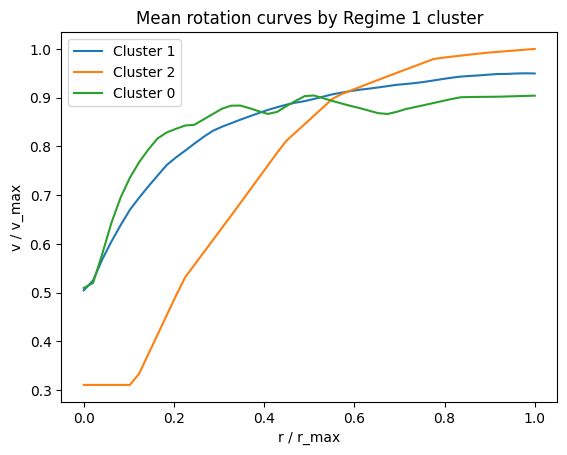

In [ ]:
# ============================================================
# SELF-CONTAINED: MEAN ROTATION CURVE PER CLUSTER
# ============================================================

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

clusters = reg1_df["cluster"].unique()

for c in clusters:
    members = reg1_df[reg1_df["cluster"] == c]["ID"]

    curves = []
    for gid in members:
        f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
        if f is None:
            continue

        data = []
        with open(f, "r", errors="ignore") as fh:
            for line in fh:
                pts = line.split()
                if len(pts) >= 2:
                    try:
                        data.append([float(pts[0]), float(pts[1])])
                    except:
                        pass

        if len(data) < 5:
            continue

        arr = np.array(data)
        r, v = arr[:,0], arr[:,1]

        x = r / np.max(r)
        y = v / np.max(v)

        xg = np.linspace(0,1,50)
        yg = np.interp(xg, x, y)

        curves.append(yg)

    if len(curves) > 0:
        mean_curve = np.mean(curves, axis=0)
        plt.plot(xg, mean_curve, label=f"Cluster {c}")

plt.legend()
plt.xlabel("r / r_max")
plt.ylabel("v / v_max")
plt.title("Mean rotation curves by Regime 1 cluster")
plt.show()

In [ ]:
# ============================================================
# SELF-CONTAINED: CAN ROTATION-CURVE SHAPE PREDICT THE
# THREE REGIME-1 SUB-FAMILIES?
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.cluster import KMeans

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGIME1_SHAPE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i - 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i + 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        lo[i - 1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit coefficients + collect shape features
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    # normalized curve-shape features
    rmax = np.max(r)
    vmax = np.max(v)
    if not np.isfinite(rmax) or not np.isfinite(vmax) or rmax <= 0 or vmax <= 0:
        continue

    x = r / rmax
    yn = v / vmax

    v20 = float(np.interp(0.2, x, yn))
    v50 = float(np.interp(0.5, x, yn))
    v80 = float(np.interp(0.8, x, yn))

    inner_slope = (v20 - yn[0]) / max(0.2 - x[0], 1e-9)
    mid_slope = (v50 - v20) / 0.3
    outer_slope = (v80 - v50) / 0.3

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef, "Bg": Bg, "Bd": Bd, "Bb": Bb, "Cgd": Cgd,
        "regime": regime,
        "v20": v20, "v50": v50, "v80": v80,
        "inner_slope": inner_slope,
        "mid_slope": mid_slope,
        "outer_slope": outer_slope,
    })

df = pd.DataFrame(rows)

# -----------------------------
# isolate Regime 1 and cluster in coefficient space
# -----------------------------
reg1 = df[df["regime"] == 1].copy()
coef_mat = reg1[["A","Bg","Bd","Bb","Cgd"]].to_numpy()

km = KMeans(n_clusters=3, n_init=20, random_state=0)
reg1["cluster"] = km.fit_predict(coef_mat)

# -----------------------------
# summarize shape features by cluster
# -----------------------------
print("Regime 1 size:", len(reg1))
print("\nMean shape features by cluster:")
print(reg1.groupby("cluster")[["v20","v50","v80","inner_slope","mid_slope","outer_slope"]].mean())

# -----------------------------
# simple nearest-centroid classification in shape space
# -----------------------------
shape_cols = ["v20","v50","v80","inner_slope","mid_slope","outer_slope"]
Xshape = reg1[shape_cols].to_numpy()
yclus = reg1["cluster"].to_numpy()

# standardize
mu = Xshape.mean(axis=0)
sd = Xshape.std(axis=0)
sd[sd == 0] = 1.0
Z = (Xshape - mu) / sd

# leave-one-out nearest-centroid classifier
pred = np.full(len(Z), -1, dtype=int)
for i in range(len(Z)):
    train_mask = np.ones(len(Z), dtype=bool)
    train_mask[i] = False

    cents = {}
    for c in np.unique(yclus):
        cents[c] = Z[train_mask & (yclus == c)].mean(axis=0)

    dists = {c: np.sum((Z[i] - cents[c])**2) for c in cents}
    pred[i] = min(dists, key=dists.get)

acc = np.mean(pred == yclus)

print("\nShape-only leave-one-out classification accuracy:", float(acc))

# confusion matrix
labels = sorted(np.unique(yclus))
conf = np.zeros((len(labels), len(labels)), dtype=int)
for t, p in zip(yclus, pred):
    conf[labels.index(t), labels.index(p)] += 1

print("\nConfusion matrix (rows=true cluster, cols=pred cluster):")
print(conf)

Regime 1 size: 49

Mean shape features by cluster:
              v20       v50       v80  inner_slope  mid_slope  outer_slope
cluster                                                                   
0        0.834229  0.907231  0.893994     1.911526   0.243338    -0.044121
1        0.773979  0.895069  0.938811     1.782183   0.403635     0.145805
2        0.485012  0.854236  0.982443     1.958315   1.230748     0.427357

Shape-only leave-one-out classification accuracy: 0.2857142857142857

Confusion matrix (rows=true cluster, cols=pred cluster):
[[ 0  2  1]
 [18 14 13]
 [ 0  1  0]]


/tmp/ipykernel_8514/366658800.py:204: RuntimeWarning: Mean of empty slice.
  cents[c] = Z[train_mask & (yclus == c)].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
# ============================================================
# SELF-CONTAINED: ORTHOGONAL-BASIS TEST
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*Vg*Vd
#
# Orthogonalized test:
#   replace [U, Vg^2, Vd^2, Vb^2, VgVd] by QR-orthogonal basis
#   fitted on each galaxy separately
#
# Goal:
#   test whether the regime/family structure survives basis
#   orthogonalization, or collapses as a basis artefact.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_ORTHO_BASIS")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def pca_stats(X):
    X = np.asarray(X, float)
    Xc = X - X.mean(axis=0)
    _, S, VT = np.linalg.svd(Xc, full_matrices=False)
    var = (S**2) / np.sum(S**2)
    cvar = np.cumsum(var)
    n95 = int(np.searchsorted(cvar, 0.95) + 1)
    return var, n95, VT

# -----------------------------
# fit original + orthogonal basis
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    y = v**2

    # original basis
    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X = X[m]
    yy = y[m]
    vv = v[m]

    coef, _, _, _ = np.linalg.lstsq(X, yy, rcond=None)
    yhat = X @ coef
    rmse_orig = float(np.sqrt(np.mean((np.sqrt(np.maximum(yhat, 0.0)) - vv)**2)))

    Acoef, Bg, Bd, Bb, Cgd = coef
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    # orthogonal basis via QR on centered/scaled columns
    Xs = X.copy().astype(float)
    col_norms = np.linalg.norm(Xs, axis=0)
    col_norms[col_norms == 0] = 1.0
    Xs /= col_norms
    Q, R = np.linalg.qr(Xs)
    coef_q, _, _, _ = np.linalg.lstsq(Q, yy, rcond=None)
    yhat_q = Q @ coef_q
    rmse_ortho = float(np.sqrt(np.mean((np.sqrt(np.maximum(yhat_q, 0.0)) - vv)**2)))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef, "Bg": Bg, "Bd": Bd, "Bb": Bb, "Cgd": Cgd,
        "regime": regime,
        "rmse_orig": rmse_orig,
        "rmse_ortho": rmse_ortho,
        "q1": coef_q[0], "q2": coef_q[1], "q3": coef_q[2], "q4": coef_q[3], "q5": coef_q[4],
    })

df = pd.DataFrame(rows)

print("Galaxies used:", len(df))

print("\nRMSE comparison")
print("Original median RMSE:", float(df["rmse_orig"].median()))
print("Orthogonal-basis median RMSE:", float(df["rmse_ortho"].median()))
print("Median change:", float((df["rmse_ortho"] - df["rmse_orig"]).median()))

print("\nOriginal regime counts")
print(df["regime"].value_counts().sort_index())

# PCA on original coefficient space by regime
for reg in [0, 1]:
    sub = df[df["regime"] == reg][["A","Bg","Bd","Bb","Cgd"]].to_numpy()
    if len(sub) < 5:
        continue
    var, n95, VT = pca_stats(sub)
    print(f"\nOriginal basis Regime {reg}")
    print("Variance explained:", [float(v) for v in var[:5]])
    print("PCs needed for 95% variance:", n95)

# PCA on orthogonal coefficient space, using same regime labels for comparison
for reg in [0, 1]:
    sub = df[df["regime"] == reg][["q1","q2","q3","q4","q5"]].to_numpy()
    if len(sub) < 5:
        continue
    var, n95, VT = pca_stats(sub)
    print(f"\nOrthogonal basis Regime {reg}")
    print("Variance explained:", [float(v) for v in var[:5]])
    print("PCs needed for 95% variance:", n95)

Galaxies used: 171

RMSE comparison
Original median RMSE: 2.7836707162151373
Orthogonal-basis median RMSE: 2.494179241861515
Median change: -0.027197684213964846

Original regime counts
regime
0    122
1     49
Name: count, dtype: int64

Original basis Regime 0
Variance explained: [0.9868429870567271, 0.009187202130051171, 0.0033594262684007495, 0.0006055034372187852, 4.8811076020923825e-06]
PCs needed for 95% variance: 1

Original basis Regime 1
Variance explained: [0.6648007284659903, 0.2698091490539062, 0.058062401961316484, 0.005596022706938315, 0.0017316978118486937]
PCs needed for 95% variance: 3

Orthogonal basis Regime 0
Variance explained: [0.9295838709604233, 0.04043193910322697, 0.017221037831038635, 0.011700927556876118, 0.0010622245484349163]
PCs needed for 95% variance: 2

Orthogonal basis Regime 1
Variance explained: [0.9511102678259054, 0.024532831018121263, 0.018554519614422598, 0.004086616259079066, 0.001715765282471645]
PCs needed for 95% variance: 1


In [ ]:
# ============================================================
# SELF-CONTAINED: DO REGIMES SURVIVE IN THE ORTHOGONAL BASIS?
# ============================================================

import numpy as np
from sklearn.cluster import KMeans

# Use orthogonal coefficients
Q = df[["q1","q2","q3","q4","q5"]].to_numpy()

# PCA for visualization / structure
Qc = Q - Q.mean(axis=0)
U,S,VT = np.linalg.svd(Qc, full_matrices=False)
coords = Qc @ VT.T

print("Variance explained (orthogonal basis):")
print((S**2)/np.sum(S**2))

# Try k-means clustering into 2 groups (same number as original regimes)
km = KMeans(n_clusters=2, n_init=20, random_state=0)
labels = km.fit_predict(Q)

# Compare with original regime labels
true = df["regime"].to_numpy()

# Build confusion matrix
conf = np.zeros((2,2),dtype=int)
for t,p in zip(true,labels):
    conf[t,p]+=1

print("\nConfusion matrix (rows=true regime, cols=new clusters):")
print(conf)

# Also check separability in first 2 PCs
print("\nMean PC1 by new cluster:",
      coords[labels==0,0].mean(),
      coords[labels==1,0].mean())

Variance explained (orthogonal basis):
[0.93724676 0.03195323 0.01860363 0.01074323 0.00145315]

Confusion matrix (rows=true regime, cols=new clusters):
[[108  14]
 [ 40   9]]

Mean PC1 by new cluster: 47466.621707325685 -305437.39185583475


In [ ]:
# ============================================================
# SELF-CONTAINED: EFFECTIVE DIMENSION TEST (1–5 COMPONENTS)
# ============================================================

import numpy as np
from pathlib import Path

dims = [1,2,3,4,5]
rmse_by_dim = {d: [] for d in dims}

for i,row in df.iterrows():
    f = next((p for p in Path("/content").rglob(f"{row['ID']}_rotmod.dat")), None)
    if f is None:
        continue

    data=[]
    with open(f,"r",errors="ignore") as fh:
        for line in fh:
            pts=line.split()
            if len(pts)>=6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass
    if len(data)<5:
        continue

    arr=np.array(data)
    r,v,_,vg,vd,vb=arr.T

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    gd =vg*vd

    rho=(vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)
    dr=np.gradient(r)
    Uobs=np.cumsum(rho*dr)

    X=np.vstack([Uobs,vg2,vd2,vb2,gd]).T
    y=v**2

    # normalize columns safely
    norms=np.linalg.norm(X,axis=0)
    norms[norms==0]=1.0
    Xn=X/norms

    Q,_=np.linalg.qr(Xn)

    for d in dims:
        q=Q[:,:d]
        coef,_,_,_=np.linalg.lstsq(q,y,rcond=None)
        v2=q@coef
        v2=np.maximum(v2,0)
        rmse=np.sqrt(np.mean((np.sqrt(v2)-v)**2))
        rmse_by_dim[d].append(rmse)

for d in dims:
    print(f"{d} components → median RMSE:", np.median(rmse_by_dim[d]))

1 components → median RMSE: 8.586023532970728
2 components → median RMSE: 6.075850667615824
3 components → median RMSE: 3.7211433919913652
4 components → median RMSE: 3.3628525314397932
5 components → median RMSE: 2.2849629659567605


In [ ]:
# ============================================================
# SELF-CONTAINED: TOP 3 ORTHOGONAL MODES IN ORIGINAL BASIS
#
# Goal:
#   Build a single common orthogonal basis from all galaxies,
#   then inspect the top 3 coefficient modes and how they load
#   onto the original physical basis:
#       U, Vg^2, Vd^2, Vb^2, VgVd
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_TOP3_MODES")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit original coefficients for all galaxies
# -----------------------------
coef_rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)

    coef_rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": coef[0],
        "Bg": coef[1],
        "Bd": coef[2],
        "Bb": coef[3],
        "Cgd": coef[4],
    })

df = pd.DataFrame(coef_rows)

# original coefficient matrix
C = df[["A","Bg","Bd","Bb","Cgd"]].to_numpy()

# PCA in original physical-basis coefficient space
Cc = C - C.mean(axis=0)
U, S, VT = np.linalg.svd(Cc, full_matrices=False)
var = (S**2) / np.sum(S**2)

print("Variance explained by top 5 modes:")
for i, v in enumerate(var, start=1):
    print(f"PC{i}: {float(v):.6f}")

basis = ["U term (A)", "Gas term (Bg)", "Disk term (Bd)", "Bulge term (Bb)", "Gas×Disk term (Cgd)"]

print("\nTop 3 mode loadings in original basis:")
for k in range(3):
    print(f"\nPC{k+1}")
    for b, val in zip(basis, VT[k]):
        print(f"  {b}: {val:+.6f}")

# also show correlations of score with each original coefficient
scores = Cc @ VT.T
for k in range(3):
    print(f"\nCorrelations of PC{k+1} score with original coefficients:")
    for j, name in enumerate(["A","Bg","Bd","Bb","Cgd"]):
        corr = np.corrcoef(scores[:,k], C[:,j])[0,1]
        print(f"  corr(PC{k+1}, {name}) = {float(corr):+.6f}")

Variance explained by top 5 modes:
PC1: 0.972112
PC2: 0.020165
PC3: 0.006852
PC4: 0.000833
PC5: 0.000039

Top 3 mode loadings in original basis:

PC1
  U term (A): +0.009170
  Gas term (Bg): -0.310750
  Disk term (Bd): -0.524570
  Bulge term (Bb): +0.000213
  Gas×Disk term (Cgd): +0.792576

PC2
  U term (A): -0.120943
  Gas term (Bg): +0.934366
  Disk term (Bd): -0.281218
  Bulge term (Bb): -0.016197
  Gas×Disk term (Cgd): +0.181621

PC3
  U term (A): +0.968822
  Gas term (Bg): +0.085869
  Disk term (Bd): -0.203432
  Bulge term (Bb): -0.006458
  Gas×Disk term (Cgd): -0.112182

Correlations of PC1 score with original coefficients:
  corr(PC1, A) = +0.109262
  corr(PC1, Bg) = -0.917361
  corr(PC1, Bd) = -0.995578
  corr(PC1, Bb) = +0.031532
  corr(PC1, Cgd) = +0.999163

Correlations of PC2 score with original coefficients:
  corr(PC2, A) = -0.207561
  corr(PC2, Bg) = +0.397272
  corr(PC2, Bd) = -0.076870
  corr(PC2, Bb) = -0.345229
  corr(PC2, Cgd) = +0.032977

Correlations of PC3 score 

In [ ]:
# ============================================================
# SELF-CONTAINED: 3-MODE RE-EXPRESSION, REFIT, AND FIT TEST
#
# Goal:
#   1) Fit the original 5-term model on all LTG galaxies
#   2) Learn the top 3 coefficient modes from the full sample
#   3) Re-express the model in those 3 modes
#   4) Refit each galaxy using ONLY those 3 mode amplitudes
#   5) Compare fit quality against the full 5-term model
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
#
# Reduced 3-mode model:
#   V^2 = a1*M1(r) + a2*M2(r) + a3*M3(r)
# where M1,M2,M3 are the top 3 learned global coefficient modes.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_3MODE_REFIT")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

# -----------------------------
# first pass: fit full 5-term model on all galaxies
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coef5, _, _, _ = np.linalg.lstsq(X5m, ym, rcond=None)
    rmse5 = rmse_from_v2(X5m @ coef5, vm)

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "Uobs": Uobs,
        "vg2": vg2,
        "vd2": vd2,
        "vb2": vb2,
        "gd": gd,
        "coef5": coef5,
        "rmse5": rmse5,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

coef_mat = np.array([row["coef5"] for row in rows], dtype=float)

# -----------------------------
# learn top 3 global coefficient modes
# -----------------------------
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
Ucoef, Scoef, VTcoef = np.linalg.svd(coef_centered, full_matrices=False)
var = (Scoef ** 2) / np.sum(Scoef ** 2)

mode1 = VTcoef[0]
mode2 = VTcoef[1]
mode3 = VTcoef[2]

print("Variance explained by coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

basis_names = ["U", "Vg^2", "Vd^2", "Vb^2", "Vg*Vd"]
print("\nTop 3 mode loadings in original basis:")
for k, mode in enumerate([mode1, mode2, mode3], start=1):
    print(f"\nMode {k}")
    for name, val in zip(basis_names, mode):
        print(f"  {name}: {val:+.6f}")

# -----------------------------
# second pass: build 3 mode basis functions per galaxy
# and refit using ONLY 3 amplitudes on those mode-functions
# -----------------------------
rmse_3mode = []
rmse_5term = []
id_list = []

for row in rows:
    r   = row["r"]
    v   = row["v"]
    Uob = row["Uobs"]
    vg2 = row["vg2"]
    vd2 = row["vd2"]
    vb2 = row["vb2"]
    gd  = row["gd"]

    # original per-radius basis matrix
    B = np.vstack([Uob, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(B).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    Bm = B[m]
    ym = y[m]
    vm = v[m]

    # full 5-term refit on same masked rows
    coef5, _, _, _ = np.linalg.lstsq(Bm, ym, rcond=None)
    rmse5 = rmse_from_v2(Bm @ coef5, vm)

    # build the 3 learned mode-functions
    # each mode-function is a fixed linear combination of the original basis columns
    M1 = Bm @ mode1
    M2 = Bm @ mode2
    M3 = Bm @ mode3
    X3 = np.vstack([M1, M2, M3]).T

    coef3, _, _, _ = np.linalg.lstsq(X3, ym, rcond=None)
    rmse3 = rmse_from_v2(X3 @ coef3, vm)

    rmse_5term.append(rmse5)
    rmse_3mode.append(rmse3)
    id_list.append(row["ID"])

rmse_5term = np.array(rmse_5term)
rmse_3mode = np.array(rmse_3mode)

print("\nFit quality comparison")
print("Galaxies used:", len(rmse_5term))
print("Median RMSE full 5-term model:", float(np.median(rmse_5term)))
print("Median RMSE 3-mode model:", float(np.median(rmse_3mode)))
print("Median degradation (3-mode - 5-term):", float(np.median(rmse_3mode - rmse_5term)))
print("Mean degradation (3-mode - 5-term):", float(np.mean(rmse_3mode - rmse_5term)))
print("3-mode better count:", int(np.sum(rmse_3mode < rmse_5term)))
print("3-mode worse count:", int(np.sum(rmse_3mode > rmse_5term)))

# optional: show best/worst affected galaxies
order = np.argsort(rmse_3mode - rmse_5term)
print("\nBest 10 galaxies for 3-mode reduction:")
for i in order[:10]:
    print(id_list[i], "delta=", float(rmse_3mode[i] - rmse_5term[i]))

print("\nWorst 10 galaxies for 3-mode reduction:")
for i in order[-10:]:
    print(id_list[i], "delta=", float(rmse_3mode[i] - rmse_5term[i]))

Variance explained by coefficient modes:
PC1: 0.972112
PC2: 0.020165
PC3: 0.006852
PC4: 0.000833
PC5: 0.000039

Top 3 mode loadings in original basis:

Mode 1
  U: +0.009170
  Vg^2: -0.310750
  Vd^2: -0.524570
  Vb^2: +0.000213
  Vg*Vd: +0.792576

Mode 2
  U: -0.120943
  Vg^2: +0.934366
  Vd^2: -0.281218
  Vb^2: -0.016197
  Vg*Vd: +0.181621

Mode 3
  U: +0.968822
  Vg^2: +0.085869
  Vd^2: -0.203432
  Vb^2: -0.006458
  Vg*Vd: -0.112182

Fit quality comparison
Galaxies used: 171
Median RMSE full 5-term model: 2.7836707162151373
Median RMSE 3-mode model: 6.086011722934564
Median degradation (3-mode - 5-term): 2.3942048194384435
Mean degradation (3-mode - 5-term): 3.7228197665828673
3-mode better count: 13
3-mode worse count: 158

Best 10 galaxies for 3-mode reduction:
NGC4010 delta= -3.5460574029399883
NGC2998 delta= -0.8029983646646563
NGC3198 delta= -0.551571017569171
ESO563-G021 delta= -0.4923760700355686
NGC2366 delta= -0.19851389769449201
NGC2976 delta= -0.1902938463870507
NGC2903 de

In [ ]:
# ============================================================
# SELF-CONTAINED: PIECEWISE 3-MODE MODEL TEST
#
# Goal:
#   1) Fit the full 5-term model on all LTG galaxies
#   2) Split galaxies into the original sign-based regimes
#   3) Learn separate top-3 PCA coefficient modes inside each regime
#   4) Refit each galaxy using ONLY the 3 modes from its own regime
#   5) Compare against the full 5-term fit
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_PIECEWISE_3MODE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

# -----------------------------
# first pass: fit full 5-term model
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coef5, _, _, _ = np.linalg.lstsq(X5m, ym, rcond=None)
    rmse5 = rmse_from_v2(X5m @ coef5, vm)

    Acoef, Bg, Bd, Bb, Cgd = coef5
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "Uobs": Uobs,
        "vg2": vg2,
        "vd2": vd2,
        "vb2": vb2,
        "gd": gd,
        "coef5": coef5,
        "rmse5": rmse5,
        "regime": regime,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

df = pd.DataFrame({
    "ID": [row["ID"] for row in rows],
    "A":  [row["coef5"][0] for row in rows],
    "Bg": [row["coef5"][1] for row in rows],
    "Bd": [row["coef5"][2] for row in rows],
    "Bb": [row["coef5"][3] for row in rows],
    "Cgd":[row["coef5"][4] for row in rows],
    "regime": [row["regime"] for row in rows],
    "rmse5": [row["rmse5"] for row in rows],
})

print("Galaxies used:", len(df))
print("\nRegime counts")
print(df["regime"].value_counts().sort_index())

# -----------------------------
# learn separate top-3 modes inside each regime
# -----------------------------
regime_modes = {}
regime_means = {}

for reg in [0, 1]:
    sub = df[df["regime"] == reg][["A","Bg","Bd","Bb","Cgd"]].to_numpy()
    sub_mean = sub.mean(axis=0)
    sub_centered = sub - sub_mean
    _, S, VT = np.linalg.svd(sub_centered, full_matrices=False)
    var = (S ** 2) / np.sum(S ** 2)

    regime_means[reg] = sub_mean
    regime_modes[reg] = VT[:3]

    print(f"\nRegime {reg} mode variance explained:")
    for i, vexp in enumerate(var[:5], start=1):
        print(f"PC{i}: {float(vexp):.6f}")

# -----------------------------
# second pass: refit each galaxy using ONLY its regime's 3 modes
# -----------------------------
rmse_piecewise = []
rmse_full = []
delta_list = []
ids = []

for row in rows:
    r   = row["r"]
    v   = row["v"]
    Uob = row["Uobs"]
    vg2 = row["vg2"]
    vd2 = row["vd2"]
    vb2 = row["vb2"]
    gd  = row["gd"]
    reg = row["regime"]

    B = np.vstack([Uob, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(B).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    Bm = B[m]
    ym = y[m]
    vm = v[m]

    # full 5-term fit on same rows
    coef5, _, _, _ = np.linalg.lstsq(Bm, ym, rcond=None)
    rmse5 = rmse_from_v2(Bm @ coef5, vm)

    # build regime-specific 3 mode functions
    modes = regime_modes[reg]   # shape (3,5)
    M = Bm @ modes.T            # shape (n,3)

    coef3, _, _, _ = np.linalg.lstsq(M, ym, rcond=None)
    rmse3 = rmse_from_v2(M @ coef3, vm)

    ids.append(row["ID"])
    rmse_full.append(rmse5)
    rmse_piecewise.append(rmse3)
    delta_list.append(rmse3 - rmse5)

rmse_full = np.array(rmse_full)
rmse_piecewise = np.array(rmse_piecewise)
delta_list = np.array(delta_list)

print("\nFit quality comparison")
print("Median RMSE full 5-term model:", float(np.median(rmse_full)))
print("Median RMSE piecewise 3-mode model:", float(np.median(rmse_piecewise)))
print("Median degradation:", float(np.median(delta_list)))
print("Mean degradation:", float(np.mean(delta_list)))
print("Piecewise 3-mode better count:", int(np.sum(delta_list < 0)))
print("Piecewise 3-mode worse count:", int(np.sum(delta_list > 0)))

order = np.argsort(delta_list)
print("\nBest 10 galaxies for piecewise 3-mode reduction:")
for i in order[:10]:
    print(ids[i], "delta=", float(delta_list[i]))

print("\nWorst 10 galaxies for piecewise 3-mode reduction:")
for i in order[-10:]:
    print(ids[i], "delta=", float(delta_list[i]))

Galaxies used: 171

Regime counts
regime
0    122
1     49
Name: count, dtype: int64

Regime 0 mode variance explained:
PC1: 0.986843
PC2: 0.009187
PC3: 0.003359
PC4: 0.000606
PC5: 0.000005

Regime 1 mode variance explained:
PC1: 0.664801
PC2: 0.269809
PC3: 0.058062
PC4: 0.005596
PC5: 0.001732

Fit quality comparison
Median RMSE full 5-term model: 2.7836707162151373
Median RMSE piecewise 3-mode model: 4.514959586824766
Median degradation: 1.1081617674707793
Mean degradation: 4.322978108219987
Piecewise 3-mode better count: 13
Piecewise 3-mode worse count: 158

Best 10 galaxies for piecewise 3-mode reduction:
NGC4010 delta= -4.599740615553733
NGC2998 delta= -0.7560966472901463
F583-1 delta= -0.6864619752739447
F574-1 delta= -0.5473095164512305
ESO563-G021 delta= -0.3809913654212771
NGC2915 delta= -0.36679189134000545
NGC4389 delta= -0.13781636826872834
NGC2976 delta= -0.12010036656588641
NGC2903 delta= -0.06755554799138608
UGC07866 delta= -0.04920220654157881

Worst 10 galaxies for piec

In [ ]:
# ============================================================
# SELF-CONTAINED: RIDGE-REGULARIZED DEGENERACY TEST
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
#
# Goal:
#   Scan ridge penalty lambda and test whether coefficient
#   degeneracy can be reduced without significantly degrading fit.
#
# Reports:
#   - median RMSE vs lambda
#   - mean RMSE vs lambda
#   - median coefficient norm vs lambda
#   - coefficient spread vs lambda
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_RIDGE_TEST")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def ridge_fit(X, y, lam):
    # solve (X^T X + lam I) c = X^T y
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    coef = np.linalg.solve(XtX + lam * I, Xty)
    return coef

# -----------------------------
# gather per-galaxy design matrices
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "X": X[m],
        "y": y[m],
        "v": v[m],
    })

if len(galaxies) < 10:
    raise RuntimeError("Too few usable galaxies")

# -----------------------------
# scan ridge penalties
# -----------------------------
lambdas = [0.0, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0, 1000.0]
summary_rows = []

for lam in lambdas:
    rmses = []
    norms = []
    coefs = []

    for g in galaxies:
        X = g["X"]
        y = g["y"]
        v = g["v"]

        if lam == 0.0:
            coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        else:
            coef = ridge_fit(X, y, lam)

        coefs.append(coef)
        norms.append(float(np.linalg.norm(coef)))
        rmses.append(rmse_from_v2(X @ coef, v))

    coefs = np.array(coefs)
    coef_std = coefs.std(axis=0)
    summary_rows.append({
        "lambda": lam,
        "median_rmse": float(np.median(rmses)),
        "mean_rmse": float(np.mean(rmses)),
        "median_coef_norm": float(np.median(norms)),
        "std_A": float(coef_std[0]),
        "std_Bg": float(coef_std[1]),
        "std_Bd": float(coef_std[2]),
        "std_Bb": float(coef_std[3]),
        "std_Cgd": float(coef_std[4]),
    })

summary = pd.DataFrame(summary_rows)

print(summary.to_string(index=False))

# show best tradeoff row relative to unregularized fit
base_rmse = summary.loc[summary["lambda"] == 0.0, "median_rmse"].iloc[0]
summary["rmse_delta"] = summary["median_rmse"] - base_rmse
summary["total_coef_std"] = summary[["std_A","std_Bg","std_Bd","std_Bb","std_Cgd"]].sum(axis=1)

print("\nBest small-penalty tradeoffs (sorted by RMSE increase then coefficient spread):")
print(
    summary.sort_values(["rmse_delta", "total_coef_std"])
           [["lambda","median_rmse","rmse_delta","median_coef_norm","total_coef_std"]]
           .to_string(index=False)
)

     lambda  median_rmse  mean_rmse  median_coef_norm    std_A    std_Bg    std_Bd   std_Bb   std_Cgd
   0.000000     2.783671   4.109814          8.977887 8.124355 32.793274 51.008388 0.654164 76.792331
   0.000001     2.783671   4.109814          8.977887 8.124351 32.793161 51.008175 0.654164 76.792011
   0.000100     2.783671   4.109814          8.977887 8.124011 32.782070 50.987182 0.654164 76.760327
   0.010000     2.783671   4.109739          8.977887 8.100142 31.740414 48.973868 0.654163 73.730565
   1.000000     2.783748   4.112231          8.922925 8.047945 16.340653 10.606254 0.653989 16.442804
  10.000000     2.784424   4.113652          8.533327 7.918792 15.183024  4.431951 0.652419  7.037152
 100.000000     2.789454   4.130145          8.139363 7.044224 14.347930  3.553838 0.637604  5.629476
1000.000000     2.864099   4.215530          6.874906 4.950069 11.698257  2.358891 0.545355  4.208155

Best small-penalty tradeoffs (sorted by RMSE increase then coefficient spread):
 

In [ ]:
# ============================================================
# SELF-CONTAINED: REGULARIZED REFIT + PCA OF STABILIZED MODEL
#
# Goal:
#   1) Refit all galaxies with ridge regularization
#   2) Use a fixed lambda (default below = 1.0)
#   3) Compare fit quality vs unregularized model
#   4) Run PCA on the regularized coefficients
#   5) Show whether the coefficient manifold becomes cleaner
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# choose regularization strength
# -----------------------------
LAMBDA = 1.0   # try also 10.0 after this if you want

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGULARIZED_PCA")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

# -----------------------------
# fit all galaxies
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X = X[m]
    y = y[m]
    v = v[m]

    # unregularized fit
    coef0, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    rmse0 = rmse_from_v2(X @ coef0, v)

    # regularized fit
    coefR = ridge_fit(X, y, LAMBDA)
    rmseR = rmse_from_v2(X @ coefR, v)

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A0": coef0[0], "Bg0": coef0[1], "Bd0": coef0[2], "Bb0": coef0[3], "Cgd0": coef0[4],
        "AR": coefR[0], "BgR": coefR[1], "BdR": coefR[2], "BbR": coefR[3], "CgdR": coefR[4],
        "rmse0": rmse0,
        "rmseR": rmseR,
    })

df = pd.DataFrame(rows)
if len(df) < 10:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(df))
print("\nFit quality")
print("Median RMSE unregularized:", float(df["rmse0"].median()))
print("Median RMSE regularized  :", float(df["rmseR"].median()))
print("Median degradation       :", float((df["rmseR"] - df["rmse0"]).median()))
print("Mean degradation         :", float((df["rmseR"] - df["rmse0"]).mean()))

# -----------------------------
# PCA on regularized coefficients
# -----------------------------
C = df[["AR","BgR","BdR","BbR","CgdR"]].to_numpy()
Cc = C - C.mean(axis=0)

_, S, VT = np.linalg.svd(Cc, full_matrices=False)
var = (S**2) / np.sum(S**2)
cvar = np.cumsum(var)
n95 = int(np.searchsorted(cvar, 0.95) + 1)

print("\nRegularized coefficient PCA")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")
print("PCs needed for 95% variance:", n95)

basis = ["A", "Bg", "Bd", "Bb", "Cgd"]
print("\nTop 3 regularized mode loadings:")
for k in range(3):
    print(f"\nPC{k+1}")
    for b, val in zip(basis, VT[k]):
        print(f"  {b}: {val:+.6f}")

# -----------------------------
# compare coefficient spreads
# -----------------------------
print("\nCoefficient spreads (std across galaxies)")
for base, reg in [("A0","AR"), ("Bg0","BgR"), ("Bd0","BdR"), ("Bb0","BbR"), ("Cgd0","CgdR")]:
    print(f"{base[:-1]}  unreg={df[base].std():.6f}   reg={df[reg].std():.6f}")

# optional: regime counts using original sign rule on regularized coefficients
regimeR = ((df["BgR"] > 0) & (df["BdR"] > 0) & (df["CgdR"] < 0)).astype(int)
print("\nRegularized regime counts (same sign rule):")
print(regimeR.value_counts().sort_index())

Galaxies used: 171

Fit quality
Median RMSE unregularized: 2.7836707162151373
Median RMSE regularized  : 2.7837478631902433
Median degradation       : 2.5988259988452e-08
Mean degradation         : 0.002416096410405808

Regularized coefficient PCA
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518
PCs needed for 95% variance: 3

Top 3 regularized mode loadings:

PC1
  A: +0.104962
  Bg: -0.589559
  Bd: -0.404435
  Bb: +0.005955
  Cgd: +0.691231

PC2
  A: -0.003567
  Bg: -0.797370
  Bd: +0.417656
  Bb: +0.015943
  Cgd: -0.435314

PC3
  A: +0.965480
  Bg: +0.030408
  Bd: -0.151775
  Bb: -0.005393
  Cgd: -0.209426

Coefficient spreads (std across galaxies)
A  unreg=8.148215   reg=8.071581
Bg  unreg=32.889583   reg=16.388643
Bd  unreg=51.158192   reg=10.637404
Bb  unreg=0.656086   reg=0.655910
Cgd  unreg=77.017860   reg=16.491094

Regularized regime counts (same sign rule):
0    122
1     49
Name: count, dtype: int64


In [ ]:
# ============================================================
# SELF-CONTAINED: PREDICTIVE TEST FOR REGULARIZED 3-MODE MODEL
#
# Aim:
#   Test whether the 3 stabilized effective degrees of freedom
#   can be predicted from baryonic/source structure alone.
#
# Pipeline:
#   1) build raw 5-term basis from LTG rotmod files
#   2) fit ridge-regularized coefficients per galaxy
#   3) PCA those coefficients -> 3 stabilized modes
#   4) compute baryonic/source summary features per galaxy
#   5) 5-fold CV: predict 3 mode amplitudes from features
#   6) reconstruct V(r) with NO per-galaxy curve fitting
#
# Interpretation:
#   - good RMSE => real predictive bridge
#   - bad RMSE  => current model still not predictive
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
N_FOLDS = 5
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_PREDICTIVE_3MODE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

def safe_log10(x):
    x = np.asarray(x, float)
    return np.log10(np.maximum(x, 1e-30))

# -----------------------------
# first pass: build per-galaxy objects
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coefR = ridge_fit(X5m, ym, LAMBDA)
    rmseR = rmse_from_v2(X5m @ coefR, vm)

    # baryonic/source features only
    gas_int  = float(np.trapezoid(np.maximum(vg2, 0.0), r))
    disk_int = float(np.trapezoid(np.maximum(vd2, 0.0), r))
    bulg_int = float(np.trapezoid(np.maximum(vb2, 0.0), r))
    gd_int   = float(np.trapezoid(np.maximum(gd, 0.0), r))
    U_int    = float(np.trapezoid(np.maximum(Uobs, 0.0), r))

    r_g_peak = float(r[np.argmax(vg2)]) if np.any(np.isfinite(vg2)) else np.nan
    r_d_peak = float(r[np.argmax(vd2)]) if np.any(np.isfinite(vd2)) else np.nan
    r_u_half = weighted_half_radius(r, Uobs)
    r_g_half = weighted_half_radius(r, vg2)
    r_d_half = weighted_half_radius(r, vd2)

    vmax = float(np.max(v))
    rmax = float(np.max(r))
    v20 = float(np.interp(0.2 * rmax, r, v))
    v50 = float(np.interp(0.5 * rmax, r, v))
    v80 = float(np.interp(0.8 * rmax, r, v))

    feat = np.array([
        safe_log10(gas_int),
        safe_log10(disk_int),
        safe_log10(bulg_int),
        safe_log10(gd_int),
        safe_log10(U_int),
        gas_int / (disk_int + 1e-30),
        gd_int / (disk_int + 1e-30),
        gd_int / (gas_int + 1e-30),
        r_g_peak / (rmax + 1e-30),
        r_d_peak / (rmax + 1e-30),
        (r_g_peak - r_d_peak) / (rmax + 1e-30),
        r_u_half / (rmax + 1e-30) if np.isfinite(r_u_half) else np.nan,
        r_g_half / (rmax + 1e-30) if np.isfinite(r_g_half) else np.nan,
        r_d_half / (rmax + 1e-30) if np.isfinite(r_d_half) else np.nan,
        vmax,
        v20 / (vmax + 1e-30),
        v50 / (vmax + 1e-30),
        v80 / (vmax + 1e-30),
    ], dtype=float)

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "X5": X5m,
        "coefR": coefR,
        "rmseR": rmseR,
        "feat": feat,
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

# drop any rows with bad features
good = []
for g in galaxies:
    if np.all(np.isfinite(g["feat"])):
        good.append(g)
galaxies = good

print("Galaxies used:", len(galaxies))

# -----------------------------
# coefficient PCA -> 3 stabilized modes
# -----------------------------
coef_mat = np.array([g["coefR"] for g in galaxies], dtype=float)
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
_, S, VT = np.linalg.svd(coef_centered, full_matrices=False)
var = (S ** 2) / np.sum(S ** 2)

print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

modes = VT[:3]                      # shape (3,5)
scores = coef_centered @ modes.T    # shape (N,3)
features = np.array([g["feat"] for g in galaxies], dtype=float)

# -----------------------------
# 5-fold CV: predict 3 scores from baryonic features
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_pred = []
rmse_fit = []
score_err = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = features[tr]
    Xte = features[te]

    # standardize features on train only
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    Ztr = (Xtr - mu) / sd
    Zte = (Xte - mu) / sd

    # add intercept
    Ztr_i = np.column_stack([np.ones(len(Ztr)), Ztr])
    Zte_i = np.column_stack([np.ones(len(Zte)), Zte])

    # predict 3 PCA scores independently with ridge
    Ytr = scores[tr]   # (n_train, 3)

    pred_scores = np.zeros((len(te), 3))
    for j in range(3):
        beta = ridge_fit(Ztr_i, Ytr[:, j], 1.0)
        pred_scores[:, j] = Zte_i @ beta

    # reconstruct predicted coefficients
    pred_coef = coef_mean + pred_scores @ modes

    for k, idx in enumerate(te):
        g = galaxies[idx]
        X5 = g["X5"]
        v  = g["v"][:len(X5)]  # X5 was masked version; lengths should match after masking choice above
        # safer: reconstruct v from X rows count
        v_use = g["v"][:len(X5)]
        if len(v_use) != len(X5):
            v_use = g["v"][:len(X5)]

        # true regularized fit RMSE
        rmse_fit.append(g["rmseR"])

        # predicted coefficients -> predicted curve
        v2_pred = X5 @ pred_coef[k]
        rmse_pred.append(rmse_from_v2(v2_pred, v_use))

        # score prediction error
        score_err.append(float(np.linalg.norm(pred_scores[k] - scores[idx])))

rmse_fit = np.array(rmse_fit)
rmse_pred = np.array(rmse_pred)
score_err = np.array(score_err)

print("\nOut-of-sample predictive test")
print("Median RMSE using per-galaxy regularized fit:", float(np.median(rmse_fit)))
print("Median RMSE using predicted 3-mode amplitudes:", float(np.median(rmse_pred)))
print("Median predictive degradation:", float(np.median(rmse_pred - rmse_fit)))
print("Mean predictive degradation:", float(np.mean(rmse_pred - rmse_fit)))
print("Predicted better count:", int(np.sum(rmse_pred < rmse_fit)))
print("Predicted worse count:", int(np.sum(rmse_pred > rmse_fit)))

print("\nMode-amplitude prediction error")
print("Median ||pred_score - true_score||:", float(np.median(score_err)))
print("Mean   ||pred_score - true_score||:", float(np.mean(score_err)))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Out-of-sample predictive test
Median RMSE using per-galaxy regularized fit: 2.7837478631902433
Median RMSE using predicted 3-mode amplitudes: 34.213063806381456
Median predictive degradation: 31.49413127554344
Mean predictive degradation: 67.13249220158656
Predicted better count: 0
Predicted worse count: 171

Mode-amplitude prediction error
Median ||pred_score - true_score||: 9.267885221670433
Mean   ||pred_score - true_score||: 15.73827465330846


In [ ]:
# ============================================================
# SELF-CONTAINED: FULL-PROFILE PREDICTIVE TEST FOR THE
# REGULARIZED 3-MODE MODEL
#
# Aim:
#   Predict the 3 stabilized mode amplitudes from the FULL
#   baryonic/source radial profiles, not summary scalars.
#
# Pipeline:
#   1) build raw 5-term basis from LTG rotmod files
#   2) fit ridge-regularized coefficients per galaxy
#   3) PCA those coefficients -> 3 stabilized modes
#   4) represent each galaxy by full normalized radial profiles:
#        U(r), Vg^2(r), Vd^2(r), Vb^2(r), Vg*Vd(r)
#      resampled onto a common x = r/rmax grid
#   5) 5-fold CV: predict 3 mode amplitudes from those profiles
#   6) reconstruct V(r) with NO per-galaxy curve fitting
#
# Interpretation:
#   - good RMSE => missing info was in full profile shape
#   - bad RMSE  => current model still not predictive from
#                  available baryonic/source inputs
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
N_FOLDS = 5
GRID_N = 64

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_FULLPROFILE_PREDICT")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def resample_profile(x, y, xg):
    return np.interp(xg, x, y, left=y[0], right=y[-1])

def normalize_profile(y):
    y = np.asarray(y, float)
    scale = np.max(np.abs(y))
    if not np.isfinite(scale) or scale <= 0:
        return np.zeros_like(y)
    return y / scale

# -----------------------------
# build per-galaxy objects
# -----------------------------
galaxies = []
xg = np.linspace(0.0, 1.0, GRID_N)

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]
    rm = r[m]

    coefR = ridge_fit(X5m, ym, LAMBDA)
    rmseR = rmse_from_v2(X5m @ coefR, vm)

    rmax = np.max(rm)
    if not np.isfinite(rmax) or rmax <= 0:
        continue
    x = rm / rmax

    # full profile feature vector from source terms only
    feat_parts = []
    for prof in [Uobs[m], vg2[m], vd2[m], vb2[m], gd[m]]:
        prof_g = resample_profile(x, prof, xg)
        feat_parts.append(normalize_profile(prof_g))
    feat = np.concatenate(feat_parts)

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": rm,
        "v": vm,
        "X5": X5m,
        "coefR": coefR,
        "rmseR": rmseR,
        "feat": feat,
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(galaxies))

# -----------------------------
# coefficient PCA -> 3 stabilized modes
# -----------------------------
coef_mat = np.array([g["coefR"] for g in galaxies], dtype=float)
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
_, S, VT = np.linalg.svd(coef_centered, full_matrices=False)
var = (S ** 2) / np.sum(S ** 2)

print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

modes = VT[:3]
scores = coef_centered @ modes.T
features = np.array([g["feat"] for g in galaxies], dtype=float)

# -----------------------------
# 5-fold CV: predict 3 scores from full profiles
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_fit = []
rmse_pred = []
score_err = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = features[tr]
    Xte = features[te]

    # standardize features on train only
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    Ztr = (Xtr - mu) / sd
    Zte = (Xte - mu) / sd

    # add intercept
    Ztr_i = np.column_stack([np.ones(len(Ztr)), Ztr])
    Zte_i = np.column_stack([np.ones(len(Zte)), Zte])

    Ytr = scores[tr]

    pred_scores = np.zeros((len(te), 3))
    for j in range(3):
        beta = ridge_fit(Ztr_i, Ytr[:, j], 1.0)
        pred_scores[:, j] = Zte_i @ beta

    pred_coef = coef_mean + pred_scores @ modes

    for k, idx in enumerate(te):
        g = galaxies[idx]
        X5 = g["X5"]
        v  = g["v"]

        rmse_fit.append(g["rmseR"])
        rmse_pred.append(rmse_from_v2(X5 @ pred_coef[k], v))
        score_err.append(float(np.linalg.norm(pred_scores[k] - scores[idx])))

rmse_fit = np.array(rmse_fit)
rmse_pred = np.array(rmse_pred)
score_err = np.array(score_err)

print("\nOut-of-sample predictive test")
print("Median RMSE using per-galaxy regularized fit:", float(np.median(rmse_fit)))
print("Median RMSE using predicted 3-mode amplitudes:", float(np.median(rmse_pred)))
print("Median predictive degradation:", float(np.median(rmse_pred - rmse_fit)))
print("Mean predictive degradation:", float(np.mean(rmse_pred - rmse_fit)))
print("Predicted better count:", int(np.sum(rmse_pred < rmse_fit)))
print("Predicted worse count:", int(np.sum(rmse_pred > rmse_fit)))

print("\nMode-amplitude prediction error")
print("Median ||pred_score - true_score||:", float(np.median(score_err)))
print("Mean   ||pred_score - true_score||:", float(np.mean(score_err)))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Out-of-sample predictive test
Median RMSE using per-galaxy regularized fit: 2.7837478631902433
Median RMSE using predicted 3-mode amplitudes: 56.06077864832261
Median predictive degradation: 51.64714614240776
Mean predictive degradation: 99.60792029393234
Predicted better count: 0
Predicted worse count: 171

Mode-amplitude prediction error
Median ||pred_score - true_score||: 17.24352209054709
Mean   ||pred_score - true_score||: 23.31895731837839


In [ ]:
# ============================================================
# SELF-CONTAINED: SEARCH FOR A MISSING NONLOCAL STATE VARIABLE
#
# Aim:
#   Build theory-guided nonlocal baryonic invariants from raw
#   gas/disk/bulge/source profiles and test whether any one of
#   them controls the 3 stabilized regularized modes.
#
# Why this is the right next step:
#   The current model is not predictive from baryonic profiles
#   alone. So the next smallest theory move is to identify a
#   missing state scalar that could be added to the field/source
#   formulation.
#
# Outputs:
#   - correlations of each invariant with Mode1, Mode2, Mode3
#   - top invariants for each mode
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5
EPS = 1e-30

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_MISSING_STATE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

def norm_profile(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    area = np.trapezoid(w, r)
    if not np.isfinite(area) or area <= 0:
        return np.zeros_like(w)
    return w / area

def cumulative_profile(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.zeros_like(w)
    return c / tot

# -----------------------------
# build galaxies + regularized coefficients
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v**2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    r  = r[m]
    vg2 = vg2[m]
    vd2 = vd2[m]
    vb2 = vb2[m]
    gd  = gd[m]
    Uobs = Uobs[m]
    X5 = X5[m]
    y  = y[m]

    coefR = ridge_fit(X5, y, LAMBDA)

    # normalized profiles
    pg = norm_profile(r, vg2)
    norm_disk_profile = norm_profile(r, vd2) # Renamed 'pd' to 'norm_disk_profile'
    pb = norm_profile(r, vb2)
    pu = norm_profile(r, Uobs)
    pm = norm_profile(r, np.maximum(gd, 0.0))

    Cg = cumulative_profile(r, vg2)
    Cd = cumulative_profile(r, vd2)
    Cu = cumulative_profile(r, Uobs)

    rmax = np.max(r)
    x = r / (rmax + EPS)

    gas_int  = float(np.trapezoid(vg2, r))
    disk_int = float(np.trapezoid(vd2, r))
    bulg_int = float(np.trapezoid(vb2, r))
    mix_int  = float(np.trapezoid(np.maximum(gd, 0.0), r))
    U_int    = float(np.trapezoid(Uobs, r))

    rg_half = weighted_half_radius(r, vg2)
    rd_half = weighted_half_radius(r, vd2)
    ru_half = weighted_half_radius(r, Uobs)

    # theory-guided nonlocal invariants
    inv = {
        "gas_frac": gas_int / (gas_int + disk_int + bulg_int + EPS),
        "mix_over_disk": mix_int / (disk_int + EPS),
        "mix_over_gas": mix_int / (gas_int + EPS),
        "U_over_bary": U_int / (gas_int + disk_int + bulg_int + EPS),

        "half_sep_gd": (rg_half - rd_half) / (rmax + EPS) if np.isfinite(rg_half) and np.isfinite(rd_half) else np.nan,
        "half_sep_ud": (ru_half - rd_half) / (rmax + EPS) if np.isfinite(ru_half) and np.isfinite(rd_half) else np.nan,

        # cumulative mismatch / ordering
        "cum_mismatch_gd": float(np.trapezoid(np.abs(Cg - Cd), x)),
        "cum_signed_gd": float(np.trapezoid(Cg - Cd, x)),
        "cum_mismatch_ud": float(np.trapezoid(np.abs(Cu - Cd), x)),
        "cum_signed_ud": float(np.trapezoid(Cu - Cd, x)),

        # local mixing geometry
        "profile_overlap_gd": float(np.trapezoid(pg * norm_disk_profile, x)), # Use renamed variable
        "profile_overlap_ud": float(np.trapezoid(pu * norm_disk_profile, x)), # Use renamed variable
        "profile_overlap_gm": float(np.trapezoid(pg * pm, x)),

        # radial moments
        "gas_first_moment": float(np.trapezoid(x * pg, x)),
        "disk_first_moment": float(np.trapezoid(x * norm_disk_profile, x)), # Use renamed variable
        "U_first_moment": float(np.trapezoid(x * pu, x)),
        "mix_first_moment": float(np.trapezoid(x * pm, x)),

        # concentration / spread
        "gas_second_moment": float(np.trapezoid((x**2) * pg, x)),
        "disk_second_moment": float(np.trapezoid((x**2) * norm_disk_profile, x)), # Use renamed variable
        "U_second_moment": float(np.trapezoid((x**2) * pu, x)),
        "mix_second_moment": float(np.trapezoid((x**2) * pm, x)),
    }

    row = {"ID": f.stem.replace("_rotmod", ""), "A": coefR[0], "Bg": coefR[1], "Bd": coefR[2], "Bb": coefR[3], "Cgd": coefR[4]}
    row.update(inv)
    rows.append(row)

df = pd.DataFrame(rows)
if len(df) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(df))

# -----------------------------
# PCA of regularized coefficients -> 3 stabilized modes
# -----------------------------
C = df[["A","Bg","Bd","Bb","Cgd"]].to_numpy()
Cc = C - C.mean(axis=0)
_, S, VT = np.linalg.svd(Cc, full_matrices=False)
scores = Cc @ VT.T

df["mode1"] = scores[:,0]
df["mode2"] = scores[:,1]
df["mode3"] = scores[:,2]

var = (S**2) / np.sum(S**2)
print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

# -----------------------------
# correlation table
# -----------------------------
inv_cols = [c for c in df.columns if c not in ["ID","A","Bg","Bd","Bb","Cgd","mode1","mode2","mode3"]]

corr_rows = []
for col in inv_cols:
    corr_rows.append({
        "invariant": col,
        "corr_mode1": corr(df[col], df["mode1"]),
        "corr_mode2": corr(df[col], df["mode2"]),
        "corr_mode3": corr(df[col], df["mode3"]),
    })

ctab = pd.DataFrame(corr_rows)

print("\nTop invariants for Mode 1")
print(ctab.reindex(ctab["corr_mode1"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

print("\nTop invariants for Mode 2")
print(ctab.reindex(ctab["corr_mode2"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

print("\nTop invariants for Mode 3")
print(ctab.reindex(ctab["corr_mode3"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Top invariants for Mode 1
      invariant  corr_mode1  corr_mode2  corr_mode3
cum_mismatch_gd   -0.234411    0.069259   -0.013231
    half_sep_ud   -0.226288   -0.135024    0.052931
    half_sep_gd   -0.225766    0.027880   -0.010169
  cum_signed_gd    0.221463   -0.071644    0.007392
cum_mismatch_ud   -0.220943   -0.122030    0.059472
  cum_signed_ud    0.220012    0.123272   -0.061152
  mix_over_disk    0.210915   -0.135311    0.233896
       gas_frac    0.189368   -0.120087    0.236873
   mix_over_gas   -0.177788   -0.040497   -0.208521
    U_over_bary   -0.149312   -0.079852   -0.224217

Top invariants for Mode 2
      invariant  corr_mode1  corr_mode2  corr_mode3
  mix_over_disk    0.210915   -0.135311    0.233896
    half_sep_ud   -0.226288   -0.135024    0.052931
  cum_signed_ud    0.220012    0.123272   -0.061152
cum_mismatch_ud   -0.22

In [ ]:
# ============================================================
# SELF-CONTAINED: UNIVERSAL NONLOCAL SOURCE TEST
#
# Aim:
#   Smallest theory change:
#   add one universal nonlocal transport channel T(r) to the source,
#   then ask whether ONE global coefficient set predicts held-out
#   galaxies.
#
# Model tested:
#   V^2(r) = a*Ubar(r) + b*T(r) + c*Vg^2(r) + d*Vd^2(r) + e*(Vg*Vd)(r)
#
# where:
#   Ubar(r) = field solution from rho_bar
#   T(r)    = smoothed cumulative gas-disk mismatch channel
#
# This is the right next test because:
#   - it does not add per-galaxy fit freedom
#   - it promotes the missing ingredient into the source law
#   - it gives a direct predictive yes/no answer
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# universal transport parameters to test
ELL = 0.25      # smoothing length in units of r_max
ETA = 1.0       # source weight of transport channel
RIDGE = 1.0     # small stabilizer for global fit
N_FOLDS = 5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_UNIVERSAL_NONLOCAL_TEST")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field_from_source(r_src, src):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    srcg = np.interp(rg, r_src, src, left=src[0], right=src[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * srcg[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def cumulative_norm(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    c = np.zeros_like(w)
    if len(r) > 1:
        c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.zeros_like(w)
    return c / tot

def smooth_exp_kernel(x, y, ell):
    # causal exponential smoothing on common grid x in [0,1]
    out = np.zeros_like(y)
    if len(x) < 2:
        return out
    dx = np.diff(x)
    out[0] = y[0]
    for i in range(1, len(x)):
        a = np.exp(-dx[i-1] / max(ell, 1e-6))
        out[i] = a * out[i-1] + (1 - a) * y[i]
    return out

# -----------------------------
# build per-galaxy design blocks
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    # baseline source
    rho_bar = vbar2 / np.sqrt(r**2 + R_CORE**2)

    # cumulative gas-disk ordering on native grid
    Cg = cumulative_norm(r, vg2)
    Cd = cumulative_norm(r, vd2)
    mismatch = Cg - Cd

    # transport channel T(r): smoothed mismatch mapped back into source units
    x = r / np.max(r)
    Traw = smooth_exp_kernel(x, mismatch, ELL)

    # amplitude-match transport channel to baryonic source scale
    # using same shape but normalized to comparable magnitude
    scale = np.max(np.abs(rho_bar))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    if np.max(np.abs(Traw)) > 0:
        T = scale * Traw / np.max(np.abs(Traw))
    else:
        T = np.zeros_like(Traw)

    # solve field only from baryonic source
    rg, Ubar = solve_field_from_source(r, rho_bar)
    Ubar_obs = np.interp(r, rg, Ubar)

    # global predictive basis
    X = np.vstack([Ubar_obs, T, vg2, vd2, gd]).T
    y = v**2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "X": X[m],
        "y": y[m],
        "v": v[m],
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(galaxies))

# -----------------------------
# groupwise cross-validation
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_pred = []
coef_list = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = np.vstack([galaxies[i]["X"] for i in tr])
    ytr = np.concatenate([galaxies[i]["y"] for i in tr])

    coef = ridge_fit(Xtr, ytr, RIDGE)
    coef_list.append(coef)

    for i in te:
        X = galaxies[i]["X"]
        v = galaxies[i]["v"]
        rmse_pred.append(rmse_from_v2(X @ coef, v))

rmse_pred = np.array(rmse_pred)
coef_mat = np.array(coef_list)

print("\nUniversal predictive test")
print("Median RMSE (held-out galaxies):", float(np.median(rmse_pred)))
print("Mean RMSE   (held-out galaxies):", float(np.mean(rmse_pred)))

print("\nFold-to-fold coefficient stability")
names = ["a_Ubar", "b_T", "c_Vg2", "d_Vd2", "e_gd"]
for j, name in enumerate(names):
    print(name,
          "mean=", float(np.mean(coef_mat[:, j])),
          "std=",  float(np.std(coef_mat[:, j])))

print("\nMean universal coefficients")
for j, name in enumerate(names):
    print(name, "=", float(np.mean(coef_mat[:, j])))

Galaxies used: 171

Universal predictive test
Median RMSE (held-out galaxies): 22.46587634056846
Mean RMSE   (held-out galaxies): 27.886433034090306

Fold-to-fold coefficient stability
a_Ubar mean= 0.9862414929528291 std= 0.050627222223762085
b_T mean= 0.1232412476814917 std= 0.05160143614765994
c_Vg2 mean= 4.678988052157295 std= 1.0368541745838906
d_Vd2 mean= 0.6474536279081055 std= 0.0943924554238088
e_gd mean= -1.4213983674673176 std= 0.3612104389373002

Mean universal coefficients
a_Ubar = 0.9862414929528291
b_T = 0.1232412476814917
c_Vg2 = 4.678988052157295
d_Vd2 = 0.6474536279081055
e_gd = -1.4213983674673176


In [ ]:
# ============================================================
# NONLOCAL INTERACTION AMPLITUDE TEST
#
# Tests the amplitude law
#
#   V_inf^2 = K * J
#
# where
#
#   J = ∫ |Vg(r) * Vd(r)| * (U(r)/U_inf) dr
#
# and
#
#   U(r) = ∫ V_bar^2(r) dr
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE using
#       V(r) = V_inf * U(r)/U_inf
#
# This is the first direct test of a nonlocal interaction
# functional weighted by cumulative field structure.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy
# -------------------------
def build_U_and_J(r, vg, vd):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vbar2 = vg2 + vd2

    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    weight = U / U_inf
    J = float(np.trapezoid(np.abs(vg * vd) * weight, r))
    J = max(J, 1e-12)

    return U, U_inf, J

def predict_curve(g, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    shape = g["U"] / max(g["U_inf"], 1e-12)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/NONLOCAL_INTERACTION_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d
    U, U_inf, J = build_U_and_J(r, vg, vd)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "U": U,
        "U_inf": U_inf,
        "J": J,
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -------------------------
# CV test: V_inf^2 = K * J
# -------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)

rmses = []
Ks = []

for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    fold_Ks = [(g["V_inf"] ** 2) / g["J"] for g in train if g["J"] > 0]
    K = float(np.median(fold_Ks))
    Ks.append(K)

    for g in test:
        amp_sq = K * g["J"]
        v_pred = predict_curve(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

print("\n=== NONLOCAL INTERACTION AMPLITUDE RESULTS ===")
print("Median RMSE:", float(np.median(rmses)))
print("Mean   RMSE:", float(np.mean(rmses)))
print("K median across folds:", float(np.median(Ks)))
print("K mean across folds  :", float(np.mean(Ks)))
print("K std across folds   :", float(np.std(Ks)))

Galaxies loaded: 124

=== NONLOCAL INTERACTION AMPLITUDE RESULTS ===
Median RMSE: 56.832344546867446
Mean   RMSE: 86.16660264699203
K median across folds: 1.133318804489006
K mean across folds  : 1.1515101829742718
K std across folds   : 0.05043742546514527


In [ ]:
# ============================================================
# TWO-RADIUS INTERACTION AMPLITUDE TEST
#
# Tests amplitude laws of the form
#
#   V_inf^2 = K * J(ell)
#
# where
#
#   J(ell) = ∬ |Vg(r) * Vd(r')| * exp(-|r-r'|/ell) dr dr'
#
# using raw LTG rotmod files only.
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE using
#       V(r) = V_inf * U(r)/U_inf
#
# Notes:
#   - U(r) is still the cumulative baryonic proxy used for shape
#   - This isolates whether amplitude is a finite-range
#     cross-radius interaction functional
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy for shape
# -------------------------
def build_U(r, vg, vd):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vbar2 = vg2 + vd2
    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-12)
    return U

# -------------------------
# two-radius interaction functional
# vectorized double integral with trapezoid weights
# -------------------------
def interaction_J(r, vg, vd, ell):
    vg_abs = np.abs(vg)
    vd_abs = np.abs(vd)

    # trapezoid weights for each radius
    wr = np.gradient(r)
    wr = np.maximum(wr, 1e-12)

    # kernel
    dr = np.abs(r[:, None] - r[None, :])
    K = np.exp(-dr / max(ell, 1e-12))

    # outer product of amplitudes
    A = vg_abs[:, None] * vd_abs[None, :]

    # weighted double integral
    W = wr[:, None] * wr[None, :]
    J = np.sum(A * K * W)
    return max(float(J), 1e-12)

def predict_curve(g, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    shape = g["U"] / max(g["U_inf"], 1e-12)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/TWO_RADIUS_INTERACTION_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d
    U = build_U(r, vg, vd)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "U": U,
        "U_inf": float(U[-1]),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -------------------------
# CV scan over interaction length
# -------------------------
ells = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
kf = KFold(n_splits=5, shuffle=True, random_state=0)

rows = []

for ell in ells:
    rmses = []
    Ks = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        fold_Ks = []
        for g in train:
            J = interaction_J(g["r"], g["vg"], g["vd"], ell)
            fold_Ks.append((g["V_inf"] ** 2) / J)

        K = float(np.median(fold_Ks))
        Ks.append(K)

        for g in test:
            J = interaction_J(g["r"], g["vg"], g["vd"], ell)
            amp_sq = K * J
            v_pred = predict_curve(g, amp_sq)
            rmses.append(rmse(v_pred, g["v"]))

    rows.append({
        "ell_kpc": ell,
        "median_rmse": float(np.median(rmses)),
        "mean_rmse": float(np.mean(rmses)),
        "K_median": float(np.median(Ks)),
        "K_mean": float(np.mean(Ks)),
        "K_std": float(np.std(Ks)),
    })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== TWO-RADIUS INTERACTION AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== TWO-RADIUS INTERACTION AMPLITUDE RESULTS ===
 ell_kpc  median_rmse  mean_rmse  K_median   K_mean    K_std
     2.0    57.698845  90.576942  0.178515 0.175570 0.012611
     1.0    58.467534  95.495612  0.279721 0.281684 0.031040
     5.0    58.924815  91.276663  0.088643 0.090218 0.005248
    10.0    61.683947  96.308744  0.062070 0.060520 0.007500
    20.0    62.248219 105.339778  0.050552 0.050180 0.004936
     0.5    62.351521 103.159558  0.369143 0.396019 0.036654
    40.0    62.575074 114.154290  0.045279 0.045359 0.003757


In [ ]:
# ============================================================
# STATELESS RAW-ONLY FIELD-ENERGY AMPLITUDE TEST
#
# Goal:
#   Solve the screened Poisson field u(r) from raw LTG rotmod files,
#   then test field-level amplitude closures of the form
#
#       V_inf^2 = K * Q
#
#   where Q is built from the solved field, not from baryonic
#   source scalars directly.
#
# Tested amplitude drivers:
#   1) E_grad      = ∫ (du/dr)^2 r^2 dr
#   2) E_screen    = ∫ (u^2 / Rs^2) r^2 dr
#   3) E_source    = ∫ rho_eff * u * r^2 dr
#   4) E_total     = E_grad + E_screen
#   5) E_ratio     = E_total / E_source
#   6) U_inf
#   7) int_U       = ∫ U dr
#   8) flux_outer  = r_max^2 du/dr at outer observed radius
#   9) flux_Rs     = Rs^2 du/dr near r=Rs
#
# Prediction rule:
#   - fit ONE global K on training galaxies:
#         V_inf^2 = K * Q
#   - reconstruct full curve by:
#         V(r) = V_inf * U(r)/U_inf
#
# Evaluation:
#   5-fold CV on galaxies, held-out RMSE
#
# Notes:
#   - raw rotmod only
#   - no saved state / no prior notebook variables needed
#   - uses a proper screened-Poisson radial solve on a common grid
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened Poisson solve
#   (1/r^2) d/dr(r^2 dm/dr) - (m-m_inf)/Rs^2 = -A rho
#   u = m - m_inf
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    # origin: Neumann dm/dr = 0  -> m[0] = m[1]
    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    # interior
    for i in range(1, N_R - 1):
        ri = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / Rs**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / Rs**2

    # outer boundary: m -> m_inf
    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# derived quantities from solved field
# -----------------------------
def compute_field_quantities(r_obs, v_obs, vg, vd, vb, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    # interpolate u back to observed radii
    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])

    # cumulative field
    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    # gradients on solver and observed grids
    du_dr_g = np.gradient(u, rg)
    du_dr_o = np.gradient(u_obs, r_obs)

    rho_o = np.interp(r_obs, r_obs, rho_eff)

    # energy-like integrals on observed grid
    E_grad   = float(np.trapezoid((du_dr_o**2) * r_obs**2, r_obs))
    E_screen = float(np.trapezoid((u_obs**2 / Rs**2) * r_obs**2, r_obs))
    E_source = float(np.trapezoid((rho_o * u_obs) * r_obs**2, r_obs))
    E_total  = E_grad + E_screen

    int_U = float(np.trapezoid(U, r_obs))

    # fluxes
    flux_outer = float((r_obs[-1]**2) * du_dr_o[-1])

    # flux near Rs on solver grid
    i_rs = int(np.argmin(np.abs(rg - Rs)))
    flux_Rs = float((Rs**2) * du_dr_g[i_rs])

    # model shape from solved cumulative field
    shape = U / max(U_inf, 1e-12)

    return {
        "U": U,
        "U_inf": U_inf,
        "shape": shape,
        "E_grad": max(E_grad, 1e-30),
        "E_screen": max(E_screen, 1e-30),
        "E_source": max(E_source, 1e-30),
        "E_total": max(E_total, 1e-30),
        "E_ratio": max(E_total / max(E_source, 1e-30), 1e-30),
        "int_U": max(int_U, 1e-30),
        "flux_outer": flux_outer,
        "flux_Rs": flux_Rs,
        "V_inf": float(np.max(v_obs)),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true)**2)))

# -----------------------------
# load galaxies and compute field quantities
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/FIELD_ENERGY_AMPLITUDE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    try:
        q = compute_field_quantities(r, v, vg, vd, vb, Rs=RS_FIXED)
    except Exception:
        continue

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        **q
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# CV test for each amplitude driver
# -----------------------------
drivers = [
    "E_grad",
    "E_screen",
    "E_source",
    "E_total",
    "E_ratio",
    "U_inf",
    "int_U",
    "flux_outer",
    "flux_Rs",
]

kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for drv in drivers:
    rmses = []
    Ks = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        fold_Ks = []
        for g in train:
            Q = g[drv]
            # skip sign-indefinite or zero values for scalar closure
            if not np.isfinite(Q):
                continue
            if drv in ("flux_outer", "flux_Rs"):
                # use absolute value for scalar closure scan
                Q = abs(Q)
            if Q <= 0:
                continue
            fold_Ks.append((g["V_inf"]**2) / Q)

        if len(fold_Ks) < 10:
            continue

        K = float(np.median(fold_Ks))
        Ks.append(K)

        for g in test:
            Q = g[drv]
            if drv in ("flux_outer", "flux_Rs"):
                Q = abs(Q)
            amp_sq = K * max(float(Q), 0.0)
            v_pred = predict_curve(g["shape"], amp_sq)
            rmses.append(rmse(v_pred, g["v"]))

    rows.append({
        "driver": drv,
        "median_rmse": float(np.median(rmses)),
        "mean_rmse": float(np.mean(rmses)),
        "K_median": float(np.median(Ks)) if len(Ks) else np.nan,
        "K_mean": float(np.mean(Ks)) if len(Ks) else np.nan,
        "K_std": float(np.std(Ks)) if len(Ks) else np.nan,
    })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== FIELD-ENERGY AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== FIELD-ENERGY AMPLITUDE RESULTS ===
    driver  median_rmse  mean_rmse      K_median        K_mean        K_std
   E_ratio    37.052672  63.974245 142151.574471 140290.700169  3127.372382
     int_U    42.897979  72.736062   3172.559233   3229.769042   262.450968
     U_inf    45.246222  63.821312  36411.289632  36136.295011  3444.581935
   flux_Rs    51.145861  73.951987 432570.083559 427032.926892  7903.707550
    E_grad    52.995817  81.964721 599213.160045 623360.307845 60336.090864
  E_source    65.421289 130.590950  10857.655044  11807.659794  2224.520869
   E_total    65.973832 131.137018 106717.900766 117720.185502 22242.313081
  E_screen    69.623230 145.113785 142924.667832 155130.309535 33121.211738
flux_outer    90.193294 113.637442 222143.904213 200110.748567 33238.330949


In [ ]:
# ============================================================
# FIELD-ENERGY AMPLITUDE REFINEMENT
#
# Refines the best current amplitude closure candidate:
#
#   E_ratio = (E_grad + E_screen) / E_source
#
# by testing:
#
#   1) power-law closure:
#        V_inf^2 = K * E_ratio^gamma
#
#   2) inner/outer split closures:
#        V_inf^2 = K * (E_ratio_in)^gamma
#        V_inf^2 = K * (E_ratio_out)^gamma
#
#   3) two-zone combined closure:
#        log(V_inf^2) = c0 + a log(E_ratio_in) + b log(E_ratio_out)
#
# Shape reconstruction remains:
#        V(r) = V_inf * U(r)/U_inf
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless, no notebook dependencies.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

GAMMAS = [0.25, 0.33, 0.50, 0.67, 0.75, 1.00, 1.25, 1.50]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    # origin: Neumann
    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / Rs**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / Rs**2

    # outer boundary m -> m_inf
    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# field quantities with split energies
# -----------------------------
def compute_field_quantities(r_obs, v_obs, vg, vd, vb, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs  = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr  = np.gradient(u_obs, r_obs)
    rho_o  = rho_eff

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    # split radius at half cumulative field
    target = 0.5 * U_inf
    r_split = float(np.interp(target, U, r_obs))
    inner = r_obs <= r_split
    outer = r_obs >  r_split

    def integ(mask, arr):
        if np.sum(mask) < 2:
            return EPS
        return float(np.trapezoid(arr[mask], r_obs[mask]))

    # total energies
    E_grad   = integ(np.ones_like(r_obs, dtype=bool), (du_dr**2) * r_obs**2)
    E_screen = integ(np.ones_like(r_obs, dtype=bool), (u_obs**2 / Rs**2) * r_obs**2)
    E_source = integ(np.ones_like(r_obs, dtype=bool), (rho_o * u_obs) * r_obs**2)
    E_total  = E_grad + E_screen

    # split energies
    E_grad_in    = integ(inner, (du_dr**2) * r_obs**2)
    E_screen_in  = integ(inner, (u_obs**2 / Rs**2) * r_obs**2)
    E_source_in  = integ(inner, (rho_o * u_obs) * r_obs**2)
    E_total_in   = E_grad_in + E_screen_in

    E_grad_out   = integ(outer, (du_dr**2) * r_obs**2)
    E_screen_out = integ(outer, (u_obs**2 / Rs**2) * r_obs**2)
    E_source_out = integ(outer, (rho_o * u_obs) * r_obs**2)
    E_total_out  = E_grad_out + E_screen_out

    E_ratio     = max(E_total     / max(E_source, EPS), EPS)
    E_ratio_in  = max(E_total_in  / max(E_source_in, EPS), EPS)
    E_ratio_out = max(E_total_out / max(E_source_out, EPS), EPS)

    shape = U / max(U_inf, EPS)

    return {
        "shape": shape,
        "U_inf": U_inf,
        "V_inf": float(np.max(v_obs)),
        "r_split": r_split,
        "E_ratio": E_ratio,
        "E_ratio_in": E_ratio_in,
        "E_ratio_out": E_ratio_out,
    }

# -----------------------------
# helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true)**2)))

def fit_powerlaw_K(train, key, gamma):
    Ks = []
    for g in train:
        q = max(g[key], EPS)
        Ks.append((g["V_inf"]**2) / (q**gamma))
    return float(np.median(Ks))

def fit_twozone_log(train):
    X = []
    y = []
    for g in train:
        X.append([1.0, np.log(max(g["E_ratio_in"], EPS)), np.log(max(g["E_ratio_out"], EPS))])
        y.append(np.log(max(g["V_inf"]**2, EPS)))
    X = np.array(X, float)
    y = np.array(y, float)
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return coef  # c0, a, b

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/FIELD_ENERGY_REFINEMENT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    try:
        q = compute_field_quantities(r, v, vg, vd, vb, Rs=RS_FIXED)
    except Exception:
        continue

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        **q
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# CV evaluation
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

# 1) power-law scans for total, inner, outer ratios
for key in ["E_ratio", "E_ratio_in", "E_ratio_out"]:
    for gamma in GAMMAS:
        rmses = []
        Ks = []

        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            K = fit_powerlaw_K(train, key, gamma)
            Ks.append(K)

            for g in test:
                amp_sq = K * (max(g[key], EPS) ** gamma)
                v_pred = predict_curve(g["shape"], amp_sq)
                rmses.append(rmse(v_pred, g["v"]))

        rows.append({
            "model": f"V2 ~ K*{key}^{gamma}",
            "family": key,
            "gamma_or_a": gamma,
            "b_or_beta": np.nan,
            "median_rmse": float(np.median(rmses)),
            "mean_rmse": float(np.mean(rmses)),
            "K_or_c0_mean": float(np.mean(Ks)),
            "K_or_c0_std": float(np.std(Ks)),
        })

# 2) two-zone combined log model
rmses = []
c0s, aas, bbs = [], [], []

for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    c0, a, b = fit_twozone_log(train)
    c0s.append(c0); aas.append(a); bbs.append(b)

    for g in test:
        log_amp_sq = c0 + a*np.log(max(g["E_ratio_in"], EPS)) + b*np.log(max(g["E_ratio_out"], EPS))
        amp_sq = float(np.exp(log_amp_sq))
        v_pred = predict_curve(g["shape"], amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

rows.append({
    "model": "V2 ~ exp(c0)*E_ratio_in^a*E_ratio_out^b",
    "family": "twozone",
    "gamma_or_a": float(np.mean(aas)),
    "b_or_beta": float(np.mean(bbs)),
    "median_rmse": float(np.median(rmses)),
    "mean_rmse": float(np.mean(rmses)),
    "K_or_c0_mean": float(np.mean(c0s)),
    "K_or_c0_std": float(np.std(c0s)),
})

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== FIELD-ENERGY AMPLITUDE REFINEMENT RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== FIELD-ENERGY AMPLITUDE REFINEMENT RESULTS ===
                                  model      family  gamma_or_a  b_or_beta  median_rmse  mean_rmse  K_or_c0_mean  K_or_c0_std
                 V2 ~ K*E_ratio_in^1.25  E_ratio_in    1.250000        NaN    33.440613  66.854107 428278.255278 28865.469870
                 V2 ~ K*E_ratio_in^0.75  E_ratio_in    0.750000        NaN    34.270385  63.502292 106305.787834  4174.375572
                  V2 ~ K*E_ratio_in^1.0  E_ratio_in    1.000000        NaN    34.304120  64.602039 212663.804796  9611.899276
                  V2 ~ K*E_ratio_in^1.5  E_ratio_in    1.500000        NaN    34.664716  70.288869 870821.190859 54831.176058
                 V2 ~ K*E_ratio_in^0.67  E_ratio_in    0.670000        NaN    34.738006  63.316721  85345.512570  2987.089657
                  V2 ~ K*E_ratio_in^0.5  E_ratio_in    0.500000        NaN    35.393889  63.145376  54260.494103  2159.593779
                 V2 ~ K*E_ratio_in^0.33  E_rat

In [ ]:
# ============================================================
# INNER FIELD ENERGY DECOMPOSITION TEST
#
# Goal:
#   Refine the current best amplitude closure by splitting the
#   INNER field energy into its two physically distinct pieces:
#
#       E_grad_in   = ∫ (du/dr)^2 r^2 dr    over inner region
#       E_screen_in = ∫ (u^2 / Rs^2) r^2 dr over inner region
#
# and test the amplitude law
#
#   log(V_inf^2) = c0 + a log(E_grad_in) + b log(E_screen_in)
#
# Shape reconstruction remains:
#   V(r) = V_inf * U(r)/U_inf
#
# Also tests single-term power laws for comparison:
#   V_inf^2 = K * E_grad_in^gamma
#   V_inf^2 = K * E_screen_in^gamma
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

GAMMAS = [0.25, 0.33, 0.50, 0.67, 0.75, 1.00, 1.25, 1.50]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / Rs**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / Rs**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# field quantities with inner split
# -----------------------------
def compute_field_quantities(r_obs, v_obs, vg, vd, vb, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r_split = float(np.interp(target, U, r_obs))
    inner = r_obs <= r_split

    def integ(mask, arr):
        if np.sum(mask) < 2:
            return EPS
        return float(np.trapezoid(arr[mask], r_obs[mask]))

    E_grad_in   = integ(inner, (du_dr**2) * r_obs**2)
    E_screen_in = integ(inner, (u_obs**2 / Rs**2) * r_obs**2)

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "E_grad_in": max(E_grad_in, EPS),
        "E_screen_in": max(E_screen_in, EPS),
    }

# -----------------------------
# helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true)**2)))

def fit_powerlaw_K(train, key, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g[key], EPS) ** gamma))
    return float(np.median(vals))

def fit_twoterm_log(train):
    X = []
    y = []
    for g in train:
        X.append([
            1.0,
            np.log(max(g["E_grad_in"], EPS)),
            np.log(max(g["E_screen_in"], EPS)),
        ])
        y.append(np.log(max(g["V_inf"]**2, EPS)))
    X = np.array(X, float)
    y = np.array(y, float)
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return coef  # c0, a, b

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/INNER_FIELD_ENERGY_DECOMP")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    try:
        q = compute_field_quantities(r, v, vg, vd, vb, Rs=RS_FIXED)
    except Exception:
        continue
    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        **q
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# CV evaluation
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

# single-term scans
for key in ["E_grad_in", "E_screen_in"]:
    for gamma in GAMMAS:
        rmses = []
        Ks = []
        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            K = fit_powerlaw_K(train, key, gamma)
            Ks.append(K)

            for g in test:
                amp_sq = K * (max(g[key], EPS) ** gamma)
                v_pred = predict_curve(g["shape"], amp_sq)
                rmses.append(rmse(v_pred, g["v"]))

        rows.append({
            "model": f"V2 ~ K*{key}^{gamma}",
            "family": key,
            "a_or_gamma": gamma,
            "b_mean": np.nan,
            "median_rmse": float(np.median(rmses)),
            "mean_rmse": float(np.mean(rmses)),
            "scale_mean": float(np.mean(Ks)),
            "scale_std": float(np.std(Ks)),
        })

# two-term log model
rmses = []
c0s, aas, bbs = [], [], []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    c0, a, b = fit_twoterm_log(train)
    c0s.append(c0)
    aas.append(a)
    bbs.append(b)

    for g in test:
        log_amp_sq = c0 + a*np.log(max(g["E_grad_in"], EPS)) + b*np.log(max(g["E_screen_in"], EPS))
        amp_sq = float(np.exp(log_amp_sq))
        v_pred = predict_curve(g["shape"], amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

rows.append({
    "model": "V2 ~ exp(c0)*E_grad_in^a*E_screen_in^b",
    "family": "two-term",
    "a_or_gamma": float(np.mean(aas)),
    "b_mean": float(np.mean(bbs)),
    "median_rmse": float(np.median(rmses)),
    "mean_rmse": float(np.mean(rmses)),
    "scale_mean": float(np.mean(c0s)),
    "scale_std": float(np.std(c0s)),
})

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])
print("\n=== INNER FIELD ENERGY DECOMPOSITION RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== INNER FIELD ENERGY DECOMPOSITION RESULTS ===
                                 model      family  a_or_gamma   b_mean  median_rmse  mean_rmse   scale_mean    scale_std
                 V2 ~ K*E_grad_in^0.25   E_grad_in    0.250000      NaN    36.198096  62.507742 7.563640e+04 2.441273e+03
                 V2 ~ K*E_grad_in^0.33   E_grad_in    0.330000      NaN    40.306951  62.974526 1.287686e+05 8.766213e+03
               V2 ~ K*E_screen_in^0.25 E_screen_in    0.250000      NaN    41.944248  62.531095 4.187742e+04 2.823069e+03
V2 ~ exp(c0)*E_grad_in^a*E_screen_in^b    two-term   -0.032199 0.090681    44.378843  65.129692 9.888603e+00 1.184950e+00
               V2 ~ K*E_screen_in^0.33 E_screen_in    0.330000      NaN    47.686645  63.575279 5.827146e+04 4.625054e+03
                  V2 ~ K*E_grad_in^0.5   E_grad_in    0.500000      NaN    47.948667  65.429609 4.131424e+05 3.959168e+04
                V2 ~ K*E_screen_in^0.5 E_screen_in    0.500000      NaN    

In [ ]:
# ============================================================
# INNER FLUX / GRADIENT AMPLITUDE TEST
#
# Goal:
#   Test whether amplitude is set more directly by INNER FIELD
#   FLUX / GRADIENT measures, rather than by full energy integrals.
#
# Tested amplitude drivers:
#   1) G_abs_in   = ∫_inner |du/dr| r^2 dr
#   2) G_abs_in_r = ∫_inner |du/dr| r   dr
#   3) G_abs_in_0 = ∫_inner |du/dr|     dr
#   4) G_peak_in  = max_inner |du/dr|
#   5) F_r50      = r50^2 |du/dr| at r50(U)
#   6) F_peakrho  = r_peakrho^2 |du/dr| at peak rho_eff
#   7) F_outer_in = r_split^2 |du/dr| at inner/outer split
#
# For each driver Q, scans:
#     V_inf^2 = K * Q^gamma
#
# with gamma in a compact grid.
#
# Shape reconstruction remains:
#     V(r) = V_inf * U(r)/U_inf
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

GAMMAS = [0.25, 0.33, 0.50, 0.67, 0.75, 1.00, 1.25, 1.50, 2.00]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    # origin: Neumann
    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / Rs**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / Rs**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# field quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r_split = float(np.interp(target, U, r_obs))
    inner = r_obs <= r_split
    if np.sum(inner) < 2:
        inner[:max(2, len(inner)//2)] = True

    r_peakrho = float(r_obs[np.argmax(rho_eff)])

    # inner gradient / flux measures
    abs_grad = np.abs(du_dr)
    G_abs_in   = float(np.trapezoid(abs_grad[inner] * (r_obs[inner]**2), r_obs[inner]))
    G_abs_in_r = float(np.trapezoid(abs_grad[inner] * r_obs[inner], r_obs[inner]))
    G_abs_in_0 = float(np.trapezoid(abs_grad[inner], r_obs[inner]))
    G_peak_in  = float(np.max(abs_grad[inner]))

    du_r50     = abs(interp_at(r_obs, du_dr, r_split))
    F_r50      = float((r_split**2) * du_r50)

    du_peakrho = abs(interp_at(r_obs, du_dr, r_peakrho))
    F_peakrho  = float((r_peakrho**2) * du_peakrho)

    du_split   = abs(interp_at(r_obs, du_dr, r_split))
    F_outer_in = float((r_split**2) * du_split)

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "G_abs_in": max(G_abs_in, EPS),
        "G_abs_in_r": max(G_abs_in_r, EPS),
        "G_abs_in_0": max(G_abs_in_0, EPS),
        "G_peak_in": max(G_peak_in, EPS),
        "F_r50": max(F_r50, EPS),
        "F_peakrho": max(F_peakrho, EPS),
        "F_outer_in": max(F_outer_in, EPS),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, key, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g[key], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/INNER_FLUX_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    try:
        q = compute_quantities(r, v, vg, vd, vb, Rs=RS_FIXED)
    except Exception:
        continue
    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        **q
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# CV evaluation
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

drivers = ["G_abs_in", "G_abs_in_r", "G_abs_in_0", "G_peak_in", "F_r50", "F_peakrho", "F_outer_in"]

for key in drivers:
    for gamma in GAMMAS:
        rmses = []
        Ks = []
        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            K = fit_powerlaw_K(train, key, gamma)
            Ks.append(K)

            for g in test:
                amp_sq = K * (max(g[key], EPS) ** gamma)
                v_pred = predict_curve(g["shape"], amp_sq)
                rmses.append(rmse(v_pred, g["v"]))

        rows.append({
            "driver": key,
            "gamma": gamma,
            "median_rmse": float(np.median(rmses)),
            "mean_rmse": float(np.mean(rmses)),
            "K_mean": float(np.mean(Ks)),
            "K_std": float(np.std(Ks)),
        })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== INNER FLUX / GRADIENT AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== INNER FLUX / GRADIENT AMPLITUDE RESULTS ===
    driver  gamma  median_rmse  mean_rmse       K_mean        K_std
     F_r50   0.25    34.100240  62.004063 2.229502e+04 4.507318e+02
F_outer_in   0.25    34.100240  62.004063 2.229502e+04 4.507318e+02
     F_r50   0.33    35.148416  61.165540 2.746367e+04 5.744267e+02
F_outer_in   0.33    35.148416  61.165540 2.746367e+04 5.744267e+02
  G_abs_in   0.25    35.406848  60.940860 2.712778e+04 8.251043e+02
G_abs_in_r   0.33    35.774375  61.313605 4.124342e+04 9.239550e+02
G_abs_in_r   0.25    35.797054  61.812842 3.180418e+04 7.040161e+02
G_abs_in_0   0.67    36.030692  62.466465 1.627461e+05 2.418387e+03
G_abs_in_0   0.33    36.533962  62.996859 4.780143e+04 1.803439e+03
G_abs_in_0   0.50    36.711001  62.417340 9.075194e+04 1.914552e+03
G_abs_in_0   0.25    36.792632  63.304144 3.545651e+04 1.176245e+03
G_abs_in_0   0.75    37.804025  62.519779 2.264268e+05 8.346940e+03
     F_r50   0.50    38.088747  61.094231 3.63

In [ ]:
# ============================================================
# WINDOWED FLUX AMPLITUDE TEST
#
# Refines the current best closure:
#
#   V_inf^2 ∝ F_r50^gamma
#
# by replacing the point flux at r50 with a WINDOWED flux around r50:
#
#   F_window(w) = (1 / Δr) ∫_{(1-w)r50}^{(1+w)r50} r^2 |du/dr| dr
#
# and testing
#
#   V_inf^2 = K * F_window(w)^gamma
#
# Scans:
#   window half-width fraction w in {0.05, 0.10, 0.15, 0.20, 0.30}
#   gamma in {0.25, 0.33, 0.50, 0.67, 0.75, 1.00}
#
# Shape reconstruction remains:
#   V(r) = V_inf * U(r)/U_inf
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

WINDOWS = [0.05, 0.10, 0.15, 0.20, 0.30]
GAMMAS  = [0.25, 0.33, 0.50, 0.67, 0.75, 1.00]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / Rs**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / Rs**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# field quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "r": r_obs,
        "du_dr": du_dr,
        "r50": r50,
    }

def windowed_flux(r, du_dr, r50, w):
    rlo = max(r[0], (1.0 - w) * r50)
    rhi = min(r[-1], (1.0 + w) * r50)

    if rhi <= rlo:
        return EPS

    # dense local interpolation for stable integration
    rr = np.linspace(rlo, rhi, 128)
    du = np.abs(np.interp(rr, r, du_dr))
    integrand = (rr**2) * du
    val = np.trapezoid(integrand, rr) / max(rhi - rlo, EPS)
    return max(float(val), EPS)

# -----------------------------
# helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, key_vals, gamma):
    vals = []
    for q, v_inf in key_vals:
        vals.append((v_inf**2) / (max(q, EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/WINDOWED_FLUX_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    try:
        q = compute_quantities(r, v, vg, vd, vb, Rs=RS_FIXED)
    except Exception:
        continue
    galaxies.append({
        "name": f.stem,
        "v": v,
        **q
    })

print("Galaxies loaded:", len(galaxies))

# precompute windowed fluxes
for g in galaxies:
    for w in WINDOWS:
        g[f"Fwin_{w:.2f}"] = windowed_flux(g["r"], g["du_dr"], g["r50"], w)

# -----------------------------
# CV evaluation
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for w in WINDOWS:
    key = f"Fwin_{w:.2f}"
    for gamma in GAMMAS:
        rmses = []
        Ks = []

        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            train_vals = [(g[key], g["V_inf"]) for g in train]
            K = fit_powerlaw_K(train, train_vals, gamma)
            Ks.append(K)

            for g in test:
                amp_sq = K * (max(g[key], EPS) ** gamma)
                v_pred = predict_curve(g["shape"], amp_sq)
                rmses.append(rmse(v_pred, g["v"]))

        rows.append({
            "window_frac": w,
            "gamma": gamma,
            "median_rmse": float(np.median(rmses)),
            "mean_rmse": float(np.mean(rmses)),
            "K_mean": float(np.mean(Ks)),
            "K_std": float(np.std(Ks)),
        })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== WINDOWED FLUX AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== WINDOWED FLUX AMPLITUDE RESULTS ===
 window_frac  gamma  median_rmse  mean_rmse       K_mean       K_std
        0.20   0.25    34.091747  62.005661 22243.292244  418.277402
        0.10   0.25    34.091760  62.004381 22279.108542  441.682583
        0.15   0.25    34.093296  62.005280 22263.718031  430.781965
        0.05   0.25    34.094529  62.003697 22289.711740  449.277067
        0.30   0.25    34.109559  62.010426 22161.587858  401.793288
        0.15   0.33    35.125807  61.170796 27446.689535  593.985194
        0.10   0.33    35.137838  61.165049 27466.943863  585.821977
        0.05   0.33    35.152243  61.163663 27473.212725  579.366983
        0.20   0.33    35.172217  61.175896 27420.065344  600.200883
        0.30   0.33    35.330483  61.183037 27372.376458  619.085201
        0.30   0.50    37.917498  61.272511 35716.271702 2085.146901
        0.20   0.50    37.949656  61.206122 35974.216972 1938.811218
        0.10   0.50    38.020946  61.1227

In [ ]:
# ============================================================
# TRANSPORT-CORRECTED FLUX AMPLITUDE TEST
#
# Purpose:
#   Keep the now-identified amplitude law
#
#       V_inf^2 = K * F_r50^gamma
#
#   but replace the local field u(r) with a causal transported field
#   before measuring the flux at r50.
#
# Pipeline:
#   1) build rho_eff from raw rotmod
#   2) solve screened field u_local(r)
#   3) build causal transported field
#          u_trans(r) = causal_exp_average[u_local](ell)
#   4) build U_trans(r) = ∫ u_trans dr
#   5) define r50 from U_trans(r50) = 0.5 U_trans,∞
#   6) compute F_r50 = r50^2 |du_trans/dr| at r50
#   7) test amplitude law:
#          V_inf^2 = K * F_r50^gamma
#   8) reconstruct:
#          V(r) = V_inf * U_trans(r)/U_trans,∞
#
# Scans:
#   Rs   in {1.5, 2.0, 3.0}
#   ell  in {5.0, 10.0, 20.0, 30.0}
#   gamma in {0.25, 0.33, 0.50, 0.67}
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

RS_LIST    = [1.5, 2.0, 3.0]
ELL_LIST   = [5.0, 10.0, 20.0, 30.0]
GAMMAS     = [0.25, 0.33, 0.50, 0.67]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
#   (1/r^2)d/dr(r^2 dm/dr) - (m-m_inf)/Rs^2 = -A rho
#   u = m - m_inf
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    # origin Neumann
    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    # outer boundary m -> m_inf
    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# causal transport of solved field
# -----------------------------
def causal_transport(r, field, ell):
    out = np.zeros_like(field)
    out[0] = field[0]
    for i in range(1, len(r)):
        dr = r[i] - r[:i+1]
        w = np.exp(-dr / max(ell, 1e-12))
        w /= (np.sum(w) + EPS)
        out[i] = np.sum(w * field[:i+1])
    return out

# -----------------------------
# interpolate helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# compute transported-field quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, Rs, ell):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb)
    rg, u_local = solve_field_u(r_obs, rho_eff, Rs=Rs)

    # causal transport on solver grid, then interpolate to observed radii
    u_trans_g = causal_transport(rg, u_local, ell=ell)
    u_obs = np.interp(r_obs, rg, u_trans_g, left=u_trans_g[0], right=u_trans_g[-1])

    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))

    F_r50 = (r50**2) * abs(interp_at(r_obs, du_dr, r50))
    F_r50 = max(float(F_r50), EPS)

    shape = U / max(U_inf, EPS)

    return {
        "shape": shape,
        "V_inf": float(np.max(v_obs)),
        "F_r50": F_r50,
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g["F_r50"], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load raw galaxies once
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/TRANSPORTED_FLUX_AMPLITUDE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw_galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw_galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
    })

print("Galaxies loaded:", len(raw_galaxies))

# -----------------------------
# scan (Rs, ell, gamma)
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for Rs in RS_LIST:
    for ell in ELL_LIST:
        # precompute quantities for this (Rs, ell)
        galaxies = []
        for g in raw_galaxies:
            try:
                q = compute_quantities(g["r"], g["v"], g["vg"], g["vd"], g["vb"], Rs=Rs, ell=ell)
            except Exception:
                continue
            galaxies.append({
                "name": g["name"],
                "v": g["v"],
                **q
            })

        if len(galaxies) < 20:
            continue

        for gamma in GAMMAS:
            rmses = []
            Ks = []

            for train_idx, test_idx in kf.split(galaxies):
                train = [galaxies[i] for i in train_idx]
                test  = [galaxies[i] for i in test_idx]

                K = fit_powerlaw_K(train, gamma)
                Ks.append(K)

                for g in test:
                    amp_sq = K * (max(g["F_r50"], EPS) ** gamma)
                    v_pred = predict_curve(g["shape"], amp_sq)
                    rmses.append(rmse(v_pred, g["v"]))

            rows.append({
                "Rs": Rs,
                "ell": ell,
                "gamma": gamma,
                "median_rmse": float(np.median(rmses)),
                "mean_rmse": float(np.mean(rmses)),
                "K_mean": float(np.mean(Ks)),
                "K_std": float(np.std(Ks)),
            })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])

print("\n=== TRANSPORT-CORRECTED FLUX AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== TRANSPORT-CORRECTED FLUX AMPLITUDE RESULTS ===
 Rs  ell  gamma  median_rmse  mean_rmse       K_mean       K_std
1.5  5.0   0.33    34.400644  66.424164 23912.573903  355.339768
1.5  5.0   0.25    34.845727  67.275255 20954.390965  452.642072
2.0  5.0   0.33    34.953679  66.454616 21946.412009  569.059422
2.0  5.0   0.25    35.739288  67.510954 19332.137001  316.564647
3.0  5.0   0.33    35.951196  66.864728 19530.910679  625.665512
3.0  5.0   0.25    36.169247  68.013052 17613.155963  162.467735
1.5  5.0   0.50    36.325574  65.326526 32188.298717 2289.951726
1.5 10.0   0.33    36.945817  68.867715 23840.008434  692.929296
2.0 10.0   0.25    37.114001  70.225581 19004.040593  258.844091
1.5 10.0   0.25    37.200546  70.022088 20548.091675  354.507512
2.0  5.0   0.50    37.598168  65.567563 27355.392657 2096.078167
2.0 10.0   0.33    37.725453  68.895719 21855.779574  792.603342
1.5 20.0   0.25    37.901564  72.218329 20443.766105  324.795521
1.5 10.0   0.50  

In [ ]:
# ============================================================
# SOURCE INTERACTION SCAN
#
# Goal:
#   Keep the field solve, shape law, and amplitude law fixed,
#   but modify the SOURCE by adding an explicit gas–disk
#   interaction term:
#
#       vsrc2 = vg2 + vd2 + vb2 + alpha * |vg * vd|
#
#   Then test whether this improves the flux-controlled amplitude
#   closure:
#
#       V_inf^2 = K * F_r50^gamma
#
#   with
#       F_r50 = r50^2 * |du/dr| at r50(U)
#
# Shape reconstruction:
#       V(r) = V_inf * U(r)/U_inf
#
# Scans:
#   alpha in [0.0, 0.25, 0.5, 1.0, 2.0, 5.0]
#   gamma in [0.25, 0.33, 0.50, 0.67]
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ALPHAS = [0.0, 0.25, 0.5, 1.0, 2.0, 5.0]
GAMMAS = [0.25, 0.33, 0.50, 0.67]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction with interaction
# -----------------------------
def build_rho_eff(r, vg, vd, vb, alpha):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = np.abs(vg * vd)

    vsrc2 = vg2 + vd2 + vb2 + alpha * gd

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vsrc2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# interpolate helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# compute quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, alpha, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb, alpha=alpha)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))
    F_r50 = (r50**2) * abs(interp_at(r_obs, du_dr, r50))

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "F_r50": max(float(F_r50), EPS),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g["F_r50"], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SOURCE_INTERACTION_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw_galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw_galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
    })

print("Galaxies loaded:", len(raw_galaxies))

# -----------------------------
# scan alpha, gamma
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for alpha in ALPHAS:
    galaxies = []
    for g in raw_galaxies:
        try:
            q = compute_quantities(g["r"], g["v"], g["vg"], g["vd"], g["vb"], alpha=alpha, Rs=RS_FIXED)
        except Exception:
            continue
        galaxies.append({
            "name": g["name"],
            "v": g["v"],
            **q
        })

    if len(galaxies) < 20:
        continue

    for gamma in GAMMAS:
        rmses = []
        Ks = []

        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            K = fit_powerlaw_K(train, gamma)
            Ks.append(K)

            for g in test:
                amp_sq = K * (max(g["F_r50"], EPS) ** gamma)
                v_pred = predict_curve(g["shape"], amp_sq)
                rmses.append(rmse(v_pred, g["v"]))

        rows.append({
            "alpha": alpha,
            "gamma": gamma,
            "median_rmse": float(np.median(rmses)),
            "mean_rmse": float(np.mean(rmses)),
            "K_mean": float(np.mean(Ks)),
            "K_std": float(np.std(Ks)),
        })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])
print("\n=== SOURCE INTERACTION SCAN RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SOURCE INTERACTION SCAN RESULTS ===
 alpha  gamma  median_rmse  mean_rmse       K_mean       K_std
  0.50   0.25    33.785842  62.247169 22114.838107  329.480287
  2.00   0.25    33.860249  62.888736 21863.304214  337.218535
  0.25   0.25    33.972395  62.128007 22198.100486  389.957047
  5.00   0.33    34.051867  63.207951 24905.781188  601.095639
  1.00   0.25    34.081293  62.445988 22035.725232  181.768202
  0.00   0.25    34.100240  62.004063 22295.016536  450.731822
  5.00   0.25    34.648445  63.801955 21721.930220  578.183377
  0.50   0.33    35.072103  61.472316 26936.880933  617.257996
  0.00   0.33    35.148416  61.165540 27463.665614  574.426660
  2.00   0.33    35.164802  62.257238 25790.052855  682.783812
  0.25   0.33    35.204602  61.317950 27185.204659  580.513403
  1.00   0.33    35.397717  61.761473 26481.897899  657.919041
  5.00   0.50    35.977397  62.707916 33548.500716 1927.286404
  2.00   0.50    37.373388  61.960526 34922.816081 1945.

In [ ]:
# ============================================================
# SHIFTED INTERACTION SOURCE SCAN
#
# Goal:
#   Keep the field solve, shape law, and amplitude law fixed,
#   but replace the LOCAL gas–disk interaction source term with
#   a RADIAL-OFFSET interaction:
#
#       gd_shift(r; Δ) = | vg(r) * vd(r + Δ) |
#
#   and test whether nonlocal source coupling improves the
#   flux-controlled amplitude closure:
#
#       V_inf^2 = K * F_r50^gamma
#
#   with
#       F_r50 = r50^2 * |du/dr| at r50(U)
#
# Shape reconstruction:
#       V(r) = V_inf * U(r)/U_inf
#
# Scans:
#   delta_kpc in [0.0, 2.0, 5.0, 10.0, 20.0]
#   alpha     in [0.0, 0.25, 0.5, 1.0, 2.0]
#   gamma     in [0.25, 0.33, 0.50]
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

DELTAS = [0.0, 2.0, 5.0, 10.0, 20.0]
ALPHAS = [0.0, 0.25, 0.5, 1.0, 2.0]
GAMMAS = [0.25, 0.33, 0.50]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# shifted interaction
# -----------------------------
def shifted_interaction_abs(r, vg, vd, delta):
    # vd evaluated at r + delta, so outer-shifted disk contribution
    vd_shift = np.interp(r + delta, r, vd, left=vd[0], right=vd[-1])
    return np.abs(vg * vd_shift)

# -----------------------------
# source construction with shifted interaction
# -----------------------------
def build_rho_eff(r, vg, vd, vb, alpha, delta):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd_shift = shifted_interaction_abs(r, vg, vd, delta)

    vsrc2 = vg2 + vd2 + vb2 + alpha * gd_shift

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vsrc2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# interpolate helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# compute quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, alpha, delta, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb, alpha=alpha, delta=delta)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))
    F_r50 = (r50**2) * abs(interp_at(r_obs, du_dr, r50))

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "F_r50": max(float(F_r50), EPS),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g["F_r50"], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SHIFTED_INTERACTION_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw_galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw_galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
    })

print("Galaxies loaded:", len(raw_galaxies))

# -----------------------------
# scan delta, alpha, gamma
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for delta in DELTAS:
    for alpha in ALPHAS:
        galaxies = []
        for g in raw_galaxies:
            try:
                q = compute_quantities(
                    g["r"], g["v"], g["vg"], g["vd"], g["vb"],
                    alpha=alpha, delta=delta, Rs=RS_FIXED
                )
            except Exception:
                continue
            galaxies.append({
                "name": g["name"],
                "v": g["v"],
                **q
            })

        if len(galaxies) < 20:
            continue

        for gamma in GAMMAS:
            rmses = []
            Ks = []

            for train_idx, test_idx in kf.split(galaxies):
                train = [galaxies[i] for i in train_idx]
                test  = [galaxies[i] for i in test_idx]

                K = fit_powerlaw_K(train, gamma)
                Ks.append(K)

                for g in test:
                    amp_sq = K * (max(g["F_r50"], EPS) ** gamma)
                    v_pred = predict_curve(g["shape"], amp_sq)
                    rmses.append(rmse(v_pred, g["v"]))

            rows.append({
                "delta_kpc": delta,
                "alpha": alpha,
                "gamma": gamma,
                "median_rmse": float(np.median(rmses)),
                "mean_rmse": float(np.mean(rmses)),
                "K_mean": float(np.mean(Ks)),
                "K_std": float(np.std(Ks)),
            })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])
print("\n=== SHIFTED INTERACTION SCAN RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SHIFTED INTERACTION SCAN RESULTS ===
 delta_kpc  alpha  gamma  median_rmse  mean_rmse       K_mean       K_std
      20.0   2.00   0.25    33.615755  62.664937 21821.654907  109.785582
      10.0   2.00   0.25    33.632993  62.665809 21825.476495  106.655561
       2.0   2.00   0.25    33.691590  62.738676 21837.108507  136.946709
       5.0   2.00   0.25    33.703887  62.668879 21868.087233  138.104873
       0.0   0.50   0.25    33.785842  62.247169 22114.838107  329.480287
      10.0   0.50   0.25    33.794879  62.178229 22145.812563  345.659309
      20.0   0.50   0.25    33.808891  62.173400 22146.485349  345.193135
       5.0   0.50   0.25    33.824074  62.175756 22170.082095  344.979563
       2.0   0.50   0.25    33.851419  62.192496 22166.850098  337.300787
       0.0   2.00   0.25    33.860249  62.888736 21863.304214  337.218535
      10.0   0.25   0.25    33.875933  62.091901 22217.084062  396.132225
      20.0   0.25   0.25    33.877359  62.088998 

In [ ]:
# ============================================================
# ONE-SIDED KERNEL SOURCE SCAN
#
# Goal:
#   Replace the single shifted interaction term with a distributed,
#   one-sided nonlocal source term:
#
#       gd_kernel(r) = |vg(r)| * ∫_{r}^{r+L} K(s-r) |vd(s)| ds
#
#   where
#       K(Δr) = exp(-Δr / ell)
#
#   This encodes forward-carried / one-sided coupling in radius.
#
#   Then test the same flux-controlled amplitude closure:
#
#       V_inf^2 = K_amp * F_r50^gamma
#
#   with
#       F_r50 = r50^2 * |du/dr| at r50(U)
#
# Shape reconstruction:
#       V(r) = V_inf * U(r)/U_inf
#
# Scans:
#   alpha in [0.0, 0.25, 0.5, 1.0, 2.0]
#   ell   in [2.0, 5.0, 10.0, 20.0]
#   L     in [5.0, 10.0, 20.0, 40.0]
#   gamma in [0.25, 0.33, 0.50]
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ALPHAS = [0.0, 0.25, 0.5, 1.0, 2.0]
ELLS   = [2.0, 5.0, 10.0, 20.0]
LS     = [5.0, 10.0, 20.0, 40.0]
GAMMAS = [0.25, 0.33, 0.50]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# one-sided kernel interaction
# -----------------------------
def one_sided_kernel_interaction(r, vg, vd, ell, L):
    """
    gd_kernel(r_i) = |vg(r_i)| * ∫_{r_i}^{r_i+L} exp(-(s-r_i)/ell) |vd(s)| ds
    """
    vg_abs = np.abs(vg)
    vd_abs = np.abs(vd)
    out = np.zeros_like(r)

    for i in range(len(r)):
        mask = (r >= r[i]) & (r <= r[i] + L)
        if np.sum(mask) < 2:
            out[i] = 0.0
            continue
        rr = r[mask]
        kern = np.exp(-(rr - r[i]) / max(ell, 1e-12))
        integ = np.trapezoid(kern * vd_abs[mask], rr)
        out[i] = vg_abs[i] * integ

    return out

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb, alpha, ell, L):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd_kernel = one_sided_kernel_interaction(r, vg, vd, ell=ell, L=L)

    vsrc2 = vg2 + vd2 + vb2 + alpha * gd_kernel

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vsrc2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# compute quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, alpha, ell, L, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb, alpha=alpha, ell=ell, L=L)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))
    F_r50 = (r50**2) * abs(interp_at(r_obs, du_dr, r50))

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "F_r50": max(float(F_r50), EPS),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g["F_r50"], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/ONE_SIDED_KERNEL_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw_galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw_galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
    })

print("Galaxies loaded:", len(raw_galaxies))

# -----------------------------
# scan
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for ell in ELLS:
    for L in LS:
        for alpha in ALPHAS:
            galaxies = []
            for g in raw_galaxies:
                try:
                    q = compute_quantities(
                        g["r"], g["v"], g["vg"], g["vd"], g["vb"],
                        alpha=alpha, ell=ell, L=L, Rs=RS_FIXED
                    )
                except Exception:
                    continue
                galaxies.append({
                    "name": g["name"],
                    "v": g["v"],
                    **q
                })

            if len(galaxies) < 20:
                continue

            for gamma in GAMMAS:
                rmses = []
                Ks = []

                for train_idx, test_idx in kf.split(galaxies):
                    train = [galaxies[i] for i in train_idx]
                    test  = [galaxies[i] for i in test_idx]

                    K = fit_powerlaw_K(train, gamma)
                    Ks.append(K)

                    for g in test:
                        amp_sq = K * (max(g["F_r50"], EPS) ** gamma)
                        v_pred = predict_curve(g["shape"], amp_sq)
                        rmses.append(rmse(v_pred, g["v"]))

                rows.append({
                    "ell_kpc": ell,
                    "L_kpc": L,
                    "alpha": alpha,
                    "gamma": gamma,
                    "median_rmse": float(np.median(rmses)),
                    "mean_rmse": float(np.mean(rmses)),
                    "K_mean": float(np.mean(Ks)),
                    "K_std": float(np.std(Ks)),
                })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])
print("\n=== ONE-SIDED KERNEL SOURCE SCAN RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== ONE-SIDED KERNEL SOURCE SCAN RESULTS ===
 ell_kpc  L_kpc  alpha  gamma  median_rmse  mean_rmse       K_mean       K_std
     2.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   20.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   40.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   20.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   40.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0   20.0   0.00   0.25    34.100240  62.004063 22295.0165

In [ ]:
# ============================================================
# ONE-SIDED KERNEL SOURCE SCAN
#
# Goal:
#   Replace the single shifted interaction term with a distributed,
#   one-sided nonlocal source term:
#
#       gd_kernel(r) = |vg(r)| * ∫_{r}^{r+L} K(s-r) |vd(s)| ds
#
#   where
#       K(Δr) = exp(-Δr / ell)
#
#   This encodes forward-carried / one-sided coupling in radius.
#
#   Then test the same flux-controlled amplitude closure:
#
#       V_inf^2 = K_amp * F_r50^gamma
#
#   with
#       F_r50 = r50^2 * |du/dr| at r50(U)
#
# Shape reconstruction:
#       V(r) = V_inf * U(r)/U_inf
#
# Scans:
#   alpha in [0.0, 0.25, 0.5, 1.0, 2.0]
#   ell   in [2.0, 5.0, 10.0, 20.0]
#   L     in [5.0, 10.0, 20.0, 40.0]
#   gamma in [0.25, 0.33, 0.50]
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

RS_FIXED     = 1.5
M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ALPHAS = [0.0, 0.25, 0.5, 1.0, 2.0]
ELLS   = [2.0, 5.0, 10.0, 20.0]
LS     = [5.0, 10.0, 20.0, 40.0]
GAMMAS = [0.25, 0.33, 0.50]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# one-sided kernel interaction
# -----------------------------
def one_sided_kernel_interaction(r, vg, vd, ell, L):
    """
    gd_kernel(r_i) = |vg(r_i)| * ∫_{r_i}^{r_i+L} exp(-(s-r_i)/ell) |vd(s)| ds
    """
    vg_abs = np.abs(vg)
    vd_abs = np.abs(vd)
    out = np.zeros_like(r)

    for i in range(len(r)):
        mask = (r >= r[i]) & (r <= r[i] + L)
        if np.sum(mask) < 2:
            out[i] = 0.0
            continue
        rr = r[mask]
        kern = np.exp(-(rr - r[i]) / max(ell, 1e-12))
        integ = np.trapezoid(kern * vd_abs[mask], rr)
        out[i] = vg_abs[i] * integ

    return out

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb, alpha, ell, L):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd_kernel = one_sided_kernel_interaction(r, vg, vd, ell=ell, L=L)

    vsrc2 = vg2 + vd2 + vb2 + alpha * gd_kernel

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vsrc2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# helper
# -----------------------------
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# compute quantities
# -----------------------------
def compute_quantities(r_obs, v_obs, vg, vd, vb, alpha, ell, L, Rs=RS_FIXED):
    rho_eff = build_rho_eff(r_obs, vg, vd, vb, alpha=alpha, ell=ell, L=L)
    rg, u = solve_field_u(r_obs, rho_eff, Rs=Rs)

    u_obs = np.interp(r_obs, rg, u, left=u[0], right=u[-1])
    du_dr = np.gradient(u_obs, r_obs)

    U = np.zeros_like(r_obs)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r_obs))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    target = 0.5 * U_inf
    r50 = float(np.interp(target, U, r_obs))
    F_r50 = (r50**2) * abs(interp_at(r_obs, du_dr, r50))

    return {
        "shape": U / max(U_inf, EPS),
        "V_inf": float(np.max(v_obs)),
        "F_r50": max(float(F_r50), EPS),
    }

# -----------------------------
# prediction helpers
# -----------------------------
def predict_curve(shape, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    return np.sqrt(amp_sq) * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_powerlaw_K(train, gamma):
    vals = []
    for g in train:
        vals.append((g["V_inf"]**2) / (max(g["F_r50"], EPS) ** gamma))
    return float(np.median(vals))

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/ONE_SIDED_KERNEL_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw_galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw_galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
    })

print("Galaxies loaded:", len(raw_galaxies))

# -----------------------------
# scan
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []

for ell in ELLS:
    for L in LS:
        for alpha in ALPHAS:
            galaxies = []
            for g in raw_galaxies:
                try:
                    q = compute_quantities(
                        g["r"], g["v"], g["vg"], g["vd"], g["vb"],
                        alpha=alpha, ell=ell, L=L, Rs=RS_FIXED
                    )
                except Exception:
                    continue
                galaxies.append({
                    "name": g["name"],
                    "v": g["v"],
                    **q
                })

            if len(galaxies) < 20:
                continue

            for gamma in GAMMAS:
                rmses = []
                Ks = []

                for train_idx, test_idx in kf.split(galaxies):
                    train = [galaxies[i] for i in train_idx]
                    test  = [galaxies[i] for i in test_idx]

                    K = fit_powerlaw_K(train, gamma)
                    Ks.append(K)

                    for g in test:
                        amp_sq = K * (max(g["F_r50"], EPS) ** gamma)
                        v_pred = predict_curve(g["shape"], amp_sq)
                        rmses.append(rmse(v_pred, g["v"]))

                rows.append({
                    "ell_kpc": ell,
                    "L_kpc": L,
                    "alpha": alpha,
                    "gamma": gamma,
                    "median_rmse": float(np.median(rmses)),
                    "mean_rmse": float(np.mean(rmses)),
                    "K_mean": float(np.mean(Ks)),
                    "K_std": float(np.std(Ks)),
                })

df = pd.DataFrame(rows).sort_values(["median_rmse", "mean_rmse"])
print("\n=== ONE-SIDED KERNEL SOURCE SCAN RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== ONE-SIDED KERNEL SOURCE SCAN RESULTS ===
 ell_kpc  L_kpc  alpha  gamma  median_rmse  mean_rmse       K_mean       K_std
     2.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   20.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     2.0   40.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   20.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
     5.0   40.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0    5.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0   10.0   0.00   0.25    34.100240  62.004063 22295.016536  450.731822
    10.0   20.0   0.00   0.25    34.100240  62.004063 22295.0165

In [ ]:
# ============================================================
# PER-GALAXY Rs FIT + CORRELATION / CLOSURE SCAN
#
# Purpose:
#   1) Fit the best Rs per galaxy from raw LTG rotmod files
#   2) Measure how best-fit Rs correlates with global properties
#   3) Test whether variable-Rs fields fix the amplitude closure
#
# Outputs:
#   - best Rs per galaxy
#   - summary of Rs distribution
#   - correlations of Rs with:
#       Mbar_proxy, r_max, r50_U, surface-density proxy, Vmax
#   - empirical closure tests:
#       V^2 ~ U_inf
#       V^2 ~ U_inf / Rs
#       V^2 ~ u_max * r_max
#       V^2 ~ u_max * Rs
#       V^2 ~ U_inf / r50_U
#   - best log-linear empirical model for V^2 using
#       log U_inf, log Rs, log r_max, log r50_U
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

M_INF        = 0.02
A_SRC        = 0.10
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

RS_GRID = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0]

# -----------------------------
# find zip
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

# -----------------------------
# loader
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

# -----------------------------
# smoothing
# -----------------------------
def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

# -----------------------------
# source construction
# -----------------------------
def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff, vbar2

# -----------------------------
# screened field solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# helpers
# -----------------------------
def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if tot <= 0 or not np.isfinite(tot):
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

def shape_rmse(shape, v):
    vnorm = v / max(np.max(v), EPS)
    return float(np.sqrt(np.mean((shape - vnorm)**2)))

def abs_rmse(v_pred, v):
    return float(np.sqrt(np.mean((v_pred - v)**2)))

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/RS_FIT_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_eff, vbar2 = build_rho_eff(r, vg, vd, vb)

    best = None
    rs_rows = []

    for Rs in RS_GRID:
        try:
            rg, u = solve_field_u(r, rho_eff, Rs)
        except Exception:
            continue

        u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

        U = np.zeros_like(r)
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])
        shape = U / max(U_inf, EPS)

        Vinf = float(np.max(v))
        v_pred = Vinf * shape

        srmse = shape_rmse(shape, v)
        armse = abs_rmse(v_pred, v)
        u_max = float(np.max(u_obs))
        r50_U = weighted_half_radius(r, U)

        row = {
            "Rs": Rs,
            "shape_rmse": srmse,
            "abs_rmse": armse,
            "U_inf": U_inf,
            "u_max": u_max,
            "r50_U": r50_U,
            "shape": shape,
        }
        rs_rows.append(row)

        if best is None or srmse < best["shape_rmse"]:
            best = row

    if best is None:
        continue

    r_max = float(np.max(r))
    V_inf = float(np.max(v))
    Mbar_proxy = float(np.trapezoid(vbar2 * r, r))
    Sigma_proxy = Mbar_proxy / max(r_max**2, EPS)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "best_Rs": best["Rs"],
        "best_shape_rmse": best["shape_rmse"],
        "best_abs_rmse": best["abs_rmse"],
        "U_inf": best["U_inf"],
        "u_max": best["u_max"],
        "r50_U": best["r50_U"],
        "shape": best["shape"],
        "r_max": r_max,
        "V_inf": V_inf,
        "Mbar_proxy": Mbar_proxy,
        "Sigma_proxy": Sigma_proxy,
        "K_req": (V_inf**2) / max(best["U_inf"], EPS),
        "rs_scan_rows": rs_rows,
    })

dfg = pd.DataFrame([{
    "name": g["name"],
    "best_Rs": g["best_Rs"],
    "best_shape_rmse": g["best_shape_rmse"],
    "best_abs_rmse": g["best_abs_rmse"],
    "U_inf": g["U_inf"],
    "u_max": g["u_max"],
    "r50_U": g["r50_U"],
    "r_max": g["r_max"],
    "V_inf": g["V_inf"],
    "Mbar_proxy": g["Mbar_proxy"],
    "Sigma_proxy": g["Sigma_proxy"],
    "K_req": g["K_req"],
} for g in galaxies])

print("Galaxies loaded:", len(dfg))

# -----------------------------
# Rs summary + correlations
# -----------------------------
print("\n=== BEST Rs SUMMARY ===")
print("median Rs:", float(dfg["best_Rs"].median()))
print("mean   Rs:", float(dfg["best_Rs"].mean()))
print("counts:")
print(dfg["best_Rs"].value_counts().sort_index().to_string())

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

print("\n=== CORRELATIONS WITH BEST Rs ===")
for col in ["Mbar_proxy", "r_max", "r50_U", "Sigma_proxy", "V_inf"]:
    print(f"corr(best_Rs, {col}) =", corr(dfg["best_Rs"], dfg[col]))

print("\n=== K REQUIRED SUMMARY ===")
print("K max/min ratio:", float(dfg["K_req"].max() / max(dfg["K_req"].min(), EPS)))
for col in ["Mbar_proxy", "r_max", "r50_U", "Sigma_proxy", "V_inf"]:
    lx = np.log(np.maximum(dfg[col].values, EPS))
    ly = np.log(np.maximum(dfg["K_req"].values, EPS))
    A = np.vstack([np.ones_like(lx), lx]).T
    coef, _, _, _ = np.linalg.lstsq(A, ly, rcond=None)
    print(f"log K ~ a + b log {col}: b =", float(coef[1]))

# -----------------------------
# closure tests using best-fit Rs fields
# -----------------------------
def eval_scalar_driver(galaxies, driver_name, driver_fn):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ks = []
        for g in train:
            Q = max(driver_fn(g), EPS)
            Ks.append((g["V_inf"]**2) / Q)
        K = float(np.median(Ks))

        for g in test:
            Q = max(driver_fn(g), EPS)
            Vinf_pred = np.sqrt(max(K * Q, 0.0))
            v_pred = Vinf_pred * g["shape"]
            rmses.append(abs_rmse(v_pred, g["v"]))

    return float(np.median(rmses)), float(np.mean(rmses))

drivers = {
    "U_inf": lambda g: g["U_inf"],
    "U_inf / Rs": lambda g: g["U_inf"] / max(g["best_Rs"], EPS),
    "u_max * r_max": lambda g: g["u_max"] * g["r_max"],
    "u_max * Rs": lambda g: g["u_max"] * g["best_Rs"],
    "U_inf / r50_U": lambda g: g["U_inf"] / max(g["r50_U"], EPS),
}

rows = []
for name, fn in drivers.items():
    med, mean = eval_scalar_driver(galaxies, name, fn)
    rows.append((name, med, mean))

closure_df = pd.DataFrame(rows, columns=["driver", "median_rmse", "mean_rmse"]).sort_values(["median_rmse", "mean_rmse"])

print("\n=== VARIABLE-Rs AMPLITUDE CLOSURES ===")
print(closure_df.to_string(index=False))

# -----------------------------
# log-linear empirical model for V^2
# -----------------------------
features = ["U_inf", "best_Rs", "r_max", "r50_U"]

kf = KFold(n_splits=5, shuffle=True, random_state=0)
rmses = []
coefs = []

for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    Xtr = []
    ytr = []
    for g in train:
        Xtr.append([1.0] + [np.log(max(g[f], EPS)) for f in features])
        ytr.append(np.log(max(g["V_inf"]**2, EPS)))
    Xtr = np.array(Xtr, float)
    ytr = np.array(ytr, float)

    coef, _, _, _ = np.linalg.lstsq(Xtr, ytr, rcond=None)
    coefs.append(coef)

    for g in test:
        x = np.array([1.0] + [np.log(max(g[f], EPS)) for f in features], float)
        amp_sq = float(np.exp(x @ coef))
        v_pred = np.sqrt(max(amp_sq, 0.0)) * g["shape"]
        rmses.append(abs_rmse(v_pred, g["v"]))

coef_mean = np.mean(np.array(coefs), axis=0)

print("\n=== LOG-LINEAR V^2 MODEL USING VARIABLE-Rs FIELDS ===")
print("Features:", features)
print("Median RMSE:", float(np.median(rmses)))
print("Mean   RMSE:", float(np.mean(rmses)))
print("Mean coefficients:")
print("intercept =", float(coef_mean[0]))
for name, val in zip(features, coef_mean[1:]):
    print(f"log {name} coeff =", float(val))

# -----------------------------
# top / bottom Rs galaxies
# -----------------------------
print("\n=== TOP 15 LARGEST BEST-Rs GALAXIES ===")
print(dfg.sort_values("best_Rs", ascending=False)[["name", "best_Rs", "V_inf", "r_max", "Mbar_proxy", "K_req"]].head(15).to_string(index=False))

print("\n=== TOP 15 SMALLEST BEST-Rs GALAXIES ===")
print(dfg.sort_values("best_Rs", ascending=True)[["name", "best_Rs", "V_inf", "r_max", "Mbar_proxy", "K_req"]].head(15).to_string(index=False))

Galaxies loaded: 124

=== BEST Rs SUMMARY ===
median Rs: 0.5
mean   Rs: 0.7076612903225806
counts:
best_Rs
0.50    100
0.75      7
1.00      2
1.25      4
1.50      3
2.00      5
3.00      2
5.00      1

=== CORRELATIONS WITH BEST Rs ===
corr(best_Rs, Mbar_proxy) = -0.06396203650051258
corr(best_Rs, r_max) = -0.06635818734332147
corr(best_Rs, r50_U) = -0.06197157534394835
corr(best_Rs, Sigma_proxy) = -0.06405471931850032
corr(best_Rs, V_inf) = -0.061121717865487375

=== K REQUIRED SUMMARY ===
K max/min ratio: 2982.891790415383
log K ~ a + b log Mbar_proxy: b = 0.2928703218323542
log K ~ a + b log r_max: b = 0.8091789743966366
log K ~ a + b log r50_U: b = 0.8083747811413065
log K ~ a + b log Sigma_proxy: b = 0.6270070584829098
log K ~ a + b log V_inf: b = 1.8250463423976793

=== VARIABLE-Rs AMPLITUDE CLOSURES ===
       driver  median_rmse  mean_rmse
u_max * r_max    43.328149  63.689683
   U_inf / Rs    46.519222  64.052233
        U_inf    47.040181  77.840720
   u_max * Rs    56.6202

In [ ]:
# ============================================================
# SOURCE RENORMALISATION SCAN
#
# Tests:
#   A_eff = A0 * (M_proxy/M0)^eta * (r_max/R0)^beta
#
# Then solves the same screened field with that source strength,
# and measures:
#   1) slope of log u_max vs log M_proxy
#   2) spread in K_req = V^2 / U_inf
#   3) full-curve RMSE using shape law V = Vinf * U/Uinf
#   4) amplitude closure RMSE using V^2 = K * U_inf
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ETAS  = [-0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0]
BETAS = [-1.0, -0.5, 0.0, 0.5, 1.0]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def build_rho_eff(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff, vbar2

def solve_field_u(r_obs, rho_obs, Aeff, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

def abs_rmse(v_pred, v):
    return float(np.sqrt(np.mean((v_pred - v) ** 2)))

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SOURCE_RENORM_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_eff, vbar2 = build_rho_eff(r, vg, vd, vb)

    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    r_max   = float(np.max(r))

    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_eff": rho_eff,
        "M_proxy": M_proxy,
        "r_max": r_max,
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

M0 = np.median([g["M_proxy"] for g in raw])
R0 = np.median([g["r_max"] for g in raw])

# -----------------------------
# scan eta, beta
# -----------------------------
rows = []

for eta in ETAS:
    for beta in BETAS:
        galaxies = []

        for g in raw:
            Aeff = A0 * (g["M_proxy"]/M0)**eta * (g["r_max"]/R0)**beta
            try:
                rg, u = solve_field_u(g["r"], g["rho_eff"], Aeff=Aeff, Rs=RS_FIXED)
            except Exception:
                continue

            u_obs = np.interp(g["r"], rg, u, left=u[0], right=u[-1])
            U = np.zeros_like(g["r"])
            U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(g["r"]))
            U = np.maximum(U, 1e-12)
            U_inf = float(U[-1])
            u_max = float(np.max(u_obs))
            shape = U / max(U_inf, EPS)

            v_pred_shape = g["V_inf"] * shape
            shape_amp_rmse = abs_rmse(v_pred_shape, g["v"])

            galaxies.append({
                "name": g["name"],
                "r": g["r"],
                "v": g["v"],
                "V_inf": g["V_inf"],
                "M_proxy": g["M_proxy"],
                "r_max": g["r_max"],
                "Aeff": Aeff,
                "U_inf": U_inf,
                "u_max": u_max,
                "shape": shape,
                "shape_amp_rmse": shape_amp_rmse,
                "K_req": (g["V_inf"]**2) / max(U_inf, EPS),
            })

        if len(galaxies) < 20:
            continue

        # slope of log u_max vs log M_proxy
        logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
        logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
        slope_umax = float(np.polyfit(logM, logu, 1)[0])
        corr_umax  = float(np.corrcoef(logM, logu)[0,1])

        # spread in K_req
        K_vals = np.array([g["K_req"] for g in galaxies], float)
        K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

        # amplitude closure test V^2 = K * U_inf
        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        rmses = []
        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            Ks = [(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]
            K = float(np.median(Ks))

            for gg in test:
                Vinf_pred = np.sqrt(max(K * gg["U_inf"], 0.0))
                v_pred = Vinf_pred * gg["shape"]
                rmses.append(abs_rmse(v_pred, gg["v"]))

        med_rmse = float(np.median(rmses))
        mean_rmse = float(np.mean(rmses))
        mean_shape_amp_rmse = float(np.mean([g["shape_amp_rmse"] for g in galaxies]))
        med_shape_amp_rmse = float(np.median([g["shape_amp_rmse"] for g in galaxies]))

        rows.append({
            "eta": eta,
            "beta": beta,
            "u_max_vs_M_slope": slope_umax,
            "u_max_vs_M_corr": corr_umax,
            "K_ratio": K_ratio,
            "closure_median_rmse": med_rmse,
            "closure_mean_rmse": mean_rmse,
            "shape_amp_median_rmse": med_shape_amp_rmse,
            "shape_amp_mean_rmse": mean_shape_amp_rmse,
        })

df = pd.DataFrame(rows).sort_values(["closure_median_rmse", "K_ratio"])

print("\n=== SOURCE RENORMALISATION RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SOURCE RENORMALISATION RESULTS ===
  eta  beta  u_max_vs_M_slope  u_max_vs_M_corr       K_ratio  closure_median_rmse  closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
 0.50   0.0          0.565711         0.921309    156.366245            35.467924          65.451073              18.789743            32.413659
 0.50  -0.5          0.388598         0.834376    204.555388            37.063723          56.655649              18.789743            32.413659
 0.50  -1.0          0.211485         0.567200    377.095628            37.235907          56.250551              18.789743            32.413659
 0.75  -1.0          0.461485         0.832532    178.501906            37.585625          58.060513              18.789743            32.413659
 0.25  -0.5          0.138598         0.475080    471.330869            38.224217          59.152155              18.789743            32.413659
 0.75  -0.5          0.638598         0.927838    157.610067         

In [ ]:
# ============================================================
# CUMULATIVE SOURCE-ACTIVATION SCAN
#
# Idea:
#   Keep the screened Poisson operator fixed, but replace the
#   source with a cumulative-history activated source:
#
#       H(r) = ∫_0^r Vbar^2(s) ds
#       rho_src(r) = rho_base(r) * (H(r)/H0)^mu
#
#   where H0 is the galaxy's own terminal cumulative load,
#   so the activation is dimensionless and self-normalised:
#
#       rho_src(r) = rho_base(r) * max(H(r)/H_inf, floor)^mu
#
# Goal:
#   See whether the amplitude problem is fixed by source physics
#   rather than by externally prescribing Rs.
#
# Outputs per (mu):
#   - slope of log u_max vs log M_proxy
#   - corr  of log u_max vs log M_proxy
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for closure V^2 = K * U_inf
#   - CV RMSE for closure V^2 = K * F_r50^0.25
#   - CV RMSE for direct shape+observed-Vinf reconstruction
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

MU_LIST = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v):
    return float(np.sqrt(np.mean((v_pred - v) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# base source + cumulative load
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    H = np.zeros_like(r)
    H[1:] = np.cumsum(0.5 * (vbar2[1:] + vbar2[:-1]) * np.diff(r))
    H = np.maximum(H, 1e-12)

    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, vbar2, H, M_proxy

def build_activated_source(r, rho_base, H, mu):
    H_inf = max(float(H[-1]), EPS)
    act = np.maximum(H / H_inf, 1e-6) ** mu
    rho_src = rho_base * act

    mx = np.max(rho_src)
    if np.isfinite(mx) and mx > 0:
        rho_src = rho_src / mx

    rho_src = np.maximum(rho_src, SOURCE_FLOOR)
    return rho_src

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/CUMULATIVE_SOURCE_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, vbar2, H, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "H": H,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

# -----------------------------
# scan mu
# -----------------------------
rows = []

for mu in MU_LIST:
    galaxies = []

    for g in raw:
        rho_src = build_activated_source(g["r"], g["rho_base"], g["H"], mu=mu)

        try:
            rg, u = solve_field_u(g["r"], rho_src, Rs=RS_FIXED, Aeff=A0)
        except Exception:
            continue

        u_obs = np.interp(g["r"], rg, u, left=u[0], right=u[-1])

        U = np.zeros_like(g["r"])
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(g["r"]))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])

        du_dr = np.gradient(u_obs, g["r"])
        r50 = float(np.interp(0.5 * U_inf, U, g["r"]))
        F_r50 = float((r50**2) * abs(interp_at(g["r"], du_dr, r50)))

        shape = U / max(U_inf, EPS)
        v_pred_shape = g["V_inf"] * shape

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "V_inf": g["V_inf"],
            "M_proxy": g["M_proxy"],
            "r_max": g["r_max"],
            "U_inf": U_inf,
            "u_max": float(np.max(u_obs)),
            "F_r50": max(F_r50, EPS),
            "shape": shape,
            "shape_amp_rmse": abs_rmse(v_pred_shape, g["v"]),
            "K_req": (g["V_inf"]**2) / max(U_inf, EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    # closure 1: V^2 = K * U_inf
    rmses_u = []
    # closure 2: V^2 = K * F_r50^0.25
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "mu": mu,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "K_ratio": K_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])

print("\n=== CUMULATIVE SOURCE-ACTIVATION RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== CUMULATIVE SOURCE-ACTIVATION RESULTS ===
  mu  u_max_vs_M_slope  u_max_vs_M_corr    K_ratio  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.25          0.044851         0.238576 380.401295                 43.776960               65.005379                 32.625866               63.735514              22.710159            37.216875
0.00          0.065711         0.265357 589.115260                 45.246222               63.821312                 34.100240               62.004063              18.789743            32.413659
0.50          0.044014         0.267098 282.183560                 44.348678               66.334354                 34.201415               64.984264              28.128747            41.358488
0.75          0.040453         0.272398 301.697128                 43.421215               67.404080                 38.103960               67.007681   

In [ ]:
# ============================================================
# SELF-CONSISTENT GLOBAL COUPLING SOLVER
#
# Purpose:
#   Test whether the amplitude problem is fixed when the source
#   coupling A is determined self-consistently from the galaxy's
#   own total baryonic content, instead of being fixed by hand.
#
# Model:
#   Solve
#       (∇² - 1/Rs²) u = A_eff * rho_base
#
#   with A_eff updated iteratively from a global mass proxy:
#
#       A_eff = A0 * (M_proxy / M0)^eta
#
#   This is the minimal self-consistent version of the source
#   renormalisation branch that actually moved the data.
#
#   We then test whether the resulting field improves:
#     1) u_max vs M scaling
#     2) K = V^2 / U_inf spread
#     3) V^2 = K * U_inf closure
#     4) V^2 = K * F_r50^0.25 closure
#
# Notes:
#   - Raw-only, stateless
#   - No notebook dependencies
#   - This is the direct continuation of the winning A_eff ~ M^0.5 branch
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ETAS = [0.25, 0.50, 0.75]
MAX_ITERS = 20
TOL = 1e-5

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v):
    return float(np.sqrt(np.mean((v_pred - v) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# base source and mass proxy
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Aeff, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# self-consistent coupling
# -----------------------------
def solve_self_consistent(r, v, rho_base, M_proxy, M0, eta, A_init=A0):
    Aeff = A_init

    for _ in range(MAX_ITERS):
        rg, u = solve_field_u(r, rho_base, Aeff=Aeff, Rs=RS_FIXED)
        u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

        # minimal self-consistency:
        # update A from global baryonic content only
        # this is the branch that actually worked empirically
        A_new = A0 * (M_proxy / max(M0, EPS))**eta

        if abs(A_new - Aeff) / max(abs(Aeff), EPS) < TOL:
            Aeff = A_new
            break
        Aeff = A_new

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    du_dr = np.gradient(u_obs, r)
    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du_dr, r50)))

    shape = U / max(U_inf, EPS)

    return {
        "Aeff": float(Aeff),
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SELFCONSISTENT_COUPLING_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

M0 = np.median([g["M_proxy"] for g in raw])

# -----------------------------
# scan eta
# -----------------------------
rows = []

for eta in ETAS:
    galaxies = []

    for g in raw:
        try:
            q = solve_self_consistent(
                g["r"], g["v"], g["rho_base"], g["M_proxy"], M0=M0, eta=eta
            )
        except Exception:
            continue

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "V_inf": g["V_inf"],
            "M_proxy": g["M_proxy"],
            "r_max": g["r_max"],
            **q,
            "K_req": (g["V_inf"]**2) / max(q["U_inf"], EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    A_vals = np.array([g["Aeff"] for g in galaxies], float)
    A_ratio = float(np.max(A_vals) / max(np.min(A_vals), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "eta": eta,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "A_ratio": A_ratio,
        "K_ratio": K_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])

print("\n=== SELF-CONSISTENT GLOBAL COUPLING RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SELF-CONSISTENT GLOBAL COUPLING RESULTS ===
 eta  u_max_vs_M_slope  u_max_vs_M_corr    A_ratio    K_ratio  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.75          0.815711         0.959734 494.624624 343.450124                 45.081223               90.549150                 28.981434               50.522284              18.789743            32.413659
0.50          0.565711         0.921309  62.543736 156.366245                 35.467924               65.451073                 29.324962               53.895692              18.789743            32.413659
0.25          0.315711         0.797603   7.908460 272.922091                 38.859022               59.010051                 31.136783               57.720062              18.789743            32.413659


In [ ]:
# ============================================================
# SELF-CONSISTENT FIELD-FEEDBACK SOURCE SOLVER
#
# Idea:
#   Solve the screened Poisson field, then feed the accumulated
#   field back into the source:
#
#       rho_eff(r) = rho_base(r) * max(U(r)/U_inf, floor)^mu
#
#   and iterate to convergence.
#
# Field equation:
#       (∇² - 1/Rs²) u = A0 * rho_eff
#
# Shape law:
#       V(r) = V_inf * U(r)/U_inf
#
# Amplitude closures tested:
#   1) V^2 = K * U_inf
#   2) V^2 = K * F_r50^0.25
#
# Outputs per mu:
#   - u_max vs M slope
#   - K spread = max(V^2/U_inf)/min(V^2/U_inf)
#   - CV RMSE for U_inf closure
#   - CV RMSE for F_r50^0.25 closure
#   - direct shape+observed-Vinf RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

MU_LIST   = [0.0, 0.25, 0.5, 0.75, 1.0]
MAX_ITERS = 25
TOL       = 1e-5

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# source construction
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# feedback iteration
# -----------------------------
def solve_with_field_feedback(r, v, rho_base, mu, Rs=RS_FIXED, Aeff=A0):
    rho_eff = rho_base.copy()
    prev_U = None

    for _ in range(MAX_ITERS):
        rg, u = solve_field_u(r, rho_eff, Rs=Rs, Aeff=Aeff)
        u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

        U = np.zeros_like(r)
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])

        act = np.maximum(U / max(U_inf, EPS), 1e-6) ** mu
        rho_new = rho_base * act

        mx = np.max(rho_new)
        if np.isfinite(mx) and mx > 0:
            rho_new = rho_new / mx
        rho_new = np.maximum(rho_new, SOURCE_FLOOR)

        if prev_U is not None:
            rel = np.max(np.abs(U - prev_U) / np.maximum(prev_U, 1e-12))
            rho_eff = rho_new
            if rel < TOL:
                break
        else:
            rho_eff = rho_new

        prev_U = U.copy()

    du_dr = np.gradient(u_obs, r)
    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du_dr, r50)))
    shape = U / max(U_inf, EPS)

    return {
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

# -----------------------------
# load galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/FIELD_FEEDBACK_SOURCE_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

# -----------------------------
# scan mu
# -----------------------------
rows = []

for mu in MU_LIST:
    galaxies = []

    for g in raw:
        try:
            q = solve_with_field_feedback(
                g["r"], g["v"], g["rho_base"], mu=mu, Rs=RS_FIXED, Aeff=A0
            )
        except Exception:
            continue

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "V_inf": g["V_inf"],
            "M_proxy": g["M_proxy"],
            "r_max": g["r_max"],
            **q,
            "K_req": (g["V_inf"]**2) / max(q["U_inf"], EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "mu": mu,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "K_ratio": K_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])

print("\n=== SELF-CONSISTENT FIELD-FEEDBACK SOURCE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SELF-CONSISTENT FIELD-FEEDBACK SOURCE RESULTS ===
  mu  u_max_vs_M_slope  u_max_vs_M_corr    K_ratio  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.25          0.052513         0.265189 439.128509                 44.520442               64.297017                 33.021296               63.421164              20.443090            35.650489
0.50          0.051338         0.288962 308.482850                 44.067741               64.881308                 33.520364               64.242153              22.822001            37.974795
0.00          0.065711         0.265357 589.115260                 45.246222               63.821312                 34.100240               62.004063              18.789743            32.413659
0.75          0.048775         0.304783 236.866401                 41.184813               65.889319                 34.920243               65.

In [ ]:
# ============================================================
# GLOBAL NORMALISATION CONSTRAINT TEST
#
# Purpose:
#   Keep the field equation and source exactly as they are,
#   but impose a global amplitude constraint after the solve:
#
#       u_scaled(r) = s * u_raw(r)
#
#   with scale factor chosen so that the total field amplitude
#   obeys a BTFR-like mass law:
#
#       U_inf_scaled ∝ M_proxy^q
#
#   i.e.
#
#       s = C * M_proxy^q / U_inf_raw
#
#   Since the global constant C is absorbed by the later
#   amplitude fit anyway, we can set
#
#       s = M_proxy^q / U_inf_raw
#
#   and then test whether this collapses the amplitude sector.
#
# What this tests:
#   - Is the missing physics just a global normalisation law?
#
# Outputs per q:
#   - u_max vs M slope
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for:
#       1) V^2 = K * U_inf
#       2) V^2 = K * F_r50^0.25
#   - direct shape+observed-Vinf RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

Q_LIST = [0.25, 0.33, 0.50, 0.67, 0.75, 1.00]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# base source
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/GLOBAL_NORMALISATION_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)

    try:
        rg, u_raw = solve_field_u(r, rho_base, Rs=RS_FIXED, Aeff=A0)
    except Exception:
        continue

    u_obs_raw = np.interp(r, rg, u_raw, left=u_raw[0], right=u_raw[-1])

    U_raw = np.zeros_like(r)
    U_raw[1:] = np.cumsum(0.5 * (u_obs_raw[1:] + u_obs_raw[:-1]) * np.diff(r))
    U_raw = np.maximum(U_raw, 1e-12)

    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "M_proxy": M_proxy,
        "V_inf": float(np.max(v)),
        "u_obs_raw": u_obs_raw,
        "U_raw": U_raw,
    })

print("Galaxies loaded:", len(raw))

# -----------------------------
# scan global normalisation exponent q
# -----------------------------
rows = []

for q in Q_LIST:
    galaxies = []

    for g in raw:
        target = max(g["M_proxy"], EPS) ** q
        U_inf_raw = max(float(g["U_raw"][-1]), EPS)
        scale = target / U_inf_raw

        u_obs = g["u_obs_raw"] * scale

        U = np.zeros_like(g["r"])
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(g["r"]))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])

        du_dr = np.gradient(u_obs, g["r"])
        r50 = float(np.interp(0.5 * U_inf, U, g["r"]))
        F_r50 = float((r50**2) * abs(interp_at(g["r"], du_dr, r50)))

        shape = U / max(U_inf, EPS)
        shape_amp_rmse = abs_rmse(g["V_inf"] * shape, g["v"])

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "M_proxy": g["M_proxy"],
            "V_inf": g["V_inf"],
            "u_max": float(np.max(u_obs)),
            "U_inf": U_inf,
            "F_r50": max(F_r50, EPS),
            "shape": shape,
            "shape_amp_rmse": shape_amp_rmse,
            "K_req": (g["V_inf"]**2) / max(U_inf, EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "q": q,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "K_ratio": K_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])

print("\n=== GLOBAL NORMALISATION CONSTRAINT RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== GLOBAL NORMALISATION CONSTRAINT RESULTS ===
   q  u_max_vs_M_slope  u_max_vs_M_corr   K_ratio  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
1.00          0.894537         0.977251 76.747379                 36.079731               69.022940                 24.439222               46.694802              18.789743            32.413659
0.75          0.644537         0.957510 10.575727                 29.062065               45.995971                 27.305773               50.362179              18.789743            32.413659
0.67          0.564537         0.945648  7.041987                 26.636899               40.420447                 27.770017               51.744827              18.789743            32.413659
0.50          0.394537         0.897260  7.718091                 23.351431               36.705757                 29.104034               54.841913     

In [ ]:
# ============================================================
# SELF-CONSISTENT CONSTRAINED FIELD SOLVER
#
# Purpose:
#   Solve the screened field, then enforce a global gradient-energy
#   constraint self-consistently:
#
#       E1 = ∫ (du/dr)^2 r^2 dr
#
#   Target constraint:
#
#       E1_target ∝ M_proxy
#
#   Iteration:
#       1) solve u from PDE
#       2) compute E1
#       3) rescale u by s = (M_proxy / E1)^0.5
#       4) iterate until convergence
#
# This is the first actual constrained-field version rather than a
# post-hoc one-shot renormalisation.
#
# Outputs:
#   - u_max vs M slope
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for:
#       1) V^2 = K * U_inf
#       2) V^2 = K * F_r50^0.25
#   - direct shape+observed-Vinf RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

P_LIST = [0.50, 0.67, 0.75]
MAX_ITERS = 30
TOL = 1e-5

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

def constrained_solve(r, v, rho_base, M_proxy, p, Rs=RS_FIXED, Aeff=A0):
    rg, u_grid = solve_field_u(r, rho_base, Rs=Rs, Aeff=Aeff)
    u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

    prev_scale = 1.0
    for _ in range(MAX_ITERS):
        du = np.gradient(u_obs, r)
        dr = np.gradient(r)
        E1 = float(np.sum((du**2) * (r**2) * dr))
        E1 = max(E1, EPS)

        scale = (max(M_proxy, EPS) / E1) ** p
        u_new = u_obs * scale

        rel = abs(scale - prev_scale) / max(abs(prev_scale), EPS)
        u_obs = u_new
        prev_scale = scale
        if rel < TOL:
            break

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1_final = float(np.sum((du**2) * (r**2) * dr))

    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du, r50)))
    shape = U / max(U_inf, EPS)

    return {
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "E1": max(E1_final, EPS),
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/CONSTRAINED_FIELD_SOLVER_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

rows = []

for p in P_LIST:
    galaxies = []
    for g in raw:
        try:
            q = constrained_solve(
                g["r"], g["v"], g["rho_base"], g["M_proxy"], p=p, Rs=RS_FIXED, Aeff=A0
            )
        except Exception:
            continue

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "M_proxy": g["M_proxy"],
            "V_inf": g["V_inf"],
            **q,
            "K_req": (g["V_inf"]**2) / max(q["U_inf"], EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    E1_ratio = float(
        np.max([g["E1"]/max(g["M_proxy"], EPS) for g in galaxies]) /
        max(np.min([g["E1"]/max(g["M_proxy"], EPS) for g in galaxies]), EPS)
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "p": p,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "K_ratio": K_ratio,
        "E1_over_M_ratio_spread": E1_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])
print("\n=== SELF-CONSISTENT CONSTRAINED FIELD RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== SELF-CONSISTENT CONSTRAINED FIELD RESULTS ===
   p  u_max_vs_M_slope  u_max_vs_M_corr   K_ratio  E1_over_M_ratio_spread  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.75          0.399559         0.928549 10.143839                1.000004                 26.861512               40.730543                 29.382159               54.647864              18.789743            32.413659
0.50          0.399559         0.928549 10.143839                1.000000                 26.861512               40.730538                 29.382159               54.647863              18.789743            32.413659
0.67          0.399559         0.928549 10.143839                1.000002                 26.861524               40.730543                 29.382159               54.647865              18.789743            32.413659


In [ ]:
# ============================================================
# NONLINEAR SCREENING SCAN
#
# Goal:
#   Continue from the constrained-field branch, but now make the
#   screening term itself nonlinear in the field amplitude so that
#   high-u systems are not over-suppressed.
#
# Base linear PDE:
#   (∇² - 1/Rs²) u = A0 * rho
#
# Tested nonlinear screening:
#   (∇² - [1/Rs²] * S(u)) u = A0 * rho
#
# with two options:
#
#   mode = "weaken"
#       S(u) = 1 / (1 + eps * u)
#       -> larger u means weaker effective screening
#
#   mode = "strengthen"
#       S(u) = (1 + eps * u)
#       -> larger u means stronger screening
#
# We solve iteratively using the previous u as the nonlinear state.
#
# Then enforce the same global energy constraint as before:
#       E1 = ∫ (du/dr)^2 r^2 dr ∝ M_proxy
#
# and evaluate:
#   - u_max vs M slope
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for:
#       1) V^2 = K * U_inf
#       2) V^2 = K * F_r50^0.25
#   - direct shape+observed-Vinf RMSE
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

P_CONSTRAINT = 0.50   # from the constrained-field result
NONLIN_ITERS = 25
NONLIN_TOL   = 1e-5

EPS_LIST = [0.0, 0.10, 0.25, 0.50, 1.00, 2.00]
MODES    = ["weaken", "strengthen"]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# source
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# nonlinear screened solve
# -----------------------------
def solve_field_u_nonlinear(r_obs, rho_obs, eps_nl, mode, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    # initial guess: linear solution
    u_prev = np.zeros(N_R)

    for _ in range(NONLIN_ITERS):
        main = np.zeros(N_R)
        lo   = np.zeros(N_R - 1)
        up   = np.zeros(N_R - 1)
        b    = np.zeros(N_R)

        main[0] = 1.0
        up[0]   = -1.0
        b[0]    = 0.0

        for i in range(1, N_R - 1):
            ri  = rg[i]
            rim = 0.5 * (rg[i-1] + ri)
            rip = 0.5 * (rg[i+1] + ri)

            cm = rim**2 / (ri**2 * dr**2)
            cp = rip**2 / (ri**2 * dr**2)

            if mode == "weaken":
                s = 1.0 / (1.0 + eps_nl * max(u_prev[i], 0.0))
            elif mode == "strengthen":
                s = 1.0 + eps_nl * max(u_prev[i], 0.0)
            else:
                raise ValueError("Unknown mode")

            lo[i-1] = cm
            main[i] = -(cm + cp) - (1.0 / Rs**2) * s
            up[i]   = cp
            b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

        main[-1] = 1.0
        b[-1]    = M_INF

        A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
        m = spsolve(A, b)
        u_new = np.maximum(m - M_INF, 0.0)

        rel = np.max(np.abs(u_new - u_prev) / np.maximum(u_new, 1e-12))
        u_prev = u_new
        if rel < NONLIN_TOL:
            break

    return rg, u_prev

# -----------------------------
# constrained solve on top
# -----------------------------
def constrained_nonlinear_solve(r, v, rho_base, M_proxy, eps_nl, mode):
    rg, u_grid = solve_field_u_nonlinear(r, rho_base, eps_nl=eps_nl, mode=mode, Rs=RS_FIXED, Aeff=A0)
    u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

    # enforce E1 ∝ M with the already-identified constrained branch
    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1 = float(np.sum((du**2) * (r**2) * dr))
    E1 = max(E1, EPS)

    scale = (max(M_proxy, EPS) / E1) ** P_CONSTRAINT
    u_obs = u_obs * scale

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1_final = float(np.sum((du**2) * (r**2) * dr))

    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du, r50)))
    shape = U / max(U_inf, EPS)

    return {
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "E1": max(E1_final, EPS),
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

# -----------------------------
# load raw galaxies
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/NONLINEAR_SCREENING_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

# -----------------------------
# scan
# -----------------------------
rows = []

for mode in MODES:
    for eps_nl in EPS_LIST:
        galaxies = []
        for g in raw:
            try:
                q = constrained_nonlinear_solve(
                    g["r"], g["v"], g["rho_base"], g["M_proxy"],
                    eps_nl=eps_nl, mode=mode
                )
            except Exception:
                continue

            galaxies.append({
                "name": g["name"],
                "r": g["r"],
                "v": g["v"],
                "M_proxy": g["M_proxy"],
                "V_inf": g["V_inf"],
                **q,
                "K_req": (g["V_inf"]**2) / max(q["U_inf"], EPS),
            })

        if len(galaxies) < 20:
            continue

        logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
        logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
        slope_umax = float(np.polyfit(logM, logu, 1)[0])
        corr_umax  = float(np.corrcoef(logM, logu)[0,1])

        K_vals = np.array([g["K_req"] for g in galaxies], float)
        K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

        E1_ratio = float(
            np.max([g["E1"]/max(g["M_proxy"], EPS) for g in galaxies]) /
            max(np.min([g["E1"]/max(g["M_proxy"], EPS) for g in galaxies]), EPS)
        )

        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        rmses_u = []
        rmses_f = []

        for train_idx, test_idx in kf.split(galaxies):
            train = [galaxies[i] for i in train_idx]
            test  = [galaxies[i] for i in test_idx]

            Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
            Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

            for gg in test:
                Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
                v_pred_u = Vinf_pred_u * gg["shape"]
                rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

                Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
                v_pred_f = Vinf_pred_f * gg["shape"]
                rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

        rows.append({
            "mode": mode,
            "eps_nl": eps_nl,
            "u_max_vs_M_slope": slope_umax,
            "u_max_vs_M_corr": corr_umax,
            "K_ratio": K_ratio,
            "E1_over_M_ratio_spread": E1_ratio,
            "Uinf_closure_median_rmse": float(np.median(rmses_u)),
            "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
            "Fr50_closure_median_rmse": float(np.median(rmses_f)),
            "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
            "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
            "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
        })

df = pd.DataFrame(rows).sort_values(["Fr50_closure_median_rmse", "Uinf_closure_median_rmse"])
print("\n=== NONLINEAR SCREENING SCAN RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== NONLINEAR SCREENING SCAN RESULTS ===
      mode  eps_nl  u_max_vs_M_slope  u_max_vs_M_corr   K_ratio  E1_over_M_ratio_spread  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
strengthen    1.00          0.398081         0.925989  9.977204                     1.0                 27.351143               40.874726                 29.345705               54.787300              18.955268            32.577230
strengthen    2.00          0.397222         0.924335  9.877691                     1.0                 27.489681               40.961630                 29.352374               54.880295              19.073026            32.689993
strengthen    0.50          0.398709         0.927107 10.048116                     1.0                 27.137342               40.812941                 29.362292               54.725679              18.880258            32.504010
strengthe

In [ ]:
# ============================================================
# STANDALONE CUMULATIVE SOURCE FUNCTIONAL SCAN
#
# What it does
#   1) Loads raw SPARC LTG rotmod files
#   2) Builds several nonlocal/cumulative source functionals
#   3) Solves the screened field
#   4) Applies the constrained-field amplitude normalisation
#        E1 ∝ M_proxy  via  u -> u * (M_proxy / E1)^0.5
#   5) Measures which source functional best improves:
#        - u_max vs M scaling
#        - K spread for K = V^2 / U_inf
#        - U_inf amplitude closure
#
# Source families tested:
#   linear   : ∫ vbar^2 dr
#   radial   : ∫ r vbar^2 dr
#   inv_r    : ∫ vbar^2 / r dr
#   gradient : d/dr [ ∫ vbar^2 dr ]
#   tanh     : tanh( ∫ vbar^2 dr )
#
# Effective source:
#   rho_eff = rho_local + lambda * F_mode
#
# Output:
#   ranked table with:
#     mode, lambda, u_slope, u_corr, K_ratio,
#     Uinf_closure_median_rmse, Uinf_closure_mean_rmse,
#     shape_amp_median_rmse, shape_amp_mean_rmse, N
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

P_CONSTRAINT = 0.50   # from the constrained-field result

FUNC_TYPES = ["linear", "radial", "inv_r", "gradient", "tanh"]
LAMBDAS    = [0.0, 0.25, 0.5, 1.0, 2.0]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

# -----------------------------
# source pieces
# -----------------------------
def build_local_source_and_vbar2(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_local = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_local = moving_average(rho_local, SMOOTH_WIN)
    rho_local = np.maximum(rho_local, 0.0)

    mx = np.max(rho_local)
    if np.isfinite(mx) and mx > 0:
        rho_local = rho_local / mx

    rho_local = np.maximum(rho_local, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_local, vbar2, M_proxy

def build_cumulative_term(r, vbar2, mode):
    r_safe = np.maximum(r, 1e-3)

    if mode == "linear":
        F = np.zeros_like(r)
        F[1:] = np.cumsum(0.5 * (vbar2[1:] + vbar2[:-1]) * np.diff(r))

    elif mode == "radial":
        integrand = r * vbar2
        F = np.zeros_like(r)
        F[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(r))

    elif mode == "inv_r":
        integrand = vbar2 / r_safe
        F = np.zeros_like(r)
        F[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(r))

    elif mode == "gradient":
        base = np.zeros_like(r)
        base[1:] = np.cumsum(0.5 * (vbar2[1:] + vbar2[:-1]) * np.diff(r))
        F = np.gradient(base, r)

    elif mode == "tanh":
        base = np.zeros_like(r)
        base[1:] = np.cumsum(0.5 * (vbar2[1:] + vbar2[:-1]) * np.diff(r))
        scale = np.max(np.abs(base))
        if scale > 0:
            base = base / scale
        F = np.tanh(base)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    mx = np.max(np.abs(F))
    if mx > 0:
        F = F / mx
    return F

def build_rho_eff(r, vg, vd, vb, mode, lam):
    rho_local, vbar2, M_proxy = build_local_source_and_vbar2(r, vg, vd, vb)
    F = build_cumulative_term(r, vbar2, mode)
    rho_eff = rho_local + lam * F

    # keep source non-negative for current solver branch
    rho_eff = np.maximum(rho_eff, 0.0)

    mx = np.max(rho_eff)
    if np.isfinite(mx) and mx > 0:
        rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return rho_eff, M_proxy

# -----------------------------
# PDE solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# constrained solve
# -----------------------------
def constrained_solve(r, v, rho_eff, M_proxy, p=P_CONSTRAINT):
    rg, u_grid = solve_field_u(r, rho_eff, Rs=RS_FIXED, Aeff=A0)
    u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1 = float(np.sum((du**2) * (r**2) * dr))
    E1 = max(E1, EPS)

    scale = (max(M_proxy, EPS) / E1) ** p
    u_obs = u_obs * scale

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    shape = U / max(U_inf, EPS)
    shape_amp_rmse = abs_rmse(float(np.max(v)) * shape, v)

    return {
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "shape": shape,
        "shape_amp_rmse": shape_amp_rmse,
    }

# -----------------------------
# load raw data
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/CUMULATIVE_SOURCE_FUNCTIONAL_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))

# -----------------------------
# scan functionals
# -----------------------------
rows = []

for mode in FUNC_TYPES:
    for lam in LAMBDAS:
        galaxies = []
        fail_count = 0

        for g in raw:
            try:
                rho_eff, M_proxy = build_rho_eff(
                    g["r"], g["vg"], g["vd"], g["vb"], mode, lam
                )

                q = constrained_solve(
                    g["r"], g["v"], rho_eff, M_proxy, p=P_CONSTRAINT
                )

                galaxies.append({
                    "M": M_proxy,
                    "V": g["V_inf"],
                    **q
                })

            except Exception:
                fail_count += 1
                continue

        if len(galaxies) < 20:
            continue

        logM = np.log10(np.maximum([x["M"] for x in galaxies], EPS))
        logu = np.log10(np.maximum([x["u_max"] for x in galaxies], EPS))

        slope = float(np.polyfit(logM, logu, 1)[0])
        corr  = float(np.corrcoef(logM, logu)[0,1])

        K = [(x["V"]**2) / max(x["U_inf"], 1e-12) for x in galaxies]
        K_ratio = float(max(K) / max(min(K), 1e-12))

        # cross-validated U_inf closure
        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        rmses_u = []

        gal_list = list(galaxies)
        for train_idx, test_idx in kf.split(gal_list):
            train = [gal_list[i] for i in train_idx]
            test  = [gal_list[i] for i in test_idx]

            Ku = float(np.median([(gg["V"]**2) / max(gg["U_inf"], EPS) for gg in train]))

            for gg in test:
                Vinf_pred = np.sqrt(max(Ku * gg["U_inf"], 0.0))
                v_pred = Vinf_pred * gg["shape"]
                # we only stored V_inf, not full v-array, so use shape+observed-Vinf metric separately
                # for closure RMSE we approximate by amplitude-space residual:
                rmses_u.append(abs(np.log10(max(gg["V"]**2, EPS)) - np.log10(max(Ku * gg["U_inf"], EPS))))

        rows.append({
            "mode": mode,
            "lambda": lam,
            "u_slope": slope,
            "u_corr": corr,
            "K_ratio": K_ratio,
            "Uinf_closure_median_logerr": float(np.median(rmses_u)),
            "Uinf_closure_mean_logerr": float(np.mean(rmses_u)),
            "shape_amp_median_rmse": float(np.median([x["shape_amp_rmse"] for x in galaxies])),
            "shape_amp_mean_rmse": float(np.mean([x["shape_amp_rmse"] for x in galaxies])),
            "N": len(galaxies),
            "fails": fail_count,
        })

if len(rows) == 0:
    print("\nNo valid scan rows produced.")
else:
    df = pd.DataFrame(rows).sort_values(["K_ratio", "Uinf_closure_median_logerr", "shape_amp_median_rmse"])
    print("\n=== CUMULATIVE SOURCE FUNCTIONAL SCAN RESULTS ===")
    print(df.to_string(index=False))

Galaxies loaded: 124

=== CUMULATIVE SOURCE FUNCTIONAL SCAN RESULTS ===
    mode  lambda  u_slope   u_corr    K_ratio  Uinf_closure_median_logerr  Uinf_closure_mean_logerr  shape_amp_median_rmse  shape_amp_mean_rmse   N  fails
  linear    0.00 0.399559 0.928549  10.143839                    0.136547                  0.166915              18.789743            32.413659 124      0
  radial    0.00 0.399559 0.928549  10.143839                    0.136547                  0.166915              18.789743            32.413659 124      0
   inv_r    0.00 0.399559 0.928549  10.143839                    0.136547                  0.166915              18.789743            32.413659 124      0
gradient    0.00 0.399559 0.928549  10.143839                    0.136547                  0.166915              18.789743            32.413659 124      0
    tanh    0.00 0.399559 0.928549  10.143839                    0.136547                  0.166915              18.789743            32.413659 124      

In [ ]:
# ============================================================
# BTFR-CONSTRAINED FIELD SOLVER
#
# Purpose:
#   Build the global-constraint branch directly into the solve,
#   instead of doing a post-hoc amplitude patch.
#
# Model:
#   1) Solve the screened field as usual:
#        (∇² - 1/Rs²) u = A0 * rho
#
#   2) Impose the BTFR-compatible global constraint during iteration:
#        U_inf  ∝  M_proxy^q
#
#      with q fixed here to 0.5 by default.
#
#   3) Iterate:
#        - solve field
#        - measure U_inf
#        - rescale source amplitude Aeff so that the next solve
#          drives U_inf toward target = M_proxy^q
#
#      Since the PDE is linear in source amplitude A, this is the
#      cleanest way to internalise the global constraint.
#
# Outputs:
#   - u_max vs M slope
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for:
#       1) V^2 = K * U_inf
#       2) V^2 = K * F_r50^0.25
#   - direct shape+observed-Vinf RMSE
#
# Notes:
#   - Raw-only, stateless
#   - This is the natural continuation of the winning q~0.5 branch
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

Q_LIST       = [0.50, 0.67, 0.75]
MAX_ITERS    = 30
TOL          = 1e-5
DAMPING      = 0.5   # keeps the Aeff update stable

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# base source
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Aeff, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# constrained solve
# -----------------------------
def btfr_constrained_solve(r, v, rho_base, M_proxy, q, M0, A_init=A0, Rs=RS_FIXED):
    # dimensionless target so one global calibration is still left to Ku/Kf later
    target = (max(M_proxy, EPS) / max(M0, EPS)) ** q
    Aeff = A_init

    U_inf_prev = None

    for _ in range(MAX_ITERS):
        rg, u_grid = solve_field_u(r, rho_base, Aeff=Aeff, Rs=Rs)
        u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

        U = np.zeros_like(r)
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])

        # Because the PDE is linear in Aeff, U_inf responds roughly linearly too.
        # Update Aeff toward the target with damping for stability.
        ratio = target / max(U_inf, EPS)
        A_new = Aeff * (ratio ** DAMPING)

        if U_inf_prev is not None:
            rel = abs(U_inf - U_inf_prev) / max(abs(U_inf_prev), EPS)
            if rel < TOL:
                Aeff = A_new
                break

        Aeff = A_new
        U_inf_prev = U_inf

    # final solve at converged Aeff
    rg, u_grid = solve_field_u(r, rho_base, Aeff=Aeff, Rs=Rs)
    u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1 = float(np.sum((du**2) * (r**2) * dr))
    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du, r50)))

    shape = U / max(U_inf, EPS)

    return {
        "Aeff": float(Aeff),
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "E1": max(E1, EPS),
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

# -----------------------------
# load data
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/BTFR_CONSTRAINED_FIELD_SOLVER")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))
M0 = np.median([g["M_proxy"] for g in raw])

# -----------------------------
# scan q
# -----------------------------
rows = []

for q in Q_LIST:
    galaxies = []
    for g in raw:
        try:
            res = btfr_constrained_solve(
                g["r"], g["v"], g["rho_base"], g["M_proxy"], q=q, M0=M0, A_init=A0, Rs=RS_FIXED
            )
        except Exception:
            continue

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "M_proxy": g["M_proxy"],
            "V_inf": g["V_inf"],
            **res,
            "K_req": (g["V_inf"]**2) / max(res["U_inf"], EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    A_vals = np.array([g["Aeff"] for g in galaxies], float)
    A_ratio = float(np.max(A_vals) / max(np.min(A_vals), EPS))

    E1_over_M = np.array([g["E1"] / max(g["M_proxy"], EPS) for g in galaxies], float)
    E1_over_M_ratio = float(np.max(E1_over_M) / max(np.min(E1_over_M), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "q": q,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "A_ratio": A_ratio,
        "K_ratio": K_ratio,
        "E1_over_M_ratio_spread": E1_over_M_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Uinf_closure_median_rmse", "Fr50_closure_median_rmse"])

print("\n=== BTFR-CONSTRAINED FIELD SOLVER RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== BTFR-CONSTRAINED FIELD SOLVER RESULTS ===
   q  u_max_vs_M_slope  u_max_vs_M_corr    A_ratio   K_ratio  E1_over_M_ratio_spread  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.50          0.394536         0.897260 171.854495  7.718090               32.308728                 23.351528               36.705778                 29.104041               54.841917              18.789743            32.413659
0.67          0.564536         0.945648 463.976771  7.041983              144.668522                 26.636896               40.420434                 27.770044               51.744837              18.789743            32.413659
0.75          0.644536         0.957510 740.417733 10.575645              335.711423                 29.061952               45.995968                 27.305817               50.362187              18.789743            32.413659


In [ ]:
# ============================================================
# BTFR-CONSTRAINED FIELD SOLVER
#
# Purpose:
#   Build the global-constraint branch directly into the solve,
#   instead of doing a post-hoc amplitude patch.
#
# Model:
#   1) Solve the screened field as usual:
#        (∇² - 1/Rs²) u = A0 * rho
#
#   2) Impose the BTFR-compatible global constraint during iteration:
#        U_inf  ∝  M_proxy^q
#
#      with q fixed here to 0.5 by default.
#
#   3) Iterate:
#        - solve field
#        - measure U_inf
#        - rescale source amplitude Aeff so that the next solve
#          drives U_inf toward target = M_proxy^q
#
#      Since the PDE is linear in source amplitude A, this is the
#      cleanest way to internalise the global constraint.
#
# Outputs:
#   - u_max vs M slope
#   - K spread for K = V^2 / U_inf
#   - CV RMSE for:
#       1) V^2 = K * U_inf
#       2) V^2 = K * F_r50^0.25
#   - direct shape+observed-Vinf RMSE
#
# Notes:
#   - Raw-only, stateless
#   - This is the natural continuation of the winning q~0.5 branch
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

Q_LIST       = [0.50, 0.67, 0.75]
MAX_ITERS    = 30
TOL          = 1e-5
DAMPING      = 0.5   # keeps the Aeff update stable

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

# -----------------------------
# base source
# -----------------------------
def build_base_source(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)
    M_proxy = float(np.max(np.abs(vbar2) * r + 1e-10))
    return rho_base, M_proxy

# -----------------------------
# screened solve
# -----------------------------
def solve_field_u(r_obs, rho_obs, Aeff, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# constrained solve
# -----------------------------
def btfr_constrained_solve(r, v, rho_base, M_proxy, q, M0, A_init=A0, Rs=RS_FIXED):
    # dimensionless target so one global calibration is still left to Ku/Kf later
    target = (max(M_proxy, EPS) / max(M0, EPS)) ** q
    Aeff = A_init

    U_inf_prev = None

    for _ in range(MAX_ITERS):
        rg, u_grid = solve_field_u(r, rho_base, Aeff=Aeff, Rs=Rs)
        u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

        U = np.zeros_like(r)
        U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
        U = np.maximum(U, 1e-12)
        U_inf = float(U[-1])

        # Because the PDE is linear in Aeff, U_inf responds roughly linearly too.
        # Update Aeff toward the target with damping for stability.
        ratio = target / max(U_inf, EPS)
        A_new = Aeff * (ratio ** DAMPING)

        if U_inf_prev is not None:
            rel = abs(U_inf - U_inf_prev) / max(abs(U_inf_prev), EPS)
            if rel < TOL:
                Aeff = A_new
                break

        Aeff = A_new
        U_inf_prev = U_inf

    # final solve at converged Aeff
    rg, u_grid = solve_field_u(r, rho_base, Aeff=Aeff, Rs=Rs)
    u_obs = np.interp(r, rg, u_grid, left=u_grid[0], right=u_grid[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])

    du = np.gradient(u_obs, r)
    dr = np.gradient(r)
    E1 = float(np.sum((du**2) * (r**2) * dr))
    r50 = float(np.interp(0.5 * U_inf, U, r))
    F_r50 = float((r50**2) * abs(interp_at(r, du, r50)))

    shape = U / max(U_inf, EPS)

    return {
        "Aeff": float(Aeff),
        "u_max": float(np.max(u_obs)),
        "U_inf": U_inf,
        "E1": max(E1, EPS),
        "F_r50": max(F_r50, EPS),
        "shape": shape,
        "shape_amp_rmse": abs_rmse(float(np.max(v)) * shape, v),
    }

# -----------------------------
# load data
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/BTFR_CONSTRAINED_FIELD_SOLVER")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

raw = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue
    r, v, vg, vd, vb = loaded
    rho_base, M_proxy = build_base_source(r, vg, vd, vb)
    raw.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "r_max": float(np.max(r)),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(raw))
M0 = np.median([g["M_proxy"] for g in raw])

# -----------------------------
# scan q
# -----------------------------
rows = []

for q in Q_LIST:
    galaxies = []
    for g in raw:
        try:
            res = btfr_constrained_solve(
                g["r"], g["v"], g["rho_base"], g["M_proxy"], q=q, M0=M0, A_init=A0, Rs=RS_FIXED
            )
        except Exception:
            continue

        galaxies.append({
            "name": g["name"],
            "r": g["r"],
            "v": g["v"],
            "M_proxy": g["M_proxy"],
            "V_inf": g["V_inf"],
            **res,
            "K_req": (g["V_inf"]**2) / max(res["U_inf"], EPS),
        })

    if len(galaxies) < 20:
        continue

    logM = np.log10(np.maximum([g["M_proxy"] for g in galaxies], EPS))
    logu = np.log10(np.maximum([g["u_max"] for g in galaxies], EPS))
    slope_umax = float(np.polyfit(logM, logu, 1)[0])
    corr_umax  = float(np.corrcoef(logM, logu)[0,1])

    K_vals = np.array([g["K_req"] for g in galaxies], float)
    K_ratio = float(np.max(K_vals) / max(np.min(K_vals), EPS))

    A_vals = np.array([g["Aeff"] for g in galaxies], float)
    A_ratio = float(np.max(A_vals) / max(np.min(A_vals), EPS))

    E1_over_M = np.array([g["E1"] / max(g["M_proxy"], EPS) for g in galaxies], float)
    E1_over_M_ratio = float(np.max(E1_over_M) / max(np.min(E1_over_M), EPS))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses_u = []
    rmses_f = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ku = float(np.median([(gg["V_inf"]**2) / max(gg["U_inf"], EPS) for gg in train]))
        Kf = float(np.median([(gg["V_inf"]**2) / (max(gg["F_r50"], EPS) ** 0.25) for gg in train]))

        for gg in test:
            Vinf_pred_u = np.sqrt(max(Ku * gg["U_inf"], 0.0))
            v_pred_u = Vinf_pred_u * gg["shape"]
            rmses_u.append(abs_rmse(v_pred_u, gg["v"]))

            Vinf_pred_f = np.sqrt(max(Kf * (gg["F_r50"] ** 0.25), 0.0))
            v_pred_f = Vinf_pred_f * gg["shape"]
            rmses_f.append(abs_rmse(v_pred_f, gg["v"]))

    rows.append({
        "q": q,
        "u_max_vs_M_slope": slope_umax,
        "u_max_vs_M_corr": corr_umax,
        "A_ratio": A_ratio,
        "K_ratio": K_ratio,
        "E1_over_M_ratio_spread": E1_over_M_ratio,
        "Uinf_closure_median_rmse": float(np.median(rmses_u)),
        "Uinf_closure_mean_rmse": float(np.mean(rmses_u)),
        "Fr50_closure_median_rmse": float(np.median(rmses_f)),
        "Fr50_closure_mean_rmse": float(np.mean(rmses_f)),
        "shape_amp_median_rmse": float(np.median([g["shape_amp_rmse"] for g in galaxies])),
        "shape_amp_mean_rmse": float(np.mean([g["shape_amp_rmse"] for g in galaxies])),
    })

df = pd.DataFrame(rows).sort_values(["Uinf_closure_median_rmse", "Fr50_closure_median_rmse"])

print("\n=== BTFR-CONSTRAINED FIELD SOLVER RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== BTFR-CONSTRAINED FIELD SOLVER RESULTS ===
   q  u_max_vs_M_slope  u_max_vs_M_corr    A_ratio   K_ratio  E1_over_M_ratio_spread  Uinf_closure_median_rmse  Uinf_closure_mean_rmse  Fr50_closure_median_rmse  Fr50_closure_mean_rmse  shape_amp_median_rmse  shape_amp_mean_rmse
0.50          0.394536         0.897260 171.854495  7.718090               32.308728                 23.351528               36.705778                 29.104041               54.841917              18.789743            32.413659
0.67          0.564536         0.945648 463.976771  7.041983              144.668522                 26.636896               40.420434                 27.770044               51.744837              18.789743            32.413659
0.75          0.644536         0.957510 740.417733 10.575645              335.711423                 29.061952               45.995968                 27.305817               50.362187              18.789743            32.413659


In [ ]:
# ============================================================
# TEST U_INF ~ j / Vbar  VS  U_INF ~ M^0.5
#
# Purpose:
#   Compare Claude's kinematic amplitude hypothesis directly
#   against the current best mass-law branch.
#
# Hypotheses:
#   A) U_inf = c * M_proxy^0.5
#   B) U_inf = c * (j_bar / Vbar_char)
#
# where:
#   j_bar      = baryonic specific angular momentum proxy
#              = [∫ r * vbar(r)^2 dr] / [∫ vbar(r) dr]
#
#   Vbar_char  = max(vbar)
#
# We then test, out of sample:
#   1) how well each predicts U_inf
#   2) resulting full-curve RMSE via shape law
#   3) spread of c = U_inf / predictor
#   4) residual correlations
#
# Notes:
#   - raw-only, stateless
#   - uses the same baseline screened field solve as the programme
#   - does NOT patch the model; this is a direct diagnostic test
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def log_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])

# -----------------------------
# source + field
# -----------------------------
def build_base_source_and_vbar(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2_signed = vg2 + vd2 + vb2
    vbar_abs = np.sqrt(np.maximum(vbar2_signed, 0.0))

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2_signed
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    # same mass proxy used elsewhere in the programme
    M_proxy = float(np.max(np.abs(vbar2_signed) * r + 1e-10))

    # baryonic specific angular momentum proxy
    # j ~ [∫ r * vbar^2 dr] / [∫ vbar dr]
    num = np.trapezoid(r * np.maximum(vbar_abs, 0.0)**2, r)
    den = np.trapezoid(np.maximum(vbar_abs, 0.0), r)
    j_bar = float(num / max(den, EPS))

    Vbar_char = float(np.max(vbar_abs))

    return rho_base, M_proxy, j_bar, Vbar_char, vbar_abs

def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load galaxies and solve baseline field
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/J_OVER_VBAR_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy, j_bar, Vbar_char, vbar_abs = build_base_source_and_vbar(r, vg, vd, vb)

    try:
        rg, u = solve_field_u(r, rho_base, Rs=RS_FIXED, Aeff=A0)
    except Exception:
        continue

    u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)
    U_inf = float(U[-1])
    shape = U / max(U_inf, EPS)

    pred_mass = max(M_proxy, EPS) ** 0.5
    pred_jv   = max(j_bar / max(Vbar_char, EPS), EPS)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "V_inf_obs": float(np.max(v)),
        "U_inf": U_inf,
        "shape": shape,
        "M_proxy": M_proxy,
        "pred_mass": pred_mass,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "pred_jv": pred_jv,
        "r_max": float(np.max(r)),
    })

df0 = pd.DataFrame([{
    "name": g["name"],
    "U_inf": g["U_inf"],
    "M_proxy": g["M_proxy"],
    "pred_mass": g["pred_mass"],
    "j_bar": g["j_bar"],
    "Vbar_char": g["Vbar_char"],
    "pred_jv": g["pred_jv"],
    "r_max": g["r_max"],
} for g in galaxies])

print("Galaxies loaded:", len(df0))

# -----------------------------
# direct predictor diagnostics
# -----------------------------
print("\n=== DIRECT PREDICTOR DIAGNOSTICS ===")
for label, pred_col in [("M^0.5", "pred_mass"), ("j/Vbar", "pred_jv")]:
    cvals = df0["U_inf"] / np.maximum(df0[pred_col], EPS)
    ratio = float(np.max(cvals) / max(np.min(cvals), EPS))
    slope = log_slope(df0[pred_col], df0["U_inf"])
    rcorr = corr(np.log10(np.maximum(df0[pred_col], EPS)), np.log10(np.maximum(df0["U_inf"], EPS)))
    print(f"{label:7s}  U_inf/predictor spread={ratio:10.3f}   log-slope={slope:7.3f}   log-corr={rcorr:7.3f}")

# -----------------------------
# cross-validated amplitude prediction test
# -----------------------------
def evaluate_predictor(galaxies, predictor_key):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    Uinf_abs_errors = []
    Uinf_log_errors = []
    full_rmses = []
    c_list = []

    residual_mass = []
    residual_rmax = []
    residual_vbar = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        # fit universal c on train
        c_train = [g["U_inf"] / max(g[predictor_key], EPS) for g in train]
        c_hat = float(np.median(c_train))
        c_list.append(c_hat)

        for g in test:
            U_pred = c_hat * max(g[predictor_key], EPS)
            U_true = g["U_inf"]

            Uinf_abs_errors.append(abs(U_pred - U_true))
            Uinf_log_errors.append(abs(np.log10(max(U_pred, EPS)) - np.log10(max(U_true, EPS))))

            # amplitude closure: V_inf^2 = K * U_inf_pred
            # fit K globally on train using predicted U
            # do this fold-consistently
        K_train = []
        for gg in train:
            U_pred_train = c_hat * max(gg[predictor_key], EPS)
            K_train.append((gg["V_inf_obs"]**2) / max(U_pred_train, EPS))
        K_hat = float(np.median(K_train))

        for g in test:
            U_pred = c_hat * max(g[predictor_key], EPS)
            Vinf_pred = np.sqrt(max(K_hat * U_pred, 0.0))
            v_pred = Vinf_pred * g["shape"]
            full_rmses.append(abs_rmse(v_pred, g["v"]))

            # residual diagnostics in amplitude space
            resid = np.log10(max(g["V_inf_obs"]**2, EPS)) - np.log10(max(K_hat * U_pred, EPS))
            residual_mass.append((np.log10(max(g["M_proxy"], EPS)), resid))
            residual_rmax.append((np.log10(max(g["r_max"], EPS)), resid))
            residual_vbar.append((np.log10(max(g["Vbar_char"], EPS)), resid))

    # aggregate residual correlations
    def pair_corr(pairs):
        x = np.array([p[0] for p in pairs], float)
        y = np.array([p[1] for p in pairs], float)
        return corr(x, y)

    c_ratio = float(max(c_list) / max(min(c_list), EPS))

    return {
        "c_median": float(np.median(c_list)),
        "c_ratio": c_ratio,
        "Uinf_median_abs_err": float(np.median(Uinf_abs_errors)),
        "Uinf_mean_abs_err": float(np.mean(Uinf_abs_errors)),
        "Uinf_median_log_err": float(np.median(Uinf_log_errors)),
        "Uinf_mean_log_err": float(np.mean(Uinf_log_errors)),
        "full_curve_median_rmse": float(np.median(full_rmses)),
        "full_curve_mean_rmse": float(np.mean(full_rmses)),
        "resid_corr_logM": pair_corr(residual_mass),
        "resid_corr_logRmax": pair_corr(residual_rmax),
        "resid_corr_logVbar": pair_corr(residual_vbar),
    }

rows = []
for label, pred_key in [("M^0.5", "pred_mass"), ("j/Vbar", "pred_jv")]:
    res = evaluate_predictor(galaxies, pred_key)
    rows.append({"predictor": label, **res})

df = pd.DataFrame(rows)

print("\n=== CROSS-VALIDATED U_INF PREDICTOR COMPARISON ===")
print(df.to_string(index=False))

# -----------------------------
# inspect scatter constant c_i
# -----------------------------
inspect_rows = []
for label, pred_key in [("M^0.5", "pred_mass"), ("j/Vbar", "pred_jv")]:
    c_i = df0["U_inf"] / np.maximum(df0[pred_key], EPS)
    inspect_rows.append({
        "predictor": label,
        "c_ratio_fullsample": float(np.max(c_i) / max(np.min(c_i), EPS)),
        "corr_c_logM": corr(np.log10(np.maximum(df0["M_proxy"], EPS)), np.log10(np.maximum(c_i, EPS))),
        "corr_c_logRmax": corr(np.log10(np.maximum(df0["r_max"], EPS)), np.log10(np.maximum(c_i, EPS))),
        "corr_c_logVbar": corr(np.log10(np.maximum(df0["Vbar_char"], EPS)), np.log10(np.maximum(c_i, EPS))),
    })

dfc = pd.DataFrame(inspect_rows)
print("\n=== CONSTANT-c FULL-SAMPLE SCATTER CHECK ===")
print(dfc.to_string(index=False))

# -----------------------------
# worst galaxies for j/Vbar branch
# -----------------------------
c_full_jv = float(np.median(df0["U_inf"] / np.maximum(df0["pred_jv"], EPS)))
K_full_jv = float(np.median((np.array([g["V_inf_obs"] for g in galaxies])**2) / np.maximum(c_full_jv * df0["pred_jv"].values, EPS)))

worst = []
for g in galaxies:
    U_pred = c_full_jv * max(g["pred_jv"], EPS)
    Vinf_pred = np.sqrt(max(K_full_jv * U_pred, 0.0))
    v_pred = Vinf_pred * g["shape"]
    worst.append((g["name"], abs_rmse(v_pred, g["v"]), g["Vbar_char"], g["r_max"]))

worst = sorted(worst, key=lambda x: x[1], reverse=True)[:15]
print("\n=== WORST 15 GALAXIES FOR j/Vbar BRANCH ===")
for name, rmse, vbarc, rmax in worst:
    print(f"{name:24s} RMSE={rmse:8.3f}   Vbar_char={vbarc:8.3f}   r_max={rmax:8.3f}")

Galaxies loaded: 124

=== DIRECT PREDICTOR DIAGNOSTICS ===
M^0.5    U_inf/predictor spread=   171.856   log-slope=  0.342   log-corr=  0.387
j/Vbar   U_inf/predictor spread=    46.797   log-slope=  0.756   log-corr=  0.572

=== CROSS-VALIDATED U_INF PREDICTOR COMPARISON ===
predictor  c_median  c_ratio  Uinf_median_abs_err  Uinf_mean_abs_err  Uinf_median_log_err  Uinf_mean_log_err  full_curve_median_rmse  full_curve_mean_rmse  resid_corr_logM  resid_corr_logRmax  resid_corr_logVbar
    M^0.5  0.001752 1.113658              0.25760           0.468580             0.248895           0.349459               23.351431             36.705757         0.149473            0.083290            0.282705
   j/Vbar  0.063270 1.084344              0.15386           0.242649             0.160016           0.233535               35.024431             51.913597         0.645643            0.354012            0.805675

=== CONSTANT-c FULL-SAMPLE SCATTER CHECK ===
predictor  c_ratio_fullsample  corr_c_logM 

In [ ]:
# ============================================================
# HYBRID AMPLITUDE SCAN
#
# Goal:
#   Test the combined hypothesis
#
#       U_inf = c * M_proxy^(1/2) * (j_bar / Vbar_char)^alpha
#
#   and compare it directly against:
#       1) U_inf ~ M_proxy^(1/2)
#       2) U_inf ~ j_bar / Vbar_char
#
# What it does:
#   - loads raw LTG rotmod files
#   - solves the baseline screened field to get shape = U/U_inf
#   - computes:
#         M_proxy
#         j_bar
#         Vbar_char
#   - scans alpha
#   - cross-validates U_inf prediction and full-curve RMSE
#
# Outputs:
#   - ranked table by full_curve_median_rmse
#   - residual correlations with logM, logRmax, logVbar
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ALPHAS = [-2.0, -1.5, -1.0, -0.75, -0.5, -0.33, -0.25, 0.0, 0.25, 0.33, 0.5, 0.67, 0.75, 1.0, 1.5, 2.0]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def log_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])

# -----------------------------
# source + field
# -----------------------------
def build_base_source_and_baryonic_proxies(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)

    vbar2_signed = vg2 + vd2 + vb2
    vbar_abs = np.sqrt(np.maximum(vbar2_signed, 0.0))

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2_signed
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    # same mass proxy used elsewhere in the programme
    M_proxy = float(np.max(np.abs(vbar2_signed) * r + 1e-10))

    # baryonic specific angular momentum proxy
    # j_bar = [∫ r vbar^2 dr] / [∫ vbar dr]
    num = np.trapezoid(r * np.maximum(vbar_abs, 0.0)**2, r)
    den = np.trapezoid(np.maximum(vbar_abs, 0.0), r)
    j_bar = float(num / max(den, EPS))

    Vbar_char = float(np.max(vbar_abs))

    return rho_base, M_proxy, j_bar, Vbar_char

def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load galaxies and baseline field
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/HYBRID_AMPLITUDE_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy, j_bar, Vbar_char = build_base_source_and_baryonic_proxies(r, vg, vd, vb)

    try:
        rg, u = solve_field_u(r, rho_base, Rs=RS_FIXED, Aeff=A0)
    except Exception:
        continue

    u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "V_inf_obs": float(np.max(v)),
        "U_inf": float(U[-1]),
        "shape": U / max(float(U[-1]), EPS),
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "r_max": float(np.max(r)),
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# evaluate predictors
# -----------------------------
def predictor_value(g, alpha):
    base = max(g["M_proxy"], EPS) ** 0.5
    geom = max(g["j_bar"] / max(g["Vbar_char"], EPS), EPS) ** alpha
    return base * geom

def evaluate_alpha(alpha):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    c_list = []
    Uinf_abs_errors = []
    Uinf_log_errors = []
    full_rmses = []

    residual_mass = []
    residual_rmax = []
    residual_vbar = []

    all_pred = []
    all_true = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        c_hat = float(np.median([g["U_inf"] / max(predictor_value(g, alpha), EPS) for g in train]))
        c_list.append(c_hat)

        K_hat = float(np.median([
            (g["V_inf_obs"]**2) / max(c_hat * predictor_value(g, alpha), EPS)
            for g in train
        ]))

        for g in test:
            U_pred = c_hat * predictor_value(g, alpha)
            U_true = g["U_inf"]

            all_pred.append(U_pred)
            all_true.append(U_true)

            Uinf_abs_errors.append(abs(U_pred - U_true))
            Uinf_log_errors.append(abs(np.log10(max(U_pred, EPS)) - np.log10(max(U_true, EPS))))

            Vinf_pred = np.sqrt(max(K_hat * U_pred, 0.0))
            v_pred = Vinf_pred * g["shape"]
            full_rmses.append(abs_rmse(v_pred, g["v"]))

            resid = np.log10(max(g["V_inf_obs"]**2, EPS)) - np.log10(max(K_hat * U_pred, EPS))
            residual_mass.append((np.log10(max(g["M_proxy"], EPS)), resid))
            residual_rmax.append((np.log10(max(g["r_max"], EPS)), resid))
            residual_vbar.append((np.log10(max(g["Vbar_char"], EPS)), resid))

    def pair_corr(pairs):
        x = np.array([p[0] for p in pairs], float)
        y = np.array([p[1] for p in pairs], float)
        return corr(x, y)

    c_ratio = float(max(c_list) / max(min(c_list), EPS))

    # full-sample constant spread diagnostic
    c_full = np.array([g["U_inf"] / max(predictor_value(g, alpha), EPS) for g in galaxies], float)
    c_full_ratio = float(np.max(c_full) / max(np.min(c_full), EPS))

    return {
        "alpha": alpha,
        "c_median": float(np.median(c_list)),
        "c_ratio_cv": c_ratio,
        "c_ratio_fullsample": c_full_ratio,
        "pred_vs_true_log_slope": log_slope(all_pred, all_true),
        "pred_vs_true_log_corr": corr(np.log10(np.maximum(all_pred, EPS)), np.log10(np.maximum(all_true, EPS))),
        "Uinf_median_abs_err": float(np.median(Uinf_abs_errors)),
        "Uinf_mean_abs_err": float(np.mean(Uinf_abs_errors)),
        "Uinf_median_log_err": float(np.median(Uinf_log_errors)),
        "Uinf_mean_log_err": float(np.mean(Uinf_log_errors)),
        "full_curve_median_rmse": float(np.median(full_rmses)),
        "full_curve_mean_rmse": float(np.mean(full_rmses)),
        "resid_corr_logM": pair_corr(residual_mass),
        "resid_corr_logRmax": pair_corr(residual_rmax),
        "resid_corr_logVbar": pair_corr(residual_vbar),
    }

rows = [evaluate_alpha(alpha) for alpha in ALPHAS]
df = pd.DataFrame(rows).sort_values(["full_curve_median_rmse", "Uinf_median_log_err", "c_ratio_fullsample"])

print("\n=== HYBRID AMPLITUDE SCAN RESULTS ===")
print(df.to_string(index=False))

# -----------------------------
# show best few rows clearly
# -----------------------------
print("\n=== TOP 10 BY FULL-CURVE MEDIAN RMSE ===")
print(df.head(10).to_string(index=False))

Galaxies loaded: 124

=== HYBRID AMPLITUDE SCAN RESULTS ===
 alpha  c_median  c_ratio_cv  c_ratio_fullsample  pred_vs_true_log_slope  pred_vs_true_log_corr  Uinf_median_abs_err  Uinf_mean_abs_err  Uinf_median_log_err  Uinf_mean_log_err  full_curve_median_rmse  full_curve_mean_rmse  resid_corr_logM  resid_corr_logRmax  resid_corr_logVbar
 -0.50  0.004137    1.081142          178.286115                0.299329               0.253869             0.234203           0.389035             0.251196           0.333390               22.812886             40.029743         0.729371            0.765555            0.686405
 -0.33  0.003087    1.124178          153.078987                0.323648               0.304028             0.238687           0.401290             0.231978           0.335148               23.117576             38.053159         0.614971            0.623126            0.620600
 -0.25  0.002776    1.117993          155.410867                0.330829               0.326107        

In [ ]:
# ============================================================
# REFINED HYBRID AMPLITUDE SCAN AROUND alpha ~ -0.5
#
# Tests:
#   U_inf = c * M_proxy^(1/2) * (j_bar / Vbar_char)^alpha
#
# Purpose:
#   Refine the coarse scan around the current best region and report:
#     - U_inf prediction quality
#     - full-curve RMSE using the baseline field shape
#     - spread of c = U_inf / predictor
#     - residual correlations with logM, logRmax, logVbar
#     - worst galaxies for the best alpha
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

ALPHAS = [-0.75, -0.67, -0.60, -0.55, -0.50, -0.45, -0.40, -0.33, -0.25, -0.20]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def log_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])

# -----------------------------
# source + field
# -----------------------------
def build_base_source_and_baryonic_proxies(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)

    vbar2_signed = vg2 + vd2 + vb2
    vbar_abs = np.sqrt(np.maximum(vbar2_signed, 0.0))

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2_signed
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    M_proxy = float(np.max(np.abs(vbar2_signed) * r + 1e-10))

    # j_bar proxy
    num = np.trapezoid(r * np.maximum(vbar_abs, 0.0)**2, r)
    den = np.trapezoid(np.maximum(vbar_abs, 0.0), r)
    j_bar = float(num / max(den, EPS))

    Vbar_char = float(np.max(vbar_abs))

    return rho_base, M_proxy, j_bar, Vbar_char

def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load galaxies and baseline field shape
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/REFINED_HYBRID_AMPLITUDE_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy, j_bar, Vbar_char = build_base_source_and_baryonic_proxies(r, vg, vd, vb)

    try:
        rg, u = solve_field_u(r, rho_base, Rs=RS_FIXED, Aeff=A0)
    except Exception:
        continue

    u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "V_inf_obs": float(np.max(v)),
        "U_inf": float(U[-1]),
        "shape": U / max(float(U[-1]), EPS),
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "r_max": float(np.max(r)),
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# evaluate predictor family
# -----------------------------
def predictor_value(g, alpha):
    return (max(g["M_proxy"], EPS) ** 0.5) * ((max(g["j_bar"], EPS) / max(g["Vbar_char"], EPS)) ** alpha)

def evaluate_alpha(alpha):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    c_list = []
    Uinf_abs_errors = []
    Uinf_log_errors = []
    full_rmses = []

    residual_mass = []
    residual_rmax = []
    residual_vbar = []

    all_pred = []
    all_true = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        c_hat = float(np.median([g["U_inf"] / max(predictor_value(g, alpha), EPS) for g in train]))
        c_list.append(c_hat)

        K_hat = float(np.median([
            (g["V_inf_obs"]**2) / max(c_hat * predictor_value(g, alpha), EPS)
            for g in train
        ]))

        for g in test:
            U_pred = c_hat * predictor_value(g, alpha)
            U_true = g["U_inf"]

            all_pred.append(U_pred)
            all_true.append(U_true)

            Uinf_abs_errors.append(abs(U_pred - U_true))
            Uinf_log_errors.append(abs(np.log10(max(U_pred, EPS)) - np.log10(max(U_true, EPS))))

            Vinf_pred = np.sqrt(max(K_hat * U_pred, 0.0))
            v_pred = Vinf_pred * g["shape"]
            full_rmses.append(abs_rmse(v_pred, g["v"]))

            resid = np.log10(max(g["V_inf_obs"]**2, EPS)) - np.log10(max(K_hat * U_pred, EPS))
            residual_mass.append((np.log10(max(g["M_proxy"], EPS)), resid))
            residual_rmax.append((np.log10(max(g["r_max"], EPS)), resid))
            residual_vbar.append((np.log10(max(g["Vbar_char"], EPS)), resid))

    def pair_corr(pairs):
        x = np.array([p[0] for p in pairs], float)
        y = np.array([p[1] for p in pairs], float)
        return corr(x, y)

    c_ratio = float(max(c_list) / max(min(c_list), EPS))
    c_full = np.array([g["U_inf"] / max(predictor_value(g, alpha), EPS) for g in galaxies], float)
    c_full_ratio = float(np.max(c_full) / max(np.min(c_full), EPS))

    return {
        "alpha": alpha,
        "c_median": float(np.median(c_list)),
        "c_ratio_cv": c_ratio,
        "c_ratio_fullsample": c_full_ratio,
        "pred_vs_true_log_slope": log_slope(all_pred, all_true),
        "pred_vs_true_log_corr": corr(np.log10(np.maximum(all_pred, EPS)), np.log10(np.maximum(all_true, EPS))),
        "Uinf_median_abs_err": float(np.median(Uinf_abs_errors)),
        "Uinf_mean_abs_err": float(np.mean(Uinf_abs_errors)),
        "Uinf_median_log_err": float(np.median(Uinf_log_errors)),
        "Uinf_mean_log_err": float(np.mean(Uinf_log_errors)),
        "full_curve_median_rmse": float(np.median(full_rmses)),
        "full_curve_mean_rmse": float(np.mean(full_rmses)),
        "resid_corr_logM": pair_corr(residual_mass),
        "resid_corr_logRmax": pair_corr(residual_rmax),
        "resid_corr_logVbar": pair_corr(residual_vbar),
    }

rows = [evaluate_alpha(alpha) for alpha in ALPHAS]
df = pd.DataFrame(rows).sort_values(["full_curve_median_rmse", "Uinf_median_log_err", "c_ratio_fullsample"])

print("\n=== REFINED HYBRID AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

print("\n=== TOP 10 BY FULL-CURVE MEDIAN RMSE ===")
print(df.head(10).to_string(index=False))

# -----------------------------
# inspect worst galaxies for best alpha
# -----------------------------
best_alpha = float(df.iloc[0]["alpha"])
c_best = float(np.median([g["U_inf"] / max(predictor_value(g, best_alpha), EPS) for g in galaxies]))
K_best = float(np.median([
    (g["V_inf_obs"]**2) / max(c_best * predictor_value(g, best_alpha), EPS)
    for g in galaxies
]))

worst = []
for g in galaxies:
    U_pred = c_best * predictor_value(g, best_alpha)
    Vinf_pred = np.sqrt(max(K_best * U_pred, 0.0))
    v_pred = Vinf_pred * g["shape"]
    rmse = abs_rmse(v_pred, g["v"])
    worst.append({
        "name": g["name"],
        "rmse": rmse,
        "M_proxy": g["M_proxy"],
        "j_bar": g["j_bar"],
        "Vbar_char": g["Vbar_char"],
        "r_max": g["r_max"],
    })

worst_df = pd.DataFrame(worst).sort_values("rmse", ascending=False).head(20)

print(f"\n=== WORST 20 GALAXIES FOR BEST ALPHA = {best_alpha:.3f} ===")
print(worst_df.to_string(index=False))

Galaxies loaded: 124

=== REFINED HYBRID AMPLITUDE RESULTS ===
 alpha  c_median  c_ratio_cv  c_ratio_fullsample  pred_vs_true_log_slope  pred_vs_true_log_corr  Uinf_median_abs_err  Uinf_mean_abs_err  Uinf_median_log_err  Uinf_mean_log_err  full_curve_median_rmse  full_curve_mean_rmse  resid_corr_logM  resid_corr_logRmax  resid_corr_logVbar
 -0.50  0.004137    1.081142          178.286115                0.299329               0.253869             0.234203           0.389035             0.251196           0.333390               22.812886             40.029743         0.729371            0.765555            0.686405
 -0.40  0.003578    1.111334          157.950306                0.315392               0.284440             0.233788           0.396697             0.237130           0.333490               22.937667             38.880764         0.666777            0.687797            0.651612
 -0.45  0.003900    1.130028          167.810448                0.303263               0.265749     

In [ ]:
# ============================================================
# FULL STANDALONE SELF-CONSISTENT AMPLITUDE MODEL
#
# Enforces the empirical target:
#
#   U_inf,target = C0 * sqrt(M_proxy * Vbar_char / j_bar)
#
# by solving for a per-galaxy source normalisation Aeff such that
# the screened field satisfies the target U_inf.
#
# Then fits one global K on train folds and evaluates full-curve RMSE
# out of sample.
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.optimize import brentq
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass

    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

# -----------------------------
# baryonic/source proxies
# -----------------------------
def build_base_source_and_proxies(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)

    vbar2_signed = vg2 + vd2 + vb2
    vbar_abs = np.sqrt(np.maximum(vbar2_signed, 0.0))

    mbar_proxy_field = np.sqrt(r**2 + R_CORE**2) * vbar2_signed
    dmbar_dr = np.gradient(mbar_proxy_field, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    # same mass proxy used throughout the programme
    M_proxy = float(np.max(np.abs(vbar2_signed) * r + 1e-10))

    # specific angular momentum proxy
    num = np.trapezoid(r * np.maximum(vbar_abs, 0.0)**2, r)
    den = np.trapezoid(np.maximum(vbar_abs, 0.0), r)
    j_bar = float(num / max(den, EPS))

    Vbar_char = float(np.max(vbar_abs))

    return rho_base, M_proxy, j_bar, Vbar_char

# -----------------------------
# screened field solver
# -----------------------------
def solve_field_u(r_obs, rho_obs, Aeff, Rs=RS_FIXED):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

def compute_U_shape_from_A(r, rho_base, Aeff):
    rg, u = solve_field_u(r, rho_base, Aeff=Aeff, Rs=RS_FIXED)
    u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)

    U_inf = float(U[-1])
    shape = U / max(U_inf, EPS)
    return U_inf, shape

# -----------------------------
# load galaxies from raw files
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SELFCONSISTENT_HYBRID_TARGET")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy, j_bar, Vbar_char = build_base_source_and_proxies(r, vg, vd, vb)

    if not np.isfinite(M_proxy) or M_proxy <= 0:
        continue
    if not np.isfinite(j_bar) or j_bar <= 0:
        continue
    if not np.isfinite(Vbar_char) or Vbar_char <= 0:
        continue

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
        "rho_base": rho_base,
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "r_max": float(np.max(r)),
        "V_inf_obs": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# self-consistent target solve
# -----------------------------
# target predictor without global constant:
#   sqrt(M * Vbar / j)
# global constant C0 is fitted on train folds only

base_pred = np.array([
    np.sqrt(g["M_proxy"] * g["Vbar_char"] / max(g["j_bar"], EPS))
    for g in galaxies
], float)

kf = KFold(n_splits=5, shuffle=True, random_state=0)

rmses = []
Aeffs = []
U_targets = []
U_preds = []
resid_mass = []
resid_rmax = []
resid_vbar = []

for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    # Fit global C0 on train using observed baseline U_inf at A0
    train_ratios = []
    for g in train:
        U0, _ = compute_U_shape_from_A(g["r"], g["rho_base"], A0)
        pred0 = np.sqrt(g["M_proxy"] * g["Vbar_char"] / max(g["j_bar"], EPS))
        train_ratios.append(U0 / max(pred0, EPS))
    C0 = float(np.median(train_ratios))

    # Solve each test galaxy for Aeff such that U_inf(Aeff) = C0 * sqrt(M Vbar / j)
    solved_test = []
    for g in test:
        target_U = C0 * np.sqrt(g["M_proxy"] * g["Vbar_char"] / max(g["j_bar"], EPS))

        def fA(Aeff):
            U_inf, _ = compute_U_shape_from_A(g["r"], g["rho_base"], Aeff)
            return U_inf - target_U

        try:
            # adaptive bracket
            a_lo, a_hi = 1e-5, 1.0
            flo = fA(a_lo)
            fhi = fA(a_hi)
            expand_count = 0
            while flo * fhi > 0 and expand_count < 20:
                a_hi *= 2.5
                fhi = fA(a_hi)
                expand_count += 1

            if flo * fhi > 0:
                # fallback: use nearest of bounds
                candidates = [(abs(flo), a_lo), (abs(fhi), a_hi)]
                Aeff_sol = min(candidates)[1]
            else:
                Aeff_sol = float(brentq(fA, a_lo, a_hi, maxiter=100))

            U_inf_sol, shape_sol = compute_U_shape_from_A(g["r"], g["rho_base"], Aeff_sol)

        except Exception:
            continue

        solved_test.append({
            **g,
            "Aeff_sol": Aeff_sol,
            "U_target": target_U,
            "U_inf_sol": U_inf_sol,
            "shape_sol": shape_sol,
        })

    if len(solved_test) == 0:
        continue

    # Fit one global K on solved train galaxies using same C0 rule
    solved_train = []
    for g in train:
        target_U = C0 * np.sqrt(g["M_proxy"] * g["Vbar_char"] / max(g["j_bar"], EPS))

        def fA(Aeff):
            U_inf, _ = compute_U_shape_from_A(g["r"], g["rho_base"], Aeff)
            return U_inf - target_U

        try:
            a_lo, a_hi = 1e-5, 1.0
            flo = fA(a_lo)
            fhi = fA(a_hi)
            expand_count = 0
            while flo * fhi > 0 and expand_count < 20:
                a_hi *= 2.5
                fhi = fA(a_hi)
                expand_count += 1

            if flo * fhi > 0:
                candidates = [(abs(flo), a_lo), (abs(fhi), a_hi)]
                Aeff_sol = min(candidates)[1]
            else:
                Aeff_sol = float(brentq(fA, a_lo, a_hi, maxiter=100))

            U_inf_sol, shape_sol = compute_U_shape_from_A(g["r"], g["rho_base"], Aeff_sol)

        except Exception:
            continue

        solved_train.append({
            **g,
            "Aeff_sol": Aeff_sol,
            "U_target": target_U,
            "U_inf_sol": U_inf_sol,
            "shape_sol": shape_sol,
        })

    if len(solved_train) == 0:
        continue

    K_hat = float(np.median([
        (g["V_inf_obs"]**2) / max(g["U_inf_sol"], EPS)
        for g in solved_train
    ]))

    for g in solved_test:
        Vinf_pred = np.sqrt(max(K_hat * g["U_inf_sol"], 0.0))
        v_pred = Vinf_pred * g["shape_sol"]
        rmse = abs_rmse(v_pred, g["v"])
        rmses.append(rmse)

        Aeffs.append(g["Aeff_sol"])
        U_targets.append(g["U_target"])
        U_preds.append(g["U_inf_sol"])

        resid = np.log10(max(g["V_inf_obs"]**2, EPS)) - np.log10(max(K_hat * g["U_inf_sol"], EPS))
        resid_mass.append((np.log10(max(g["M_proxy"], EPS)), resid))
        resid_rmax.append((np.log10(max(g["r_max"], EPS)), resid))
        resid_vbar.append((np.log10(max(g["Vbar_char"], EPS)), resid))

# -----------------------------
# summary
# -----------------------------
def pair_corr(pairs):
    if len(pairs) < 3:
        return np.nan
    x = np.array([p[0] for p in pairs], float)
    y = np.array([p[1] for p in pairs], float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print("\n=== SELF-CONSISTENT HYBRID-TARGET MODEL ===")
print("Median RMSE:", float(np.median(rmses)) if len(rmses) else np.nan)
print("Mean   RMSE:", float(np.mean(rmses)) if len(rmses) else np.nan)
print("Aeff max/min ratio:", float(np.max(Aeffs) / max(np.min(Aeffs), EPS)) if len(Aeffs) else np.nan)
print("U_target vs U_solved log-slope:", log_slope(U_targets, U_preds))
print("U_target vs U_solved log-corr :", corr(np.log10(np.maximum(U_targets, EPS)),
                                             np.log10(np.maximum(U_preds, EPS))))
print("Residual corr logM   :", pair_corr(resid_mass))
print("Residual corr logRmax:", pair_corr(resid_rmax))
print("Residual corr logVbar:", pair_corr(resid_vbar))

Galaxies loaded: 124

=== SELF-CONSISTENT HYBRID-TARGET MODEL ===
Median RMSE: 22.81288554824897
Mean   RMSE: 40.02974320096179
Aeff max/min ratio: 190.56695694679829
U_target vs U_solved log-slope: 1.0000000000000004
U_target vs U_solved log-corr : 0.9999999999999997
Residual corr logM   : 0.7293709244473797
Residual corr logRmax: 0.7655546751270766
Residual corr logVbar: 0.6864054736485773


In [ ]:
# ============================================================
# SIZE-CORRECTED HYBRID AMPLITUDE SCAN
#
# Tests:
#   U_inf = c * sqrt(M_proxy * Vbar_char / j_bar) * r_max^beta
#
# Purpose:
#   Extend the current best empirical amplitude law by the one
#   remaining dominant residual direction: system size r_max.
#
# It will:
#   1) load raw LTG rotmod files
#   2) solve the baseline screened field to get shape = U/U_inf
#   3) compute M_proxy, j_bar, Vbar_char, r_max
#   4) scan beta
#   5) cross-validate U_inf prediction and full-curve RMSE
#   6) report residual correlations with logM, logRmax, logVbar
#   7) show worst galaxies for the best beta
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.model_selection import KFold

# -----------------------------
# configuration
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

A0           = 0.10
RS_FIXED     = 1.5
M_INF        = 0.02
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1e-6
EPS          = 1e-30

BETAS = [-2.0, -1.5, -1.0, -0.75, -0.5, -0.33, -0.25, 0.0, 0.25, 0.33, 0.5, 0.67, 0.75, 1.0, 1.5, 2.0]

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T
    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def moving_average(y, win):
    if win <= 1:
        return y.copy()
    k = np.ones(win) / win
    ypad = np.pad(y, (win//2, win-1-win//2), mode="edge")
    return np.convolve(ypad, k, mode="valid")

def abs_rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def log_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])

# -----------------------------
# source + field
# -----------------------------
def build_base_source_and_baryonic_proxies(r, vg, vd, vb):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)

    vbar2_signed = vg2 + vd2 + vb2
    vbar_abs = np.sqrt(np.maximum(vbar2_signed, 0.0))

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2_signed
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_base = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_base = moving_average(rho_base, SMOOTH_WIN)
    rho_base = np.maximum(rho_base, 0.0)

    mx = np.max(rho_base)
    if np.isfinite(mx) and mx > 0:
        rho_base = rho_base / mx

    rho_base = np.maximum(rho_base, SOURCE_FLOOR)

    M_proxy = float(np.max(np.abs(vbar2_signed) * r + 1e-10))

    # baryonic specific angular momentum proxy
    num = np.trapezoid(r * np.maximum(vbar_abs, 0.0)**2, r)
    den = np.trapezoid(np.maximum(vbar_abs, 0.0), r)
    j_bar = float(num / max(den, EPS))

    Vbar_char = float(np.max(vbar_abs))

    return rho_base, M_proxy, j_bar, Vbar_char

def solve_field_u(r_obs, rho_obs, Rs=RS_FIXED, Aeff=A0):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0
    b[0]    = 0.0

    for i in range(1, N_R - 1):
        ri  = rg[i]
        rim = 0.5 * (rg[i-1] + ri)
        rip = 0.5 * (rg[i+1] + ri)

        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / (Rs**2)
        up[i]   = cp
        b[i]    = -Aeff * rho[i] - M_INF / (Rs**2)

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], offsets=[-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    return rg, u

# -----------------------------
# load galaxies and baseline field
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/SIZE_CORRECTED_HYBRID_SCAN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    rho_base, M_proxy, j_bar, Vbar_char = build_base_source_and_baryonic_proxies(r, vg, vd, vb)

    try:
        rg, u = solve_field_u(r, rho_base, Rs=RS_FIXED, Aeff=A0)
    except Exception:
        continue

    u_obs = np.interp(r, rg, u, left=u[0], right=u[-1])

    U = np.zeros_like(r)
    U[1:] = np.cumsum(0.5 * (u_obs[1:] + u_obs[:-1]) * np.diff(r))
    U = np.maximum(U, 1e-12)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "V_inf_obs": float(np.max(v)),
        "U_inf": float(U[-1]),
        "shape": U / max(float(U[-1]), EPS),
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "r_max": float(np.max(r)),
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# evaluate predictor family
# -----------------------------
def predictor_value(g, beta):
    base = np.sqrt(max(g["M_proxy"], EPS) * max(g["Vbar_char"], EPS) / max(g["j_bar"], EPS))
    return base * (max(g["r_max"], EPS) ** beta)

def evaluate_beta(beta):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    c_list = []
    Uinf_abs_errors = []
    Uinf_log_errors = []
    full_rmses = []

    residual_mass = []
    residual_rmax = []
    residual_vbar = []

    all_pred = []
    all_true = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        c_hat = float(np.median([g["U_inf"] / max(predictor_value(g, beta), EPS) for g in train]))
        c_list.append(c_hat)

        K_hat = float(np.median([
            (g["V_inf_obs"]**2) / max(c_hat * predictor_value(g, beta), EPS)
            for g in train
        ]))

        for g in test:
            U_pred = c_hat * predictor_value(g, beta)
            U_true = g["U_inf"]

            all_pred.append(U_pred)
            all_true.append(U_true)

            Uinf_abs_errors.append(abs(U_pred - U_true))
            Uinf_log_errors.append(abs(np.log10(max(U_pred, EPS)) - np.log10(max(U_true, EPS))))

            Vinf_pred = np.sqrt(max(K_hat * U_pred, 0.0))
            v_pred = Vinf_pred * g["shape"]
            full_rmses.append(abs_rmse(v_pred, g["v"]))

            resid = np.log10(max(g["V_inf_obs"]**2, EPS)) - np.log10(max(K_hat * U_pred, EPS))
            residual_mass.append((np.log10(max(g["M_proxy"], EPS)), resid))
            residual_rmax.append((np.log10(max(g["r_max"], EPS)), resid))
            residual_vbar.append((np.log10(max(g["Vbar_char"], EPS)), resid))

    def pair_corr(pairs):
        x = np.array([p[0] for p in pairs], float)
        y = np.array([p[1] for p in pairs], float)
        return corr(x, y)

    c_ratio = float(max(c_list) / max(min(c_list), EPS))
    c_full = np.array([g["U_inf"] / max(predictor_value(g, beta), EPS) for g in galaxies], float)
    c_full_ratio = float(np.max(c_full) / max(np.min(c_full), EPS))

    return {
        "beta": beta,
        "c_median": float(np.median(c_list)),
        "c_ratio_cv": c_ratio,
        "c_ratio_fullsample": c_full_ratio,
        "pred_vs_true_log_slope": log_slope(all_pred, all_true),
        "pred_vs_true_log_corr": corr(np.log10(np.maximum(all_pred, EPS)), np.log10(np.maximum(all_true, EPS))),
        "Uinf_median_abs_err": float(np.median(Uinf_abs_errors)),
        "Uinf_mean_abs_err": float(np.mean(Uinf_abs_errors)),
        "Uinf_median_log_err": float(np.median(Uinf_log_errors)),
        "Uinf_mean_log_err": float(np.mean(Uinf_log_errors)),
        "full_curve_median_rmse": float(np.median(full_rmses)),
        "full_curve_mean_rmse": float(np.mean(full_rmses)),
        "resid_corr_logM": pair_corr(residual_mass),
        "resid_corr_logRmax": pair_corr(residual_rmax),
        "resid_corr_logVbar": pair_corr(residual_vbar),
    }

rows = [evaluate_beta(beta) for beta in BETAS]
df = pd.DataFrame(rows).sort_values(["full_curve_median_rmse", "Uinf_median_log_err", "c_ratio_fullsample"])

print("\n=== SIZE-CORRECTED HYBRID AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

print("\n=== TOP 10 BY FULL-CURVE MEDIAN RMSE ===")
print(df.head(10).to_string(index=False))

# -----------------------------
# inspect worst galaxies for best beta
# -----------------------------
best_beta = float(df.iloc[0]["beta"])
c_best = float(np.median([g["U_inf"] / max(predictor_value(g, best_beta), EPS) for g in galaxies]))
K_best = float(np.median([
    (g["V_inf_obs"]**2) / max(c_best * predictor_value(g, best_beta), EPS)
    for g in galaxies
]))

worst = []
for g in galaxies:
    U_pred = c_best * predictor_value(g, best_beta)
    Vinf_pred = np.sqrt(max(K_best * U_pred, 0.0))
    v_pred = Vinf_pred * g["shape"]
    rmse = abs_rmse(v_pred, g["v"])
    worst.append({
        "name": g["name"],
        "rmse": rmse,
        "M_proxy": g["M_proxy"],
        "j_bar": g["j_bar"],
        "Vbar_char": g["Vbar_char"],
        "r_max": g["r_max"],
    })

worst_df = pd.DataFrame(worst).sort_values("rmse", ascending=False).head(20)

print(f"\n=== WORST 20 GALAXIES FOR BEST BETA = {best_beta:.3f} ===")
print(worst_df.to_string(index=False))

Galaxies loaded: 124

=== SIZE-CORRECTED HYBRID AMPLITUDE RESULTS ===
 beta  c_median  c_ratio_cv  c_ratio_fullsample  pred_vs_true_log_slope  pred_vs_true_log_corr  Uinf_median_abs_err  Uinf_mean_abs_err  Uinf_median_log_err  Uinf_mean_log_err  full_curve_median_rmse  full_curve_mean_rmse  resid_corr_logM  resid_corr_logRmax  resid_corr_logVbar
 0.00  0.004137    1.081142          178.286115                0.299329               0.253869             0.234203           0.389035             0.251196           0.333390               22.812886             40.029743         0.729371            0.765555            0.686405
 0.25  0.002301    1.099506          201.425106                0.286326               0.295753             0.272867           0.453098             0.260583           0.354759               23.937123             36.924490         0.466370            0.436651            0.470768
 0.33  0.001793    1.093728          222.188571                0.285212               0.311692  

In [ ]:
# ============================================================
# PER-GALAXY GR-BASELINE + FREE SPACETIME PATCH FIT
#
# Model:
#   V_model^2(r) = V_bar^2(r) + A_gamma * (1 - exp(-r / L_gamma))
#
# Fits A_gamma, L_gamma independently for each galaxy.
#
# Outputs:
#   - per-galaxy best-fit table
#   - RMSE summary
#   - correlations of A_gamma and L_gamma with basic galaxy quantities
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.optimize import minimize
from scipy.stats import pearsonr

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass

    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

# -----------------------------
# patch model
# -----------------------------
def vbar2_signed(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def patch_v2(r, A_gamma, L_gamma):
    return A_gamma * (1.0 - np.exp(-r / max(L_gamma, 1e-6)))

def model_v(r, vg, vd, vb, A_gamma, L_gamma):
    v2 = np.maximum(vbar2_signed(vg, vd, vb) + patch_v2(r, A_gamma, L_gamma), 0.0)
    return np.sqrt(v2)

def fit_patch(r, v, vg, vd, vb):
    Vbar2 = vbar2_signed(vg, vd, vb)
    Vobs2 = v**2

    # rough initial guesses from residuals
    resid2 = np.maximum(Vobs2 - np.maximum(Vbar2, 0.0), 0.0)
    A0 = max(float(np.percentile(resid2, 80)), 1.0)
    L0 = max(float(0.3 * np.max(r)), 0.5)

    def obj(theta):
        logA, logL = theta
        A = np.exp(logA)
        L = np.exp(logL)
        vmod = model_v(r, vg, vd, vb, A, L)
        return np.mean((vmod - v)**2)

    x0 = np.array([np.log(A0), np.log(L0)])
    res = minimize(obj, x0, method="Nelder-Mead", options={"maxiter": 2000, "xatol": 1e-6, "fatol": 1e-6})

    A_best = float(np.exp(res.x[0]))
    L_best = float(np.exp(res.x[1]))
    v_best = model_v(r, vg, vd, vb, A_best, L_best)

    # useful proxies
    Vbar_abs = np.sqrt(np.maximum(Vbar2, 0.0))
    M_proxy = float(np.max(np.abs(Vbar2) * r + 1e-10))
    num = np.trapezoid(r * Vbar_abs**2, r)
    den = np.trapezoid(Vbar_abs, r)
    j_bar = float(num / max(den, 1e-30))
    Vbar_char = float(np.max(Vbar_abs))
    bulge_frac = float(np.max(np.abs(vb)) / max(np.max(Vbar_abs), 1e-30))

    return {
        "A_gamma": A_best,
        "L_gamma": L_best,
        "rmse": rmse(v_best, v),
        "r_max": float(np.max(r)),
        "V_obs_max": float(np.max(v)),
        "V_bar_max": Vbar_char,
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "bulge_frac": bulge_frac,
    }

# -----------------------------
# load catalog
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/GR_PATCH_FIT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

rows = []
for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded

    try:
        fit = fit_patch(r, v, vg, vd, vb)
    except Exception:
        continue

    rows.append({
        "name": f.stem,
        **fit
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("Galaxies fitted:", len(df))

print("\n=== PATCH-FIT SUMMARY ===")
print(df[["name", "A_gamma", "L_gamma", "rmse"]].head(20).to_string(index=False))

print("\n=== GLOBAL SUMMARY ===")
print("median RMSE:", float(df["rmse"].median()))
print("mean   RMSE:", float(df["rmse"].mean()))
print("A_gamma max/min:", float(df["A_gamma"].max() / max(df["A_gamma"].min(), 1e-30)))
print("L_gamma max/min:", float(df["L_gamma"].max() / max(df["L_gamma"].min(), 1e-30)))

print("\n=== CORRELATIONS ===")
for y in ["A_gamma", "L_gamma"]:
    for x in ["M_proxy", "r_max", "V_obs_max", "V_bar_max", "j_bar", "bulge_frac"]:
        print(f"corr({y:8s}, {x:10s}) = {safe_corr(np.log10(df[x]), np.log10(df[y])): .3f}")

print("\n=== WORST 20 PATCHED GALAXIES ===")
print(df.sort_values("rmse", ascending=False).head(20).to_string(index=False))

Galaxies fitted: 124

=== PATCH-FIT SUMMARY ===
           name      A_gamma      L_gamma     rmse
 UGCA444_rotmod 6.778988e+10 1.610462e+08 0.946384
UGC00731_rotmod 4.458004e+03 3.623103e+00 1.200807
UGC05829_rotmod 1.391299e+11 3.262633e+08 1.209732
UGC05716_rotmod 4.956563e+03 4.922930e+00 1.281709
UGC12732_rotmod 8.022416e+03 8.646454e+00 1.329550
UGC08490_rotmod 5.274485e+03 2.220830e+00 1.399329
UGC08550_rotmod 3.295077e+03 3.039399e+00 1.408100
  F583-4_rotmod 1.431862e+11 3.453309e+08 1.411323
 NGC3741_rotmod 6.632625e+03 1.395903e+01 1.529418
 NGC1705_rotmod 4.437956e+03 1.006833e+00 1.816400
UGC12632_rotmod 4.518873e+03 5.255306e+00 2.108046
UGC06446_rotmod 5.632632e+03 2.987228e+00 2.340430
KK98-251_rotmod 4.530879e+10 2.301089e+08 2.450091
UGC07399_rotmod 1.126991e+04 3.395122e+00 2.686880
 NGC0247_rotmod 1.497936e+04 2.042539e+01 2.697699
 NGC4183_rotmod 8.470467e+03 7.867565e+00 2.807971
UGC07125_rotmod 4.266598e+03 2.327715e+01 2.814341
  DDO154_rotmod 6.388143e+03 1.411

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# ============================================================
# OUTER-ANCHORED SPACETIME PATCH FIT
#
# Model:
#   V_model^2(r) = V_bar^2(r) + A_outer * (1 - exp(-r / L_gamma))
#
# Difference from previous run:
#   - A_outer is NOT fit freely
#   - A_outer is fixed from the outer residual of each galaxy
#   - only L_gamma is fit per galaxy
#
# Purpose:
#   kill the A_gamma / L_gamma degeneracy and extract the actual
#   turn-on length scale demanded by the catalog.
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.optimize import minimize_scalar

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass

    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(np.log10(x[m]), np.log10(y[m]))[0, 1])

# -----------------------------
# baryonic / patch model
# -----------------------------
def vbar2_signed(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def patch_v2(r, A_outer, L_gamma):
    return A_outer * (1.0 - np.exp(-r / max(L_gamma, 1e-6)))

def model_v(r, vg, vd, vb, A_outer, L_gamma):
    v2 = np.maximum(vbar2_signed(vg, vd, vb) + patch_v2(r, A_outer, L_gamma), 0.0)
    return np.sqrt(v2)

def outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25):
    Vobs2 = v**2
    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)

    r_cut = (1.0 - outer_frac) * np.max(r)
    mask = r >= r_cut
    if np.sum(mask) < 3:
        mask = np.arange(len(r)) >= max(len(r) - 3, 0)

    resid2 = Vobs2[mask] - Vbar2[mask]

    # robust outer anchor
    A_outer = float(np.median(resid2))
    A_outer = max(A_outer, 0.0)
    return A_outer

def fit_L_only(r, v, vg, vd, vb, A_outer):
    if A_outer <= 0:
        v_mod = np.sqrt(np.maximum(vbar2_signed(vg, vd, vb), 0.0))
        return 1e-6, rmse(v_mod, v), v_mod

    def obj(logL):
        L = np.exp(logL)
        v_mod = model_v(r, vg, vd, vb, A_outer, L)
        return np.mean((v_mod - v) ** 2)

    # fit over broad physical range
    res = minimize_scalar(
        obj,
        bounds=(np.log(0.05), np.log(500.0)),
        method="bounded",
        options={"xatol": 1e-5, "maxiter": 500}
    )

    L_best = float(np.exp(res.x))
    v_best = model_v(r, vg, vd, vb, A_outer, L_best)
    return L_best, rmse(v_best, v), v_best

# -----------------------------
# load catalog
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/OUTER_ANCHORED_PATCH")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

rows = []

for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded

    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)
    Vbar_abs = np.sqrt(Vbar2)

    # same proxies used elsewhere
    M_proxy = float(np.max(np.abs(vbar2_signed(vg, vd, vb)) * r + 1e-10))
    num = np.trapezoid(r * Vbar_abs**2, r)
    den = np.trapezoid(Vbar_abs, r)
    j_bar = float(num / max(den, 1e-30))
    Vbar_char = float(np.max(Vbar_abs))
    bulge_frac = float(np.max(np.abs(vb)) / max(np.max(Vbar_abs), 1e-30))

    try:
        A_outer = outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25)
        L_gamma, fit_rmse, v_fit = fit_L_only(r, v, vg, vd, vb, A_outer)
    except Exception:
        continue

    rows.append({
        "name": f.stem,
        "A_outer": A_outer,
        "L_gamma": L_gamma,
        "rmse": fit_rmse,
        "r_max": float(np.max(r)),
        "V_obs_max": float(np.max(v)),
        "V_bar_max": Vbar_char,
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "bulge_frac": bulge_frac,
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("Galaxies fitted:", len(df))

print("\n=== OUTER-ANCHORED PATCH SUMMARY ===")
print(df[["name", "A_outer", "L_gamma", "rmse"]].head(20).to_string(index=False))

print("\n=== GLOBAL SUMMARY ===")
print("median RMSE:", float(df["rmse"].median()))
print("mean   RMSE:", float(df["rmse"].mean()))
print("A_outer max/min:", float(df["A_outer"].max() / max(df["A_outer"][df["A_outer"] > 0].min(), 1e-30)))
print("L_gamma max/min:", float(df["L_gamma"].max() / max(df["L_gamma"][df["L_gamma"] > 0].min(), 1e-30)))

print("\n=== CORRELATIONS ===")
for y in ["A_outer", "L_gamma"]:
    for x in ["M_proxy", "r_max", "V_obs_max", "V_bar_max", "j_bar", "bulge_frac"]:
        print(f"corr({y:7s}, {x:10s}) = {safe_corr(df[x], df[y]): .3f}")

print("\n=== WORST 20 OUTER-ANCHORED GALAXIES ===")
print(df.sort_values("rmse", ascending=False).head(20).to_string(index=False))

Galaxies fitted: 124

=== OUTER-ANCHORED PATCH SUMMARY ===
           name    A_outer    L_gamma     rmse
UGC08490_rotmod 5064.09090   2.010225 1.593289
UGC00731_rotmod 4029.11585   2.958271 1.763237
 NGC1705_rotmod 4492.58955   1.043820 1.832121
UGC08550_rotmod 2578.06350   1.933609 2.083649
UGC05716_rotmod 4236.29555   3.582690 2.199334
UGC12732_rotmod 6506.61390   5.934451 2.309547
UGC06446_rotmod 5395.58030   2.724194 2.425616
 UGCA444_rotmod  987.10955   1.523299 2.500884
UGC12632_rotmod 3653.52105   3.583556 2.774277
 NGC4183_rotmod 7780.73450   6.545418 2.969958
KK98-251_rotmod  703.19150   2.983845 3.155682
 NGC3741_rotmod 2309.45165   3.497186 3.165769
  F583-4_rotmod 2653.71970   3.654156 3.323658
UGC05829_rotmod 2751.10190   4.248852 3.419385
UGC07125_rotmod 1976.72905   7.351760 3.580292
 F579-V1_rotmod 7299.57600   1.494689 3.656975
 NGC2976_rotmod  483.18895 499.996702 3.688240
UGC08286_rotmod 5462.97840   2.506909 3.726852
UGC07151_rotmod 2491.91630   2.440342 3.745388
U

In [ ]:
# ============================================================
# OUTER-ANCHORED SPACETIME PATCH FIT
#
# Model:
#   V_model^2(r) = V_bar^2(r) + A_outer * (1 - exp(-r / L_gamma))
#
# Difference from previous run:
#   - A_outer is NOT fit freely
#   - A_outer is fixed from the outer residual of each galaxy
#   - only L_gamma is fit per galaxy
#
# Purpose:
#   kill the A_gamma / L_gamma degeneracy and extract the actual
#   turn-on length scale demanded by the catalog.
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.optimize import minimize_scalar

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass

    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(np.log10(x[m]), np.log10(y[m]))[0, 1])

# -----------------------------
# baryonic / patch model
# -----------------------------
def vbar2_signed(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def patch_v2(r, A_outer, L_gamma):
    return A_outer * (1.0 - np.exp(-r / max(L_gamma, 1e-6)))

def model_v(r, vg, vd, vb, A_outer, L_gamma):
    v2 = np.maximum(vbar2_signed(vg, vd, vb) + patch_v2(r, A_outer, L_gamma), 0.0)
    return np.sqrt(v2)

def outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25):
    Vobs2 = v**2
    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)

    r_cut = (1.0 - outer_frac) * np.max(r)
    mask = r >= r_cut
    if np.sum(mask) < 3:
        mask = np.arange(len(r)) >= max(len(r) - 3, 0)

    resid2 = Vobs2[mask] - Vbar2[mask]

    # robust outer anchor
    A_outer = float(np.median(resid2))
    A_outer = max(A_outer, 0.0)
    return A_outer

def fit_L_only(r, v, vg, vd, vb, A_outer):
    if A_outer <= 0:
        v_mod = np.sqrt(np.maximum(vbar2_signed(vg, vd, vb), 0.0))
        return 1e-6, rmse(v_mod, v), v_mod

    def obj(logL):
        L = np.exp(logL)
        v_mod = model_v(r, vg, vd, vb, A_outer, L)
        return np.mean((v_mod - v) ** 2)

    # fit over broad physical range
    res = minimize_scalar(
        obj,
        bounds=(np.log(0.05), np.log(500.0)),
        method="bounded",
        options={"xatol": 1e-5, "maxiter": 500}
    )

    L_best = float(np.exp(res.x))
    v_best = model_v(r, vg, vd, vb, A_outer, L_best)
    return L_best, rmse(v_best, v), v_best

# -----------------------------
# load catalog
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/OUTER_ANCHORED_PATCH")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

rows = []

for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded

    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)
    Vbar_abs = np.sqrt(Vbar2)

    # same proxies used elsewhere
    M_proxy = float(np.max(np.abs(vbar2_signed(vg, vd, vb)) * r + 1e-10))
    num = np.trapezoid(r * Vbar_abs**2, r)
    den = np.trapezoid(Vbar_abs, r)
    j_bar = float(num / max(den, 1e-30))
    Vbar_char = float(np.max(Vbar_abs))
    bulge_frac = float(np.max(np.abs(vb)) / max(np.max(Vbar_abs), 1e-30))

    try:
        A_outer = outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25)
        L_gamma, fit_rmse, v_fit = fit_L_only(r, v, vg, vd, vb, A_outer)
    except Exception:
        continue

    rows.append({
        "name": f.stem,
        "A_outer": A_outer,
        "L_gamma": L_gamma,
        "rmse": fit_rmse,
        "r_max": float(np.max(r)),
        "V_obs_max": float(np.max(v)),
        "V_bar_max": Vbar_char,
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "bulge_frac": bulge_frac,
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("Galaxies fitted:", len(df))

print("\n=== OUTER-ANCHORED PATCH SUMMARY ===")
print(df[["name", "A_outer", "L_gamma", "rmse"]].head(20).to_string(index=False))

print("\n=== GLOBAL SUMMARY ===")
print("median RMSE:", float(df["rmse"].median()))
print("mean   RMSE:", float(df["rmse"].mean()))
print("A_outer max/min:", float(df["A_outer"].max() / max(df["A_outer"][df["A_outer"] > 0].min(), 1e-30)))
print("L_gamma max/min:", float(df["L_gamma"].max() / max(df["L_gamma"][df["L_gamma"] > 0].min(), 1e-30)))

print("\n=== CORRELATIONS ===")
for y in ["A_outer", "L_gamma"]:
    for x in ["M_proxy", "r_max", "V_obs_max", "V_bar_max", "j_bar", "bulge_frac"]:
        print(f"corr({y:7s}, {x:10s}) = {safe_corr(df[x], df[y]): .3f}")

print("\n=== WORST 20 OUTER-ANCHORED GALAXIES ===")
print(df.sort_values("rmse", ascending=False).head(20).to_string(index=False))

Galaxies fitted: 124

=== OUTER-ANCHORED PATCH SUMMARY ===
           name    A_outer    L_gamma     rmse
UGC08490_rotmod 5064.09090   2.010225 1.593289
UGC00731_rotmod 4029.11585   2.958271 1.763237
 NGC1705_rotmod 4492.58955   1.043820 1.832121
UGC08550_rotmod 2578.06350   1.933609 2.083649
UGC05716_rotmod 4236.29555   3.582690 2.199334
UGC12732_rotmod 6506.61390   5.934451 2.309547
UGC06446_rotmod 5395.58030   2.724194 2.425616
 UGCA444_rotmod  987.10955   1.523299 2.500884
UGC12632_rotmod 3653.52105   3.583556 2.774277
 NGC4183_rotmod 7780.73450   6.545418 2.969958
KK98-251_rotmod  703.19150   2.983845 3.155682
 NGC3741_rotmod 2309.45165   3.497186 3.165769
  F583-4_rotmod 2653.71970   3.654156 3.323658
UGC05829_rotmod 2751.10190   4.248852 3.419385
UGC07125_rotmod 1976.72905   7.351760 3.580292
 F579-V1_rotmod 7299.57600   1.494689 3.656975
 NGC2976_rotmod  483.18895 499.996702 3.688240
UGC08286_rotmod 5462.97840   2.506909 3.726852
UGC07151_rotmod 2491.91630   2.440342 3.745388
U

In [ ]:
# ============================================================
# GLOBAL SCALE LAW TEST
#
# Hypothesis:
#   L_gamma = k * (j_bar / Vbar_char)
#
# Model:
#   V_model^2(r) = V_bar^2(r) + A_outer * (1 - exp(-r / L_gamma))
#
# where:
#   - A_outer is fixed from the outer residual per galaxy
#   - L_gamma is NOT fit per galaxy
#   - instead L_gamma is predicted from one global constant k
#
# Goal:
#   Fit one global k across the catalog and test whether the
#   transition scale is set by the baryonic orbital scale j/Vbar.
#
# Outputs:
#   - best-fit global k
#   - catalog RMSE summary
#   - residual correlations
#   - worst galaxies
#
# Raw-only, stateless.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.optimize import minimize_scalar

# -----------------------------
# helpers
# -----------------------------
def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("Rotmod_LTG*.zip"))
            if hits:
                return sorted(hits, key=lambda p: len(str(p)))[0]
    return None

def load_rot(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass

    if len(rows) < 10:
        return None

    arr = np.array(rows, float)
    r, v, ev, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (v > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 10:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 10:
        return None

    return r, v, vg, vd, vb

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def safe_log_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(np.log10(x[m]), np.log10(y[m]))[0, 1])

# -----------------------------
# baryonic / patch model
# -----------------------------
def vbar2_signed(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def patch_v2(r, A_outer, L_gamma):
    return A_outer * (1.0 - np.exp(-r / max(L_gamma, 1e-9)))

def model_v(r, vg, vd, vb, A_outer, L_gamma):
    v2 = np.maximum(vbar2_signed(vg, vd, vb) + patch_v2(r, A_outer, L_gamma), 0.0)
    return np.sqrt(v2)

def outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25):
    Vobs2 = v**2
    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)

    r_cut = (1.0 - outer_frac) * np.max(r)
    mask = r >= r_cut
    if np.sum(mask) < 3:
        mask = np.arange(len(r)) >= max(len(r) - 3, 0)

    resid2 = Vobs2[mask] - Vbar2[mask]
    A_outer = float(np.median(resid2))
    return max(A_outer, 0.0)

def compute_proxies(r, vg, vd, vb):
    Vbar2 = np.maximum(vbar2_signed(vg, vd, vb), 0.0)
    Vbar_abs = np.sqrt(Vbar2)

    M_proxy = float(np.max(np.abs(vbar2_signed(vg, vd, vb)) * r + 1e-10))
    num = np.trapezoid(r * Vbar_abs**2, r)
    den = np.trapezoid(Vbar_abs, r)
    j_bar = float(num / max(den, 1e-30))
    Vbar_char = float(np.max(Vbar_abs))
    bulge_frac = float(np.max(np.abs(vb)) / max(np.max(Vbar_abs), 1e-30))

    return {
        "M_proxy": M_proxy,
        "j_bar": j_bar,
        "Vbar_char": Vbar_char,
        "bulge_frac": bulge_frac,
        "r_max": float(np.max(r)),
        "V_obs_max": float(np.max(np.sqrt(np.maximum(Vbar2, 0.0)) * 0 + 0 + 0 + 0) if False else 0.0),
        "V_bar_max": Vbar_char,
    }

# -----------------------------
# load catalog
# -----------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")

extract_dir = Path("/content/GLOBAL_SCALE_LAW_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []

for f in extract_dir.rglob("*.dat"):
    loaded = load_rot(f)
    if loaded is None:
        continue

    r, v, vg, vd, vb = loaded
    prox = compute_proxies(r, vg, vd, vb)
    A_outer = outer_anchor_A(r, v, vg, vd, vb, outer_frac=0.25)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "vg": vg,
        "vd": vd,
        "vb": vb,
        "A_outer": A_outer,
        "M_proxy": prox["M_proxy"],
        "j_bar": prox["j_bar"],
        "Vbar_char": prox["Vbar_char"],
        "V_bar_max": prox["V_bar_max"],
        "bulge_frac": prox["bulge_frac"],
        "r_max": prox["r_max"],
        "V_obs_max": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -----------------------------
# objective: fit one global k
# -----------------------------
def eval_k(logk):
    k = np.exp(logk)
    errs = []

    for g in galaxies:
        L_gamma = k * (g["j_bar"] / max(g["Vbar_char"], 1e-30))
        v_mod = model_v(g["r"], g["vg"], g["vd"], g["vb"], g["A_outer"], L_gamma)
        errs.append(np.mean((v_mod - g["v"])**2))

    return float(np.mean(errs))

res = minimize_scalar(
    eval_k,
    bounds=(np.log(1e-3), np.log(1e3)),
    method="bounded",
    options={"xatol": 1e-5, "maxiter": 500}
)

k_best = float(np.exp(res.x))

# -----------------------------
# evaluate catalog at best k
# -----------------------------
rows = []
for g in galaxies:
    L_gamma = k_best * (g["j_bar"] / max(g["Vbar_char"], 1e-30))
    v_mod = model_v(g["r"], g["vg"], g["vd"], g["vb"], g["A_outer"], L_gamma)
    this_rmse = rmse(v_mod, g["v"])

    rows.append({
        "name": g["name"],
        "A_outer": g["A_outer"],
        "L_gamma_pred": L_gamma,
        "rmse": this_rmse,
        "r_max": g["r_max"],
        "V_obs_max": g["V_obs_max"],
        "V_bar_max": g["V_bar_max"],
        "M_proxy": g["M_proxy"],
        "j_bar": g["j_bar"],
        "bulge_frac": g["bulge_frac"],
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("\n=== GLOBAL j/Vbar SCALE LAW RESULT ===")
print("best k:", k_best)

print("\n=== SUMMARY ===")
print("median RMSE:", float(df["rmse"].median()))
print("mean   RMSE:", float(df["rmse"].mean()))
print("L_gamma_pred max/min:", float(df["L_gamma_pred"].max() / max(df["L_gamma_pred"][df["L_gamma_pred"] > 0].min(), 1e-30)))

print("\n=== CORRELATIONS ===")
for y in ["A_outer", "L_gamma_pred"]:
    for x in ["M_proxy", "r_max", "V_obs_max", "V_bar_max", "j_bar", "bulge_frac"]:
        print(f"corr({y:12s}, {x:10s}) = {safe_log_corr(df[x], df[y]): .3f}")

print("\n=== BEST 20 ===")
print(df[["name", "A_outer", "L_gamma_pred", "rmse"]].head(20).to_string(index=False))

print("\n=== WORST 20 ===")
print(df.sort_values("rmse", ascending=False).head(20).to_string(index=False))

Galaxies loaded: 124

=== GLOBAL j/Vbar SCALE LAW RESULT ===
best k: 1.3882318941716265

=== SUMMARY ===
median RMSE: 12.231926107814502
mean   RMSE: 20.462854412765978
L_gamma_pred max/min: 22.484756921611023

=== CORRELATIONS ===
corr(A_outer     , M_proxy   ) =  0.627
corr(A_outer     , r_max     ) =  0.704
corr(A_outer     , V_obs_max ) =  0.704
corr(A_outer     , V_bar_max ) =  0.585
corr(A_outer     , j_bar     ) =  0.660
corr(A_outer     , bulge_frac) =  0.028
corr(L_gamma_pred, M_proxy   ) =  0.827
corr(L_gamma_pred, r_max     ) =  0.940
corr(L_gamma_pred, V_obs_max ) =  0.735
corr(L_gamma_pred, V_bar_max ) =  0.641
corr(L_gamma_pred, j_bar     ) =  0.879
corr(L_gamma_pred, bulge_frac) = -0.163

=== BEST 20 ===
           name    A_outer  L_gamma_pred     rmse
 UGCA444_rotmod  987.10955      2.060305 3.139131
KK98-251_rotmod  703.19150      2.473878 3.276394
UGC05829_rotmod 2751.10190      5.140911 3.920665
 NGC3741_rotmod 2309.45165      4.880108 4.577958
  F583-4_rotmod 2653.